##### Copyright 2019 The TensorFlow Authors.

Licensed under the Apache License, Version 2.0 (the "License");

In [1]:

#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# pix2pix: Image-to-image translation with a conditional GAN

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/generative/pix2pix"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/generative/pix2pix.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/pix2pix.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/generative/pix2pix.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates how to build and train a conditional generative adversarial network (cGAN) called pix2pix that learns a mapping from input images to output images, as described in [Image-to-image translation with conditional adversarial networks](https://arxiv.org/abs/1611.07004) by Isola et al. (2017). pix2pix is not application specific -> it can be applied to a wide range of tasks, including synthesizing photos from label maps, generating colorized photos from black and white images, turning Google Maps photos into aerial images, and even transforming sketches into photos.

In this example, your network will generate images of building facades using the [CMP Facade Database](http://cmp.felk.cvut.cz/~tylecr1/facade/) provided by the [Center for Machine Perception](http://cmp.felk.cvut.cz/) at the [Czech Technical University in Prague](https://www.cvut.cz/). To keep it short, you will use a [preprocessed copy]((https://people.eecs.berkeley.edu/~tinghuiz/projects/pix2pix/datasets/)) of this dataset created by the pix2pix authors.

In the pix2pix cGAN, you condition on input images and generate corresponding output images. cGANs were first proposed in [Conditional Generative Adversarial Nets](https://arxiv.org/abs/1411.1784) (Mirza and Osindero, 2014)

The architecture of your network will contain:

- A generator with a [U-Net]([U-Net](https://arxiv.org/abs/1505.04597))-based architecture.
- A discriminator represented by a convolutional PatchGAN classifier (proposed in the [pix2pix paper](https://arxiv.org/abs/1611.07004)).

Note that each epoch can take around 15 seconds on a single V100 GPU.

Below are some examples of the output generated by the pix2pix cGAN after training for 200 epochs on the facades dataset (80k steps).

![sample output_1](https://www.tensorflow.org/images/gan/pix2pix_1.png)
![sample output_2](https://www.tensorflow.org/images/gan/pix2pix_2.png)

## Import TensorFlow and other libraries

In [2]:
import tensorflow as tf
import tensorflow_io as tfio
import os
import pathlib
import time
import datetime
import numpy as np
import tifffile
from matplotlib import pyplot as plt
from IPython import display

e:\Dissertation\pix2pix_minimal\.pixi\envs\default\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Load the dataset


In [3]:
dataset_name = ("polyps_v7")
INPUT_CHANNELS = 1
OUTPUT_CHANNELS = 3
#OUTPUT_CHANNEL = 2

In [4]:
PATH = here = pathlib.Path(r'./datasets')/dataset_name

In [5]:
train_size=len(list((PATH/'train').iterdir()))
val_size=len(list((PATH/'val').iterdir()))

In [6]:
sample_image = tf.io.read_file(str(PATH / 'train/1.tif'))
sample_image = tfio.experimental.image.decode_tiff(sample_image)
print(sample_image.shape)

(256, 512, 4)


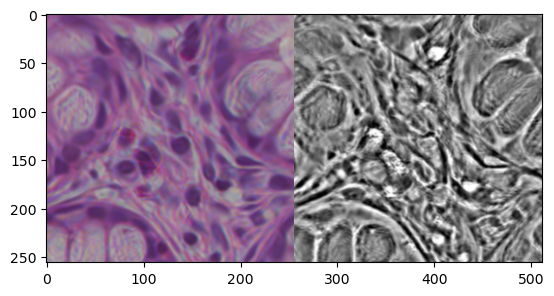

In [7]:
plt.figure()
plt.imshow(sample_image)

You need to separate real building facade images from the architecture label images -> all of which will be of size `256 x 256`.

Define a function that loads image files and outputs two image tensors:

In [8]:
def load(image_file):
  # Read and decode an image file to a uint8 tensor
  image = tf.io.read_file(image_file)
  image = tfio.experimental.image.decode_tiff(image)

  # Split each image tensor into two tensors:
  # - one with a real building facade image
  # - one with an architecture label image 
  w = tf.shape(image)[1]
  w = w // 2
  input_image = image[:, w:, :3]
  real_image = image[:, :w, :3]

  # Convert both images to float32 tensors
  input_image = tf.cast(input_image, tf.float32)
  real_image = tf.cast(real_image, tf.float32)

  return input_image, real_image

Plot a sample of the input (architecture label image) and real (building facade photo) images:

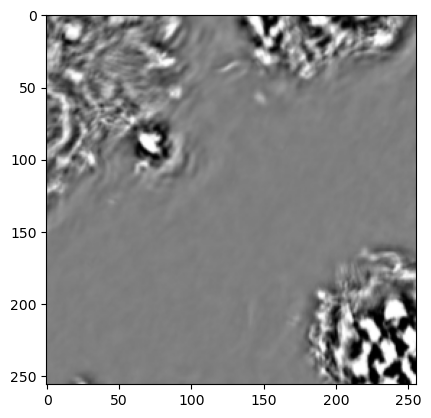

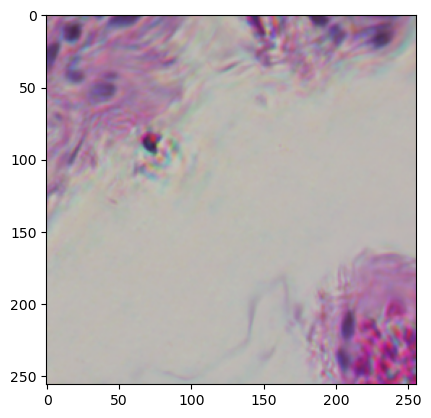

In [9]:
inp, re = load(str(PATH / 'train/10.tif'))

# Casting to int for matplotlib to display the images
plt.figure()
plt.imshow(inp / 255.0)
plt.figure()
plt.imshow(re / 255.0)

As described in the [pix2pix paper](https://arxiv.org/abs/1611.07004), you need to apply random jittering and mirroring to preprocess the training set.

Define several functions that:

1. Resize each `256 x 256` image to a larger height and width -> `286 x 286`.
2. Randomly crop it back to `256 x 256`.
3. Randomly flip the image horizontally i.e. left to right (random mirroring).
4. Normalize the images to the `[-1, 1]` range.

In [10]:
# The facade training set consist of 400 images
BUFFER_SIZE = len(list((PATH/'train').iterdir()))
# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 1
# Each image is 256x256 in size
IMG_WIDTH = 256
IMG_HEIGHT = 256

In [11]:
def resize(input_image, real_image, height, width):
  input_image = tf.image.resize(input_image, [height, width],
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  real_image = tf.image.resize(real_image, [height, width],
                               method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

  return input_image, real_image

In [12]:
def random_crop(input_image, real_image):
  stacked_image = tf.stack([input_image, real_image], axis=0)
  cropped_image = tf.image.random_crop(
      stacked_image, size=[2, IMG_HEIGHT, IMG_WIDTH, 3])

  return cropped_image[0], cropped_image[1]

In [13]:
# Normalizing the images to [-1, 1]
def normalize(input_image, real_image):
  input_image = (input_image / 127.5) - 1
  real_image = (real_image / 127.5) - 1

  return input_image, real_image

In [14]:
@tf.function()
def random_jitter(input_image, real_image):
  # Resizing to 286x286
  input_image, real_image = resize(input_image, real_image, 286, 286)

  # Random cropping back to 256x256
  input_image, real_image = random_crop(input_image, real_image)

  if tf.random.uniform(()) > 0.5:
    # Random mirroring
    input_image = tf.image.flip_left_right(input_image)
    real_image = tf.image.flip_left_right(real_image)

  return input_image, real_image

You can inspect some of the preprocessed output:

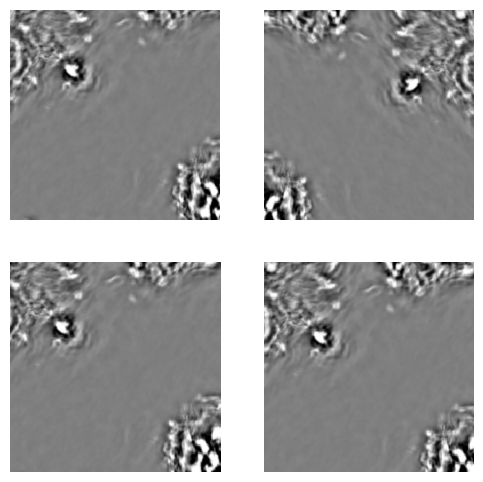

In [15]:
plt.figure(figsize=(6, 6))
for i in range(4):
  rj_inp, rj_re = random_jitter(inp, re)
  plt.subplot(2, 2, i + 1)
  plt.imshow(rj_inp / 255.0)
  plt.axis('off')
plt.show()

Having checked that the loading and preprocessing works, let's define a couple of helper functions that load and preprocess the training and test sets:

In [16]:
def load_image_train(image_file):
  input_image, real_image = load(image_file)
  input_image, real_image = random_jitter(input_image, real_image)
  input_image, real_image = normalize(input_image, real_image)
  input_image = input_image[:,:, :INPUT_CHANNELS]
  #real_image = real_image[:,:,OUTPUT_CHANNEL]
  return input_image, real_image

In [17]:
def load_image_test(image_file):
  input_image, real_image = load(image_file)
  input_image, real_image = resize(input_image, real_image,
                                   IMG_HEIGHT, IMG_WIDTH)
  input_image, real_image = normalize(input_image, real_image)
  input_image = input_image[:,:,:INPUT_CHANNELS]
  #real_image = real_image[:,:,OUTPUT_CHANNEL]
  return input_image, real_image

## Build an input pipeline with `tf.data`

In [18]:
train_dataset = tf.data.Dataset.list_files(str(PATH / 'train/*.tif'))
train_dataset = train_dataset.map(load_image_train,
                                  num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)

In [19]:
# try:
#   test_dataset = tf.data.Dataset.list_files(str(PATH / 'test/*.tif'))
# except tf.errors.InvalidArgumentError:
# shuffle=True, seed fixed -> file order (and so fixed_samples below) stays the same across
# kernel restarts, instead of a fresh random order every time (list_files defaults to an
# unseeded shuffle).
val_dataset = tf.data.Dataset.list_files(str(PATH / 'val/*.tif'), shuffle=True, seed=42)
val_dataset = val_dataset.map(load_image_test)
val_dataset = val_dataset.batch(BATCH_SIZE)

## Build the generator

The generator of your pix2pix cGAN is a _modified_ [U-Net](https://arxiv.org/abs/1505.04597). A U-Net consists of an encoder (downsampler) and decoder (upsampler). (You can find out more about it in the [Image segmentation](https://www.tensorflow.org/tutorials/images/segmentation) tutorial and on the [U-Net project website](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/).)

- Each block in the encoder is: Convolution -> Batch normalization -> Leaky ReLU
- Each block in the decoder is: Transposed convolution -> Batch normalization -> Dropout (applied to the first 3 blocks) -> ReLU
- There are skip connections between the encoder and decoder (as in the U-Net).

Define the downsampler (encoder):

In [20]:
def downsample(filters, size, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [21]:
down_model = downsample(3, 4)
down_result = down_model(tf.expand_dims(tf.expand_dims(inp[:,:,0], 0),-1))
print (down_result.shape)

(1, 128, 128, 3)


Define the upsampler (decoder):

In [22]:
def upsample(filters, size, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
    tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

  result.add(tf.keras.layers.BatchNormalization())

  if apply_dropout:
      result.add(tf.keras.layers.Dropout(0.5))

  result.add(tf.keras.layers.ReLU())

  return result

In [23]:
up_model = upsample(3, 4)
up_result = up_model(down_result)
print (up_result.shape)

(1, 256, 256, 3)


Define the generator with the downsampler and the upsampler:

In [24]:
def Generator():
  inputs = tf.keras.layers.Input(shape=[None, None, INPUT_CHANNELS])

  down_stack = [
    downsample(64, 4, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
    downsample(128, 4),  # (batch_size, 64, 64, 128)
    downsample(256, 4),  # (batch_size, 32, 32, 256)
    downsample(512, 4),  # (batch_size, 16, 16, 512)    
    downsample(512, 4),  # (batch_size, 8, 8, 512)
    downsample(512, 4),  # (batch_size, 4, 4, 512)
    downsample(512, 4),  # (batch_size, 2, 2, 512)
    downsample(512, 4),  # (batch_size, 1, 1, 512)
  ]

  up_stack = [
    upsample(512, 4, apply_dropout=True),  # (batch_size, 2, 2, 1024)
    upsample(512, 4, apply_dropout=True),  # (batch_size, 4, 4, 1024)
    upsample(512, 4, apply_dropout=True),  # (batch_size, 8, 8, 1024)
    upsample(512, 4),  # (batch_size, 16, 16, 1024)
    upsample(256, 4),  # (batch_size, 32, 32, 512)
    upsample(128, 4),  # (batch_size, 64, 64, 256)
    upsample(64, 4),  # (batch_size, 128, 128, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, 256, 256, 3)

  x = inputs

  # Downsampling through the model
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

Visualize the generator model architecture:

In [25]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


Test the generator:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


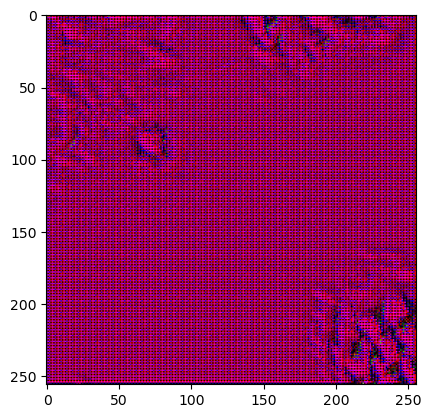

In [26]:
gen_output = generator(inp[:,:,:INPUT_CHANNELS][tf.newaxis, ...], training=False)
plt.imshow(gen_output[0, ...])

### Define the generator loss

GANs learn a loss that adapts to the data, while cGANs learn a structured loss that penalizes a possible structure that differs from the network output and the target image, as described in the [pix2pix paper](https://arxiv.org/abs/1611.07004).

- The generator loss is a sigmoid cross-entropy loss of the generated images and an **array of ones**.
- The pix2pix paper also mentions the L1 loss, which is a MAE (mean absolute error) between the generated image and the target image.
- This allows the generated image to become structurally similar to the target image.
- The formula to calculate the total generator loss is `gan_loss + LAMBDA * l1_loss`, where `LAMBDA = 100`. This value was decided by the authors of the paper.

In [27]:
LAMBDA = 100#0.0001
ALPHA = 2

In [28]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [29]:
# def generator_loss(disc_generated_output, gen_output, target):
#   gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
#
#   # Mean absolute error
#   l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
#
#   total_gen_loss = gan_loss + (LAMBDA * l1_loss)
#
#   return total_gen_loss, gan_loss, l1_loss

def generator_loss(disc_generated_output, gen_output, target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  # Mean absolute error
  l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

  tv_loss = tf.image.total_variation(gen_output)[0]

  ssim_loss = 1-tf.image.ssim(tf.reshape(gen_output,(IMG_HEIGHT,IMG_WIDTH,OUTPUT_CHANNELS)),
                                                          tf.reshape(target,(IMG_HEIGHT,IMG_WIDTH,OUTPUT_CHANNELS)),max_val=1)

  # total_gen_loss = l1_loss + ssim_loss + (LAMBDA * tv_loss) + (ALPHA * gan_loss)
  total_gen_loss = gan_loss + (LAMBDA * l1_loss)

  return total_gen_loss, gan_loss, l1_loss, tv_loss, ssim_loss

The training procedure for the generator is as follows:

![Generator Update Image](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gen.png?raw=1)


## Build the discriminator

The discriminator in the pix2pix cGAN is a convolutional PatchGAN classifier -> it tries to classify if each image _patch_ is real or not real, as described in the [pix2pix paper](https://arxiv.org/abs/1611.07004).

- Each block in the discriminator is: Convolution -> Batch normalization -> Leaky ReLU.
- The shape of the output after the last layer is `(batch_size, 30, 30, 1)`.
- Each `30 x 30` image patch of the output classifies a `70 x 70` portion of the input image.
- The discriminator receives 2 inputs: 
    - The input image and the target image, which it should classify as real.
    - The input image and the generated image (the output of the generator), which it should classify as fake.
    - Use `tf.concat([inp, tar], axis=-1)` to concatenate these 2 inputs together.

Let's define the discriminator:

In [30]:
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)

  inp = tf.keras.layers.Input(shape=[256, 256, INPUT_CHANNELS], name='input_image')
  tar = tf.keras.layers.Input(shape=[256, 256, OUTPUT_CHANNELS], name='target_image')

  x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

  down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
  down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
  down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
  conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

  last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

  return tf.keras.Model(inputs=[inp, tar], outputs=last)

Visualize the discriminator model architecture:

In [31]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


Test the discriminator:

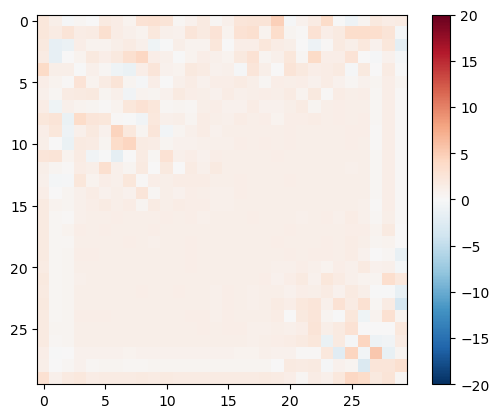

In [32]:
disc_out = discriminator([inp[:,:,:INPUT_CHANNELS][tf.newaxis, ...], gen_output], training=False)
plt.imshow(disc_out[0, ..., -1], vmin=-20, vmax=20, cmap='RdBu_r')
plt.colorbar()
plt.show()

### Define the discriminator loss

- The `discriminator_loss` function takes 2 inputs: **real images** and **generated images**.
- `real_loss` is a sigmoid cross-entropy loss of the **real images** and an **array of ones(since these are the real images)**.
- `generated_loss` is a sigmoid cross-entropy loss of the **generated images** and an **array of zeros (since these are the fake images)**.
- The `total_loss` is the sum of `real_loss` and `generated_loss`.

In [33]:
def discriminator_loss(disc_real_output, disc_generated_output):

  real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

  generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
  total_disc_loss = real_loss + generated_loss
  return total_disc_loss

In [34]:
def discriminator_accuracy(disc_real_output, disc_generated_output):
  real_accuracy = tf.reduce_sum(tf.cast(tf.greater_equal(disc_real_output,0),tf.float32))/tf.reduce_sum(tf.ones_like(disc_real_output))
  gen_accuracy = tf.reduce_sum(tf.cast(tf.less(disc_generated_output,0),tf.float32))/tf.reduce_sum(tf.ones_like(disc_generated_output))
  return 0.5 * (real_accuracy+gen_accuracy)

The training procedure for the discriminator is shown below.

To learn more about the architecture and the hyperparameters you can refer to the [pix2pix paper](https://arxiv.org/abs/1611.07004).

![Discriminator Update Image](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/dis.png?raw=1)


## Define the optimizers and a checkpoint-saver


In [35]:
initial_learning_rate = 0.0002
steps_per_epoch = BUFFER_SIZE
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=steps_per_epoch * 2,
    decay_rate=0.7,
    staircase=True)

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [36]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Generate images

Write a function to plot some images during training.

- Pass images from the test set to the generator.
- The generator will then translate the input image into the output.
- The last step is to plot the predictions and _voila_!

Note: The `training=True` is intentional here since
you want the batch statistics, while running the model on the test dataset. If you use `training=False`, you get the accumulated statistics learned from the training dataset (which you don't want).

In [37]:
def generate_images(model, examples):
  j=0
  concat_images = []

  for test_input, ground_truth in examples:
    prediction = model(test_input, training=True)
    # print(tf.image.total_variation(ground_truth),tf.image.total_variation(prediction))
    plt.figure(j,figsize=(15, 15))
    # tar = ycbcr_to_rgb(ground_truth[0])
    # prediction = ycbcr_to_rgb(prediction[0])

    tar = ground_truth[0]
    prediction = prediction[0]

    # tar = np.repeat(ground_truth[0][:,:,np.newaxis], 3, axis=2).reshape((IMG_HEIGHT,IMG_WIDTH,3))
    # prediction = np.repeat(prediction[0][:,:,np.newaxis], 3, axis=2).reshape((IMG_HEIGHT,IMG_WIDTH,3))
    test_input = test_input[0]

    if INPUT_CHANNELS == 2:
      images = [np.repeat(test_input[:, :, 0, np.newaxis], 3, axis=2),np.repeat(test_input[:, :, 1, np.newaxis], 3, axis=2),tar,prediction]
      title = ['Phase', 'Amplitude', 'Ground Truth', 'Predicted Image']
    elif INPUT_CHANNELS == 3:
      images = [np.repeat(test_input[:, :, 0, np.newaxis], 3, axis=2),
                  np.repeat(test_input[:, :, 1, np.newaxis], 3, axis=2),
                  np.repeat(test_input[:, :, 2, np.newaxis], 3, axis=2),
                  tar,prediction]
      title = ['Phase', 'Amplitude','On Axis', 'Ground Truth', 'Predicted Image']
    else:
      images = [np.repeat(test_input[:, :, 0, np.newaxis], 3, axis=2),tar,prediction]
      #print([img.shape for img in images])
      title = ['Phase', 'Ground Truth', 'Predicted Image']
    for i in range(INPUT_CHANNELS+2):
      plt.subplot(1, INPUT_CHANNELS+2, i+1)
      plt.title(title[i])
      # Getting the pixel values in the [0, 1] range to plot.
      plt.imshow(images[i] * 0.5 + 0.5)
      plt.axis('off')
    concat_image = np.concatenate(images,axis=1)
    concat_image = np.reshape(concat_image, (IMG_HEIGHT, (INPUT_CHANNELS+2)*IMG_WIDTH, 3))
    concat_image = concat_image * 0.5 + 0.5
    concat_image*=255.0
    concat_images.append(concat_image)
    j+=1

  concat_image = np.concatenate(concat_images,axis=0)
  # plt.figure(j+1)
  # plt.imshow(concat_image.astype(np.uint8))
  plt.show()
  return np.array([concat_image.astype(np.uint8)])

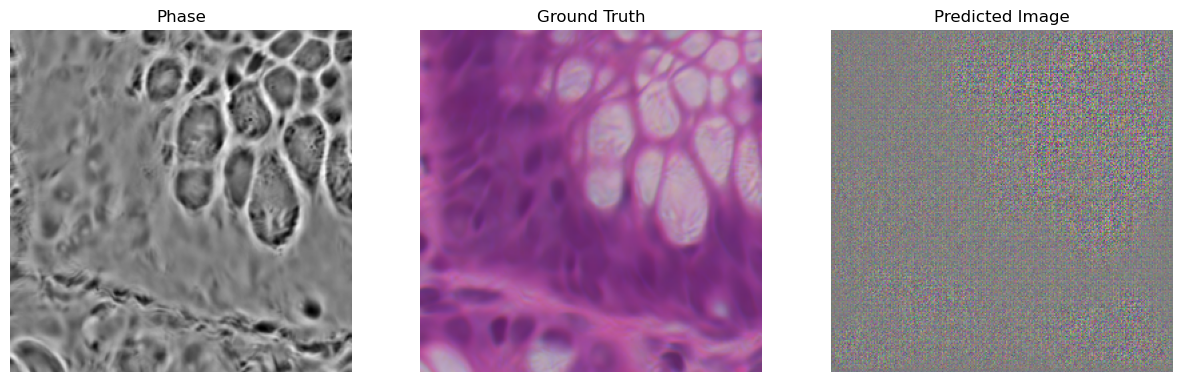

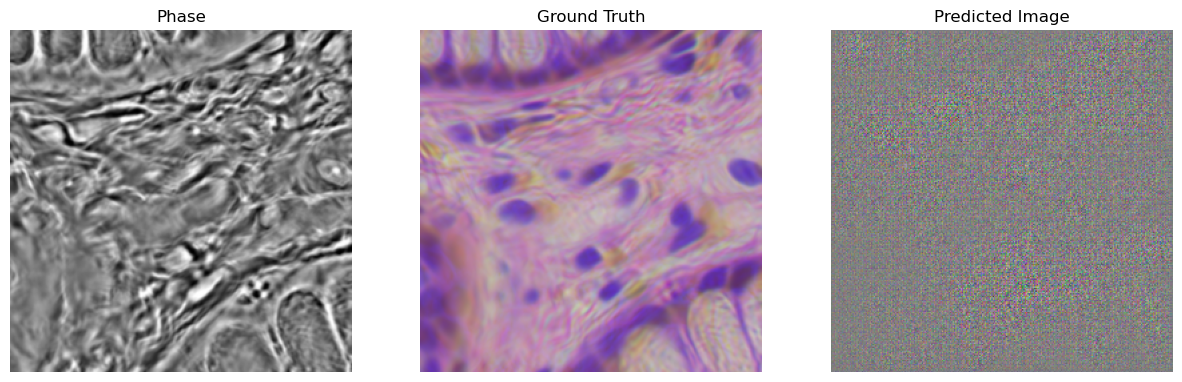

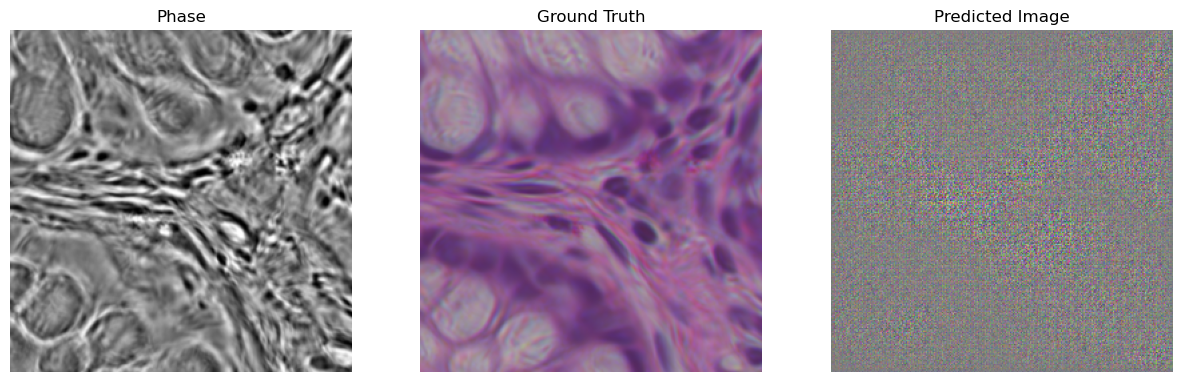

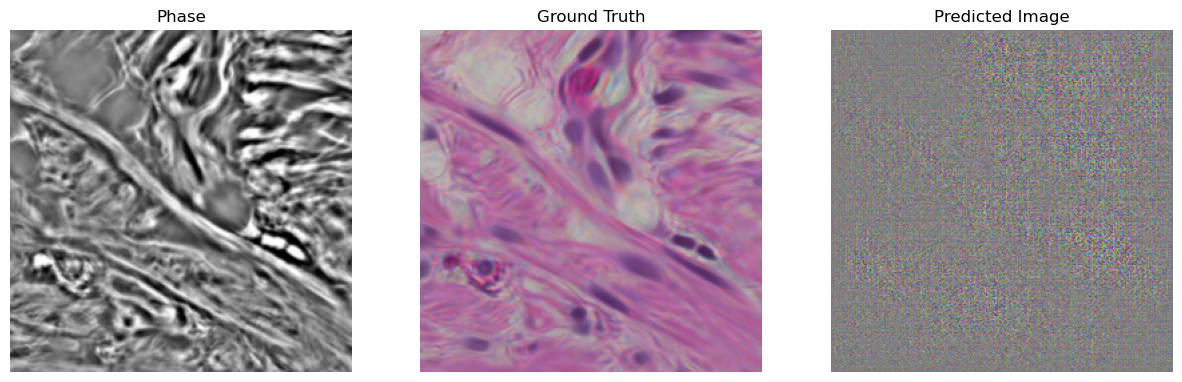

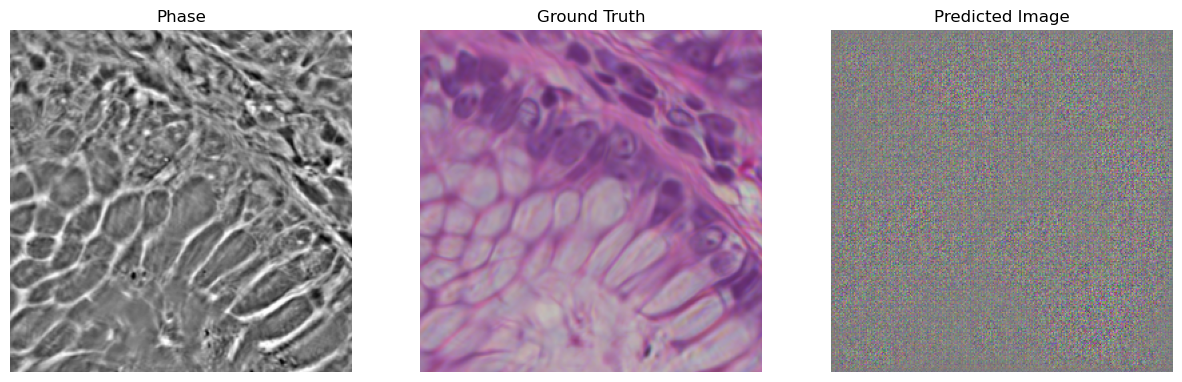

array([[[[146, 146, 146],
         [142, 142, 142],
         [145, 145, 145],
         ...,
         [119, 134, 121],
         [111, 133, 145],
         [127, 131, 123]],

        [[137, 137, 137],
         [143, 143, 143],
         [147, 147, 147],
         ...,
         [164, 159, 123],
         [120, 119, 104],
         [126, 140, 123]],

        [[136, 136, 136],
         [146, 146, 146],
         [148, 148, 148],
         ...,
         [118, 127, 126],
         [118, 128, 120],
         [112, 124, 119]],

        ...,

        [[ 94,  94,  94],
         [ 99,  99,  99],
         [105, 105, 105],
         ...,
         [124, 134, 103],
         [127, 120, 124],
         [129, 123, 129]],

        [[ 94,  94,  94],
         [100, 100, 100],
         [109, 109, 109],
         ...,
         [126, 121, 129],
         [111, 127, 114],
         [112, 126, 125]],

        [[ 97,  97,  97],
         [104, 104, 104],
         [119, 119, 119],
         ...,
         [126, 126, 135],
        

In [38]:
same_ds = [next(iter(val_dataset)) for x in range(5)]

generate_images(generator,same_ds)

In [39]:
@tf.function
def ssim(model,examples):
  subset = examples.take(100)
  ssims = tf.TensorArray(tf.float32, size=100)

  for i,(test_input, ground_truth) in enumerate(subset):
    prediction = model(test_input, training=True)
    ground_truth=ground_truth*0.5+0.5
    prediction=prediction*0.5+0.5
    ssims = ssims.write(tf.cast(i,tf.int32),tf.image.ssim(tf.reshape(prediction,(IMG_HEIGHT,IMG_WIDTH,OUTPUT_CHANNELS)),
                                                          tf.reshape(ground_truth,(IMG_HEIGHT,IMG_WIDTH,OUTPUT_CHANNELS)),max_val=1))
  ret = tf.reduce_mean(ssims.stack())
  return ret

In [40]:
ssim(generator,val_dataset)

<tf.Tensor: shape=(), dtype=float32, numpy=0.097054556>

## Training

- For each example input generates an output.
- The discriminator receives the `input_image` and the generated image as the first input. The second input is the `input_image` and the `target_image`.
- Next, calculate the generator and the discriminator loss.
- Then, calculate the gradients of loss with respect to both the generator and the discriminator variables(inputs) and apply those to the optimizer.
- Finally, log the losses to TensorBoard.

In [41]:
log_dir="logs/"

summary_writer = tf.summary.create_file_writer(
  log_dir + "fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [42]:
@tf.function
def train_step(input_image, target, step, val_image=None, same_image=None):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    gen_output = generator(input_image, training=True)

    disc_real_output = discriminator([input_image, target], training=True)
    disc_generated_output = discriminator([input_image, gen_output], training=True)

    gen_total_loss, gen_gan_loss, gen_l1_loss, gen_tv_loss, ssim_loss = generator_loss(disc_generated_output, gen_output, target)
    #gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)
    disc_accuracy = discriminator_accuracy(disc_real_output, disc_generated_output)

  generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
  discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))

  with summary_writer.as_default():
    tf.summary.scalar('gen_total_loss', gen_total_loss, step=step)
    tf.summary.scalar('gen_gan_loss', gen_gan_loss, step=step)
    tf.summary.scalar('gen_l1_loss', gen_l1_loss, step=step)
    tf.summary.scalar('gen_tv_loss', gen_tv_loss, step=step)
    tf.summary.scalar('disc_loss', disc_loss, step=step)
    tf.summary.scalar('disc_accuracy', disc_accuracy, step=step)
    tf.summary.scalar('ssim', 1-ssim_loss, step=step)
    if val_image is not None:
      tf.summary.image('generated_image',val_image, step=step)
    if same_image is not None:
      tf.summary.image('same_images',same_image, step=step)
    if step % 5000 == 0:
      tf.summary.scalar('ssim_val', ssim(generator,val_dataset),step=step)

The actual training loop. Since this tutorial can run of more than one dataset, and the datasets vary greatly in size the training loop is setup to work in steps instead of epochs.

- Iterates over the number of steps.
- Every 10 steps print a dot (`.`).
- Every 1k steps: clear the display and run `generate_images` to show the progress.
- Every 5k steps: save a checkpoint.

In [43]:
def fit(train_ds, test_ds, steps):

  same_ds = [next(iter(test_ds)) for x in range(5)]

  start = time.time()

  for step, (input_image, target) in train_ds.repeat().take(steps).enumerate():
    if (step) % 1000 == 0:
      display.clear_output(wait=True)

      if step != 0:
        print(f'Time taken for 1000 steps: {time.time()-start:.2f} sec\n')

      start = time.time()
      val_image = generate_images(generator, test_ds.take(1))
      same_image = generate_images(generator, same_ds)
      print(f"Step: {step}")

      train_step(input_image, target, step, val_image, same_image)
    else:
      train_step(input_image, target, step)

    # Training step
    if (step+1) % 10 == 0:
      print('.', end='', flush=True)


    # Save (checkpoint) the model every 5k steps
    if (step + 1) % 5000 == 0:
      checkpoint.save(file_prefix=checkpoint_prefix)

This training loop saves logs that you can view in TensorBoard to monitor the training progress.

If you work on a local machine, you would launch a separate TensorBoard process. When working in a notebook, launch the viewer before starting the training to monitor with TensorBoard.

To launch the viewer paste the following into a code-cell:

In [44]:
%load_ext tensorboard
%tensorboard --logdir {log_dir} --samples_per_plugin images=799

Reusing TensorBoard on port 6006 (pid 11324), started 0:19:53 ago. (Use '!kill 11324' to kill it.)

Finally, run the training loop:

In [45]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
#fit(train_dataset, val_dataset, steps=BUFFER_SIZE*100)

If you want to share the TensorBoard results _publicly_, you can upload the logs to [TensorBoard.dev](https://tensorboard.dev/) by copying the following into a code-cell.

Note: This requires a Google account.

```
!tensorboard dev upload --logdir {log_dir}
```

Caution: This command does not terminate. It's designed to continuously upload the results of long-running experiments. Once your data is uploaded you need to stop it using the "interrupt execution" option in your notebook tool.

You can view the [results of a previous run](https://tensorboard.dev/experiment/lZ0C6FONROaUMfjYkVyJqw) of this notebook on [TensorBoard.dev](https://tensorboard.dev/).

TensorBoard.dev is a managed experience for hosting, tracking, and sharing ML experiments with everyone.

It can also included inline using an `<iframe>`:

In [46]:
display.IFrame(
    src="https://tensorboard.dev/experiment/lZ0C6FONROaUMfjYkVyJqw",
    width="100%",
    height="1000px")

Interpreting the logs is more subtle when training a GAN (or a cGAN like pix2pix) compared to a simple classification or regression model. Things to look for:

- Check that neither the generator nor the discriminator model has "won". If either the `gen_gan_loss` or the `disc_loss` gets very low, it's an indicator that this model is dominating the other, and you are not successfully training the combined model.
- The value `log(2) = 0.69` is a good reference point for these losses, as it indicates a perplexity of 2 - the discriminator is, on average, equally uncertain about the two options.
- For the `disc_loss`, a value below `0.69` means the discriminator is doing better than random on the combined set of real and generated images.
- For the `gen_gan_loss`, a value below `0.69` means the generator is doing better than random at fooling the discriminator.
- As training progresses, the `gen_l1_loss` should go down.

## Restore the latest checkpoint and test the network

In [47]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint('./training_checkpoints'))

## Generate some images using the test set

In [48]:
# Inference using a given list of file names and output folder.
# Images should be .tif, HxWx3, where H=W and H is one of 256,512 or 1024 with the phase image replicated in all 3 channels
# Output folder is created relative to input filename - e.g. with fns = ["C:\Data\image1.tif", "C:\Data\image2.tif"] out = "processed"
# Output folder will be "C:\Data\processed" and output images will be saved as "C:\Data\processed\image1.tif", "C:\Data\processed\image2.tif"
def generate_images_full_fov(fns,out):

  from queue import Queue

  loaded_images = Queue()
  in_q = Queue()
  out_q = Queue()

  def _load_sample(fn):
    print('load',fn)
    in_q.put(fn)
    image = tf.io.read_file(fn)
    image = tfio.experimental.image.decode_tiff(image)[:,:,:3]
    # w = tf.shape(image)[1]
    # w = w // 2
    # input_image = image[:, w:, :3]
    
    image = tf.cast(image[np.newaxis,:,:,:1], tf.float32)
    image = (image / 127.5) - 1
    loaded_images.put((fn,image))

  def _process_samples():

    while True:
      q_item = loaded_images.get(block=True)
      if q_item is None:
        break
      else:
        fn,input_image = q_item
      out_q.put(fn)
      print('process',fn)
      folder,fn = os.path.split(fn)
      out_folder = os.path.join(folder,out)
      if not os.path.isdir(out_folder):
        os.makedirs(out_folder)

      prediction = generator(input_image, training=True)

      prediction = prediction[0].numpy()

      out_fn = os.path.join(out_folder,fn)
      prediction = ((prediction * 0.5 + 0.5)*255).astype(np.uint8)

      with tifffile.TiffWriter(out_fn) as tiff:
        tiff.write(prediction)
    print('done')

  from concurrent.futures import ThreadPoolExecutor
  from functools import partial

  with ThreadPoolExecutor(2) as tpe:
    tpe.submit(_process_samples)
    for fn in fns:
      tpe.submit(partial(_load_sample,fn))
    while in_q.qsize()<len(fns):
      print('in_q',in_q.qsize(),'fns',len(fns))
      time.sleep(1)
    while out_q.qsize()<in_q.qsize():
      print('out_q',out_q.qsize(),'in_q',in_q.qsize())
      time.sleep(1)
    loaded_images.put(None)

In [49]:
# from glob import glob
# from timeit import default_timer as timer

# input_folder = r'E:\Dissertation\pix2pix_minimal\datasets\polyps_v7\val'
# out = "output"

# image_fns = glob(rf'{input_folder}\*.tif')
# done_fns = glob(rf'{input_folder}\{out}\*.tif')

# done_fns = [os.path.split(fn)[1] for fn in done_fns]
# image_fns = [fn for fn in image_fns if os.path.split(fn)[1] not in done_fns]

# out_folder = rf'{input_folder}\{out}'
# print(out_folder)
# print(f'Found {len(image_fns)} images to process.')

# if len(image_fns):
#     t1 = timer()
#     generate_images_full_fov(image_fns, out)
#     t2 = timer()
#     print(f'Time taken: {t2-t1:.2f} sec\n')
# else:
#     print('No new images to process.')

In [50]:
# Fixed samples  ->  run this once, then reuse across all analyses
N_SAMPLES = 3
fixed_samples = [next(iter(val_dataset)) for _ in range(N_SAMPLES)]

In [51]:
# # Perturbation functions  ->  all operate on normalised [-1, 1] images
# def perturb_gaussian(image, std=0.1):
#     noise = tf.random.normal(shape=tf.shape(image), stddev=std)
#     return tf.clip_by_value(image + noise, -1, 1)

# def perturb_blur(image, kernel_size=5):
#     image = tf.expand_dims(image, 0)
#     blurred = tf.nn.avg_pool2d(image, ksize=kernel_size, strides=1, padding='SAME')
#     return tf.squeeze(blurred, 0)

# def perturb_salt_pepper(image, amount=0.05):
#     mask = tf.random.uniform(tf.shape(image))
#     image = tf.where(mask < amount / 2, -1.0, image)
#     image = tf.where(mask > 1 - (amount / 2), 1.0, image)
#     return image

# def perturb_brightness(image, delta=0.3):
#     return tf.clip_by_value(image + delta, -1, 1)

# def perturb_crop(image, crop_size=128, center=True):
#     """
#     Crop a small region from the image and resize back to original size.
#     crop_size: size of the square crop (e.g. 128 = half the image)
#     center: if True, crop from center; if False, crop randomly
#     """
#     h = tf.shape(image)[0]
#     w = tf.shape(image)[1]
#     if center:
#         y0 = (h - crop_size) // 2
#         x0 = (w - crop_size) // 2
#     else:
#         y0 = tf.random.uniform((), 0, h - crop_size, dtype=tf.int32)
#         x0 = tf.random.uniform((), 0, w - crop_size, dtype=tf.int32)
#     cropped = image[y0:y0 + crop_size, x0:x0 + crop_size, :]
#     # Resize back to full input size so the generator sees a 256x256 image
#     resized = tf.image.resize(cropped, [IMG_HEIGHT, IMG_WIDTH],
#                               method=tf.image.ResizeMethod.BILINEAR)
#     return resized

# PERTURBATIONS = {
#     'Gaussian\nNoise': lambda x: perturb_gaussian(x, std=0.2),
#     'Blur':            lambda x: perturb_blur(x, kernel_size=7),
#     'Salt &\nPepper':  lambda x: perturb_salt_pepper(x, amount=0.05),
#     'Brightness':      lambda x: perturb_brightness(x, delta=0.3),
#     'Center\nCrop':    lambda x: perturb_crop(x, crop_size=128, center=True),
#     'Random\nCrop':    lambda x: perturb_crop(x, crop_size=128, center=False),
# }

In [52]:
# def generate_images_perturbed(model, examples, perturbations=PERTURBATIONS):
#     n_perturb = len(perturbations)
#     n_cols = 1 + n_perturb
#     n_rows = 3

#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp = test_input[0]
#         gt  = ground_truth[0]
#         clean_pred = model(test_input, training=True)[0]

#         phase = np.repeat(inp[:, :, 0:1].numpy(), 3, axis=2)

#         fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

#         # Column 0
#         axes[0, 0].imshow(phase * 0.5 + 0.5, cmap='gray')
#         axes[0, 0].set_title('Phase', fontsize=14)
#         axes[1, 0].imshow(clean_pred.numpy() * 0.5 + 0.5)
#         axes[1, 0].set_title('Clean Pred', fontsize=14)
#         axes[2, 0].imshow(gt.numpy() * 0.5 + 0.5)
#         axes[2, 0].set_title('Ground Truth', fontsize=14)

#         for col, (name, perturb_fn) in enumerate(perturbations.items(), start=1):
#             inp_perturbed = perturb_fn(inp)
#             noisy_pred    = model(inp_perturbed[tf.newaxis], training=True)[0]

#             noisy_phase = np.repeat(inp_perturbed[:, :, 0:1].numpy(), 3, axis=2)

#             score = tf.image.ssim(
#                 tf.reshape(clean_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 tf.reshape(noisy_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 max_val=1
#             ).numpy()

#             axes[0, col].imshow(noisy_phase * 0.5 + 0.5, cmap='gray')
#             axes[0, col].set_title(f'{name} Input', fontsize=14)
#             axes[1, col].imshow(noisy_pred.numpy() * 0.5 + 0.5)
#             axes[1, col].set_title(f'{name} Pred', fontsize=14)
#             axes[2, col].axis('off')
#             axes[2, col].text(0.5, 0.5, f'SSIM{score:.3f}',
#                               ha='center', va='center', fontsize=16,
#                               transform=axes[2, col].transAxes)

#         for ax in axes.flat:
#             ax.axis('off')

#         plt.suptitle(f'Sample {idx+1}', fontsize=16, y=1.01)
#         plt.tight_layout()
#         plt.show()

# # Run on 3 validation samples
# # Use fixed samples for consistency across all analyses
# examples = fixed_samples
# generate_images_perturbed(generator, examples)

In [53]:
# def ssim_perturbed(model, examples, perturbations=PERTURBATIONS, n=100):
#     # Robustness metric: compares perturbed prediction against the clean prediction, not ground truth
#     subset = examples.take(n)
#     scores = {name: [] for name in perturbations}

#     for test_input, ground_truth in subset:
#         inp = test_input[0]
#         clean_pred = model(test_input, training=True)[0] * 0.5 + 0.5

#         for name, perturb_fn in perturbations.items():
#             inp_perturbed = perturb_fn(inp)
#             noisy_pred = model(inp_perturbed[tf.newaxis], training=True)[0] * 0.5 + 0.5

#             score = tf.image.ssim(
#                 tf.reshape(clean_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)),
#                 tf.reshape(noisy_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)),
#                 max_val=1
#             ).numpy()
#             scores[name].append(score)

#     return {name: float(np.mean(vals)) for name, vals in scores.items()}

# ssim_perturbed(generator, val_dataset)

In [54]:
# import matplotlib.patches as patches

# def generate_images_crop(model, examples, crop_size=128, center=True, n_crop_sizes=None):
#     """
#     Detailed crop perturbation visualisation.
#     Row 0: original phase | crop region highlighted | zoomed-in crop (what model sees)
#     Row 1: clean prediction | crop-based prediction | ground truth
#     Row 2: SSIM score between clean and crop prediction

#     If n_crop_sizes is a list of ints (e.g. [64, 128, 192]), runs one column per crop size.
#     """
#     crop_sizes = n_crop_sizes if n_crop_sizes is not None else [crop_size]
#     n_cols = 1 + len(crop_sizes)   # 1 clean column + one per crop size

#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp = test_input[0]
#         gt  = ground_truth[0]
#         clean_pred = model(test_input, training=True)[0]

#         phase_np   = inp[:, :, 0:1].numpy()
#         phase_disp = np.repeat(phase_np, 3, axis=2) * 0.5 + 0.5

#         fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 14))
#         if n_cols == 1:
#             axes = axes[:, np.newaxis]

#         #  ->  Column 0: clean baseline  -> 
#         axes[0, 0].imshow(phase_disp, cmap='gray')
#         axes[0, 0].set_title('Original Input', fontsize=13)

#         axes[1, 0].imshow(clean_pred.numpy() * 0.5 + 0.5)
#         axes[1, 0].set_title('Clean Prediction', fontsize=13)

#         axes[2, 0].imshow(gt.numpy() * 0.5 + 0.5)
#         axes[2, 0].set_title('Ground Truth', fontsize=13)

#         #  ->  Columns 1 -> N: one per crop size  -> 
#         h, w = IMG_HEIGHT, IMG_WIDTH

#         for col, cs in enumerate(crop_sizes, start=1):
#             if center:
#                 y0 = (h - cs) // 2
#                 x0 = (w - cs) // 2
#             else:
#                 y0 = np.random.randint(0, h - cs)
#                 x0 = np.random.randint(0, w - cs)

#             # Crop  ->  resize  ->  predict
#             inp_perturbed = perturb_crop(inp, crop_size=cs, center=center)
#             crop_pred = model(inp_perturbed[tf.newaxis], training=True)[0]

#             zoomed_disp = np.repeat(
#                 inp_perturbed[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#             ssim_score = tf.image.ssim(
#                 tf.reshape(clean_pred, (h, w, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 tf.reshape(crop_pred,  (h, w, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 max_val=1
#             ).numpy()

#             # Row 0: original with crop box + zoomed view
#             ax_orig = axes[0, col]
#             ax_orig.imshow(phase_disp, cmap='gray')
#             rect = patches.Rectangle(
#                 (x0, y0), cs, cs,
#                 linewidth=2, edgecolor='red', facecolor='none'
#             )
#             ax_orig.add_patch(rect)
#             ax_orig.set_title(f'Crop region\n(size={cs})', fontsize=13)

#             # Row 1: zoomed crop (what model sees) vs crop prediction
#             # Split into two sub-images by reusing axes[1] for prediction
#             # and put an inset for the "zoomed input" using axes[0] overlay
#             axes[1, col].imshow(zoomed_disp, cmap='gray')
#             axes[1, col].set_title(f'Zoomed Input\n(crop {cs} -> {h})', fontsize=13)

#             # Row 2: prediction from crop
#             axes[2, col].imshow(crop_pred.numpy() * 0.5 + 0.5)
#             axes[2, col].set_title(f'Crop Pred  SSIM={ssim_score:.3f}', fontsize=13)

#         for ax in axes.flat:
#             ax.axis('off')

#         plt.suptitle(f'Crop Perturbation  ->  Sample {idx+1}', fontsize=16, y=1.01)
#         plt.tight_layout()
#         plt.show()


# # Run on fixed val samples  ->  try multiple crop sizes side by side
# generate_images_crop(
#     generator,
#     fixed_samples,
#     center=True,
#     n_crop_sizes=[64, 128, 192],
# )

In [55]:
# def mc_dropout_uncertainty(model, test_input, n_runs=20):
#     """
#     Run generator N times with dropout active, compute mean and variance.
#     Returns: mean prediction, uncertainty map (variance across runs)
#     """
#     preds = []
#     for _ in range(n_runs):
#         pred = model(test_input, training=True)  # dropout stays ON
#         preds.append(pred[0].numpy())

#     preds = np.stack(preds, axis=0)          # (N, H, W, 3)
#     mean_pred = preds.mean(axis=0)           # (H, W, 3)
#     variance   = preds.var(axis=0)           # (H, W, 3)
#     uncertainty = variance.mean(axis=-1)     # (H, W)  ->  avg across RGB channels

#     return mean_pred, uncertainty


# def visualise_uncertainty(model, examples, n_runs=20):
#     for idx, (test_input, ground_truth) in enumerate(examples):
#         mean_pred, uncertainty = mc_dropout_uncertainty(model, test_input, n_runs)

#         gt = ground_truth[0].numpy()
#         inp = test_input[0].numpy()
#         phase = np.repeat(inp[:, :, 0:1], 3, axis=2)

#         fig, axes = plt.subplots(1, 4, figsize=(20, 5))

#         axes[0].imshow(phase * 0.5 + 0.5, cmap='gray')
#         axes[0].set_title('Phase Input', fontsize=14)

#         axes[1].imshow(gt * 0.5 + 0.5)
#         axes[1].set_title('Ground Truth', fontsize=14)

#         axes[2].imshow(mean_pred * 0.5 + 0.5)
#         axes[2].set_title(f'Mean Pred (N={n_runs})', fontsize=14)

#         im = axes[3].imshow(uncertainty, cmap='hot')
#         axes[3].set_title('Uncertainty Map(high = less confident)', fontsize=14)
#         plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

#         for ax in axes:
#             ax.axis('off')

#         plt.suptitle(f'MC Dropout Uncertainty  ->  Sample {idx+1}', fontsize=16)
#         plt.tight_layout()
#         plt.show()

#         print(f'Sample {idx+1}  ->  Mean uncertainty: {uncertainty.mean():.5f} | Max: {uncertainty.max():.5f}')


# # Run on 3 val samples
# # Use fixed samples for consistency across all analyses
# examples = fixed_samples
# visualise_uncertainty(generator, examples, n_runs=20)

In [56]:
# # XAI: Saliency Map + Grad x Input + SmoothGrad

# def saliency_map(model, input_image):
#     """Vanilla gradient  ->  which input pixels drive the output most."""
#     input_tensor = tf.cast(input_image, tf.float32)
#     with tf.GradientTape() as tape:
#         tape.watch(input_tensor)
#         pred = model(input_tensor, training=True)
#         loss = tf.reduce_mean(pred)
#     grads = tape.gradient(loss, input_tensor)
#     sal = tf.abs(grads[0, :, :, 0]).numpy()
#     sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
#     return sal, pred[0].numpy()


# def grad_times_input(model, input_image):
#     """Gradient x Input  ->  highlights important regions weighted by intensity."""
#     input_tensor = tf.cast(input_image, tf.float32)
#     with tf.GradientTape() as tape:
#         tape.watch(input_tensor)
#         pred = model(input_tensor, training=True)
#         loss = tf.reduce_mean(pred)
#     grads = tape.gradient(loss, input_tensor)
#     gxi = tf.abs(grads * input_tensor)[0, :, :, 0].numpy()
#     gxi = (gxi - gxi.min()) / (gxi.max() - gxi.min() + 1e-8)
#     return gxi, pred[0].numpy()


# def smoothgrad(model, input_image, n_samples=20, noise_std=0.1):
#     """SmoothGrad  ->  average saliency over N noisy copies. Reduces visual noise."""
#     input_tensor = tf.cast(input_image, tf.float32)
#     grads_sum = tf.zeros_like(input_tensor)
#     for _ in range(n_samples):
#         noise = tf.random.normal(tf.shape(input_tensor), stddev=noise_std)
#         noisy = input_tensor + noise
#         with tf.GradientTape() as tape:
#             tape.watch(noisy)
#             pred = model(noisy, training=True)
#             loss = tf.reduce_mean(pred)
#         grads_sum = grads_sum + tf.abs(tape.gradient(loss, noisy))
#     avg_grads = (grads_sum / n_samples)[0, :, :, 0].numpy()
#     avg_grads = (avg_grads - avg_grads.min()) / (avg_grads.max() - avg_grads.min() + 1e-8)
#     return avg_grads, pred[0].numpy()


# def overlay_heatmap(image_2d, heatmap, alpha=0.5):
#     import matplotlib.cm as cm
#     heatmap_colour = cm.jet(heatmap)[:, :, :3]
#     image_rgb = np.repeat(image_2d[:, :, np.newaxis], 3, axis=2)
#     return (1 - alpha) * image_rgb + alpha * heatmap_colour


# def visualise_xai(model, examples):
#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp  = test_input[0].numpy()
#         gt   = ground_truth[0].numpy()
#         phase_norm = inp[:, :, 0] * 0.5 + 0.5

#         sal,  pred  = saliency_map(model, test_input)
#         gxi,  _     = grad_times_input(model, test_input)
#         sg,   _     = smoothgrad(model, test_input, n_samples=20)

#         fig, axes = plt.subplots(1, 6, figsize=(30, 5))

#         axes[0].imshow(phase_norm, cmap='gray')
#         axes[0].set_title('Phase Input', fontsize=14)

#         axes[1].imshow(gt * 0.5 + 0.5)
#         axes[1].set_title('Ground Truth', fontsize=14)

#         axes[2].imshow(pred * 0.5 + 0.5)
#         axes[2].set_title('Prediction', fontsize=14)

#         axes[3].imshow(overlay_heatmap(phase_norm, sal))
#         axes[3].set_title('Saliency Map', fontsize=14)

#         axes[4].imshow(overlay_heatmap(phase_norm, gxi))
#         axes[4].set_title('Grad x Input', fontsize=14)

#         axes[5].imshow(overlay_heatmap(phase_norm, sg))
#         axes[5].set_title('SmoothGrad', fontsize=14)

#         for ax in axes:
#             ax.axis('off')

#         plt.suptitle(f'XAI Analysis  ->  Sample {idx+1}', fontsize=16)
#         plt.tight_layout()
#         plt.show()


# # Use fixed samples for consistency across all analyses
# examples = fixed_samples
# visualise_xai(generator, examples)

In [57]:
# def compare_salt_pepper_levels(model, examples, amounts=(0.05, 0.10, 0.20, 0.50)):
#     n_cols = 1 + len(amounts)

#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp        = test_input[0]
#         gt         = ground_truth[0]
#         clean_pred = model(test_input, training=True)[0]

#         phase_disp = np.repeat(inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#         fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 14))

#         # Column 0  ->  clean baseline
#         axes[0, 0].imshow(phase_disp, cmap='gray')
#         axes[0, 0].set_title('Original Input', fontsize=13)
#         axes[1, 0].imshow(clean_pred.numpy() * 0.5 + 0.5)
#         axes[1, 0].set_title('Clean Pred', fontsize=13)
#         axes[2, 0].imshow(gt.numpy() * 0.5 + 0.5)
#         axes[2, 0].set_title('Ground Truth', fontsize=13)

#         for col, amt in enumerate(amounts, start=1):
#             noisy_inp  = perturb_salt_pepper(inp, amount=amt)
#             noisy_pred = model(noisy_inp[tf.newaxis], training=True)[0]

#             noisy_disp = np.repeat(noisy_inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#             ssim_vs_clean = tf.image.ssim(
#                 tf.reshape(clean_pred,  (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 tf.reshape(noisy_pred,  (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 max_val=1
#             ).numpy()

#             ssim_vs_gt = tf.image.ssim(
#                 tf.reshape(gt,         (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 tf.reshape(noisy_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 max_val=1
#             ).numpy()

#             axes[0, col].imshow(noisy_disp, cmap='gray')
#             axes[0, col].set_title(f'S&P {int(amt*100)}% Input', fontsize=13)

#             axes[1, col].imshow(noisy_pred.numpy() * 0.5 + 0.5)
#             axes[1, col].set_title(f'S&P {int(amt*100)}% Pred', fontsize=13)

#             axes[2, col].axis('off')
#             axes[2, col].text(0.5, 0.65, f'vs clean:\n{ssim_vs_clean:.3f}',
#                               ha='center', va='center', fontsize=14,
#                               transform=axes[2, col].transAxes)
#             axes[2, col].text(0.5, 0.30, f'vs GT:\n{ssim_vs_gt:.3f}',
#                               ha='center', va='center', fontsize=14, color='gray',
#                               transform=axes[2, col].transAxes)

#         for ax in axes.flat:
#             ax.axis('off')

#         plt.suptitle(f'Salt & Pepper Robustness  ->  Sample {idx+1}', fontsize=16, y=1.01)
#         plt.tight_layout()
#         plt.show()


# compare_salt_pepper_levels(generator, fixed_samples, amounts=(0.05, 0.10, 0.20, 0.50))

In [58]:
# from timeit import default_timer as timer

# BLUR_KERNEL_SIZE = 7
# out_root = pathlib.Path('./blur_output')

# def generate_blur_dataset(model, kernel_size=BLUR_KERNEL_SIZE, split='all'):
#     """
#     Apply blur to every phase input in the dataset, run through the generator,
#     and save the RGB prediction to ./blur_output/{split}/.
#     """
#     splits = ['train', 'val'] if split == 'all' else [split]
#     total  = 0

#     for sp in splits:
#         image_fns  = sorted((PATH / sp).glob('*.tif'))
#         out_folder = out_root / sp
#         out_folder.mkdir(parents=True, exist_ok=True)

#         print(f'[{sp}]  {len(image_fns)} images   ->   {out_folder}')
#         t0 = timer()

#         for fn in image_fns:
#             raw   = tf.io.read_file(str(fn))
#             image = tfio.experimental.image.decode_tiff(raw)
#             w     = tf.shape(image)[1] // 2

#             inp    = tf.cast(image[:, w:, :3], tf.float32)
#             inp, _ = resize(inp, inp, IMG_HEIGHT, IMG_WIDTH)
#             inp    = (inp / 127.5) - 1.0
#             inp    = inp[:, :, :INPUT_CHANNELS]

#             blurred    = perturb_blur(inp, kernel_size=kernel_size)
#             pred       = model(blurred[tf.newaxis], training=True)[0]
#             pred_uint8 = ((pred.numpy() * 0.5 + 0.5) * 255).astype(np.uint8)

#             with tifffile.TiffWriter(str(out_folder / fn.name)) as tif:
#                 tif.write(pred_uint8)

#             total += 1

#         elapsed = timer() - t0
#         n = len(image_fns)
#         print(f'       done  {elapsed:.1f}s  ({elapsed/n:.2f}s/img)\n')

#     print(f'Saved {total} images to {out_root.resolve()}')


# generate_blur_dataset(generator, kernel_size=BLUR_KERNEL_SIZE, split='all')

In [59]:
# import csv
# from timeit import default_timer as timer
# import pathlib

# out_root = pathlib.Path('./blur_output')

# def calc_blur_metrics(split='all'):
#     """Compute SSIM + PSNR for all saved blur predictions."""
#     splits = ['train', 'val'] if split == 'all' else [split]
#     all_rows = []

#     for sp in splits:
#         image_fns = sorted((out_root / sp).glob('*.tif'))
#         print(f'[{sp}]  {len(image_fns)} images')
#         t0 = timer()
#         ssim_list, psnr_list = [], []

#         for idx, pred_fn in enumerate(image_fns):
#             raw   = tf.io.read_file(str(PATH / sp / pred_fn.name))
#             image = tfio.experimental.image.decode_tiff(raw)
#             w     = tf.shape(image)[1] // 2
#             gt    = tf.cast(image[:, :w, :3], tf.float32)
#             gt, _ = resize(gt, gt, IMG_HEIGHT, IMG_WIDTH)
#             gt    = (gt / 127.5) - 1.0

#             pred_raw = tf.io.read_file(str(pred_fn))
#             pred_img = tfio.experimental.image.decode_tiff(pred_raw)[:, :, :OUTPUT_CHANNELS]
#             pred     = tf.cast(pred_img, tf.float32)
#             pred, _  = resize(pred, pred, IMG_HEIGHT, IMG_WIDTH)
#             pred     = (pred / 127.5) - 1.0

#             pred_01 = tf.reshape(pred * 0.5 + 0.5, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS))
#             gt_01   = tf.reshape(gt   * 0.5 + 0.5, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS))

#             ssim_val = float(tf.image.ssim(pred_01, gt_01, max_val=1))
#             psnr_val = float(tf.image.psnr(pred_01, gt_01, max_val=1))

#             ssim_list.append(ssim_val)
#             psnr_list.append(psnr_val)
#             all_rows.append({'split': sp, 'file': pred_fn.name,
#                              'ssim': round(ssim_val, 6),
#                              'psnr': round(psnr_val, 4)})

#             if (idx + 1) % 2000 == 0:
#                 print(f'  {idx+1}/{len(image_fns)}...')

#         elapsed = timer() - t0
#         print(f'  SSIM  mean={np.mean(ssim_list):.4f}  std={np.std(ssim_list):.4f}'
#               f'  min={np.min(ssim_list):.4f}  max={np.max(ssim_list):.4f}')
#         print(f'  PSNR  mean={np.mean(psnr_list):.2f} dB  std={np.std(psnr_list):.2f}')
#         print(f'  Time  {elapsed:.1f}s\n')

#     csv_path = out_root / 'metrics_blur.csv'
#     with open(csv_path, 'w', newline='') as f:
#         writer = csv.DictWriter(f, fieldnames=['split', 'file', 'ssim', 'psnr'])
#         writer.writeheader()
#         writer.writerows(all_rows)
#     print(f'Metrics saved -> {csv_path}')
#     return all_rows


# metrics = calc_blur_metrics(split='all')

In [60]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = pd.read_csv("./blur_output/metrics_blur.csv")
# df["img_idx"] = df["file"].str.replace(".tif", "", regex=False).astype(int)
# df = df.sort_values("img_idx").reset_index(drop=True)

# fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# for ax, sp in zip(axes, ["train", "val"]):
#     sub = df[df["split"] == sp].reset_index(drop=True)
#     roll = sub["ssim"].rolling(window=200, center=True, min_periods=1).mean()

#     ax.scatter(sub["img_idx"], sub["ssim"], s=2, alpha=0.25, color="steelblue", label="SSIM per image")
#     ax.plot(sub["img_idx"], roll, color="red", linewidth=1.5, label="Rolling mean (200)")
#     mean_val = sub["ssim"].mean()
#     ax.axhline(mean_val, color="orange", linestyle="--", linewidth=1.2, label=f"Mean = {mean_val:.4f}")

#     title = f"SSIM - {sp.capitalize()} split  (n={len(sub)})"
#     ax.set_title(title, fontsize=13)
#     ax.set_xlabel("Image Index", fontsize=11)
#     ax.set_ylabel("SSIM", fontsize=11)
#     ax.set_ylim(0, 1)
#     ax.legend(fontsize=9)
#     ax.grid(True, alpha=0.3)

# plt.suptitle("SSIM per Image (Blur Output vs Ground Truth)", fontsize=15)
# plt.tight_layout()
# plt.savefig("./blur_output/ssim_per_image.png", dpi=150, bbox_inches="tight")
# plt.show()

# train_ssim = df[df["split"]=="train"]["ssim"]
# val_ssim   = df[df["split"]=="val"]["ssim"]
# print(f"Train SSIM: mean={train_ssim.mean():.4f}  std={train_ssim.std():.4f}")
# print(f"Val   SSIM: mean={val_ssim.mean():.4f}  std={val_ssim.std():.4f}")

In [61]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = pd.read_csv("./blur_output/metrics_blur.csv")
# train = df[df["split"]=="train"]["ssim"].values
# val   = df[df["split"]=="val"]["ssim"].values

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # Histogram 
# ax = axes[0]
# ax.hist(train, bins=60, alpha=0.6, color="steelblue", label=f"Train (n={len(train)})", density=True)
# ax.hist(val,   bins=60, alpha=0.6, color="tomato",    label=f"Val   (n={len(val)})",   density=True)
# ax.axvline(train.mean(), color="steelblue", linestyle="--", linewidth=1.5, label=f"Train mean={train.mean():.3f}")
# ax.axvline(val.mean(),   color="tomato",    linestyle="--", linewidth=1.5, label=f"Val   mean={val.mean():.3f}")
# ax.set_xlabel("SSIM", fontsize=12)
# ax.set_ylabel("Density", fontsize=12)
# ax.set_title("SSIM Distribution", fontsize=13)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# # Box plot
# ax = axes[1]
# bp = ax.boxplot([train, val], labels=["Train", "Val"], patch_artist=True,
#                 medianprops=dict(color="black", linewidth=2))
# bp["boxes"][0].set_facecolor("steelblue")
# bp["boxes"][0].set_alpha(0.6)
# bp["boxes"][1].set_facecolor("tomato")
# bp["boxes"][1].set_alpha(0.6)
# ax.set_ylabel("SSIM", fontsize=12)
# ax.set_title("SSIM Box Plot (Train vs Val)", fontsize=13)
# ax.grid(True, alpha=0.3, axis="y")

# # CDF 
# ax = axes[2]
# for data, color, label in [(train, "steelblue", "Train"), (val, "tomato", "Val")]:
#     sorted_data = np.sort(data)
#     cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
#     ax.plot(sorted_data, cdf, color=color, linewidth=2, label=label)
# ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.2, label="SSIM=0.5")
# ax.axvline(0.7, color="gray", linestyle="--", linewidth=1.2, label="SSIM=0.7")
# ax.set_xlabel("SSIM", fontsize=12)
# ax.set_ylabel("Cumulative Proportion", fontsize=12)
# ax.set_title("CDF of SSIM", fontsize=13)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# plt.suptitle("SSIM Analysis - Blur Robustness", fontsize=15)
# plt.tight_layout()
# plt.savefig("./blur_output/ssim_analysis.png", dpi=150, bbox_inches="tight")
# plt.show()

It checks how much the model's output changes when the input image is blurred, using SSIM (which measures structural similarity between two images, higher number means more similar).

1. Histogram: Most SSIM scores cluster around 0.51–0.61, for both train and validation data. The distribution is fairly symmetric, and the two sets sit almost exactly on top of each other (mean 0.565 vs 0.563).

2. Box plot: The median is around 0.56, with outliers on both sides, some samples scoring as high as 0.89 (very similar), and some as low as 0.2 (very different). Unlike LPIPS, the spread goes both ways, not just one direction.

3. CDF: This shows what percentage of samples fall below a given SSIM value. At SSIM = 0.5, only about 20% of samples are below it, meaning roughly 80% of outputs still score "above 0.5", which on its own would suggest the model is holding up reasonably well.

Train and validation give nearly identical results. This is good, it means the metric is reliable across the data split.

The problem is that this 80%-looks-fine picture from SSIM directly contradicts what LPIPS showed: 80% of the same samples were already perceptually distorted. This is exactly why SSIM is misleading here, it measures local pixel/structural similarity, not whether the actual tissue structures (glands, lumen) are still intact. A blurred image can keep a "decent" SSIM score even while losing the structural features that matter for diagnosis.

This confirms, with numbers, why SSIM alone is not a trustworthy robustness metric for VS-FPM, and why LPIPS (or another perceptual metric) is needed alongside it to catch failures that SSIM hides.

In [62]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer

# # Setup (matches earlier cells)
# dataset_name = 'polyps_v7'
# PATH = pathlib.Path(r'./datasets') / dataset_name
# OUTPUT_CHANNELS = 3
# IMG_HEIGHT = 256
# IMG_WIDTH  = 256

# def resize(input_image, real_image, height, width):
#     input_image = tf.image.resize(input_image, [height, width],
#                                   method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
#     real_image  = tf.image.resize(real_image,  [height, width],
#                                   method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
#     return input_image, real_image

# out_root = pathlib.Path('./blur_output')
# loss_fn  = lpips.LPIPS(net='alex', verbose=False)

# def calc_lpips(split='all'):
#     splits = ['train', 'val'] if split == 'all' else [split]
#     all_rows = []
#     for sp in splits:
#         image_fns = sorted((out_root / sp).glob('*.tif'))
#         print(f'[{sp}]  {len(image_fns)} images')
#         t0 = timer()
#         vals = []
#         for idx, pred_fn in enumerate(image_fns):
#             raw   = tf.io.read_file(str(PATH / sp / pred_fn.name))
#             image = tfio.experimental.image.decode_tiff(raw)
#             w     = tf.shape(image)[1] // 2
#             gt    = tf.cast(image[:, :w, :3], tf.float32)
#             gt, _ = resize(gt, gt, IMG_HEIGHT, IMG_WIDTH)
#             gt    = (gt / 127.5) - 1.0
#             pred_raw = tf.io.read_file(str(pred_fn))
#             pred_img = tfio.experimental.image.decode_tiff(pred_raw)[:, :, :OUTPUT_CHANNELS]
#             pred     = tf.cast(pred_img, tf.float32)
#             pred, _  = resize(pred, pred, IMG_HEIGHT, IMG_WIDTH)
#             pred     = (pred / 127.5) - 1.0
#             pred_t = torch.from_numpy(pred.numpy()).permute(2, 0, 1).unsqueeze(0)
#             gt_t   = torch.from_numpy(gt.numpy()).permute(2, 0, 1).unsqueeze(0)
#             with torch.no_grad():
#                 v = float(loss_fn(pred_t, gt_t))
#             vals.append(v)
#             all_rows.append({'split': sp, 'file': pred_fn.name, 'lpips': round(v, 6)})
#             if (idx + 1) % 2000 == 0:
#                 print(f'  {idx+1}/{len(image_fns)}  ({timer()-t0:.0f}s)...')
#         elapsed = timer() - t0
#         print(f'  LPIPS  mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  '
#               f'min={np.min(vals):.4f}  max={np.max(vals):.4f}')
#         print(f'  Time   {elapsed:.1f}s\n')
#     csv_path = out_root / 'metrics_lpips.csv'
#     with open(csv_path, 'w', newline='') as f:
#         writer = csv.DictWriter(f, fieldnames=['split', 'file', 'lpips'])
#         writer.writeheader()
#         writer.writerows(all_rows)
#     print(f'LPIPS saved -> {csv_path}')
#     return all_rows

# lpips_results = calc_lpips(split='all')

In [63]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df    = pd.read_csv('./blur_output/metrics_lpips.csv')
# train = df[df['split'] == 'train']['lpips'].values
# val   = df[df['split'] == 'val']['lpips'].values

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# # Histogram
# ax = axes[0]
# ax.hist(train, bins=50, alpha=0.6, color='steelblue', density=True, label=f'Train (n={len(train)})')
# ax.hist(val,   bins=50, alpha=0.6, color='orange',    density=True, label=f'Val   (n={len(val)})')
# ax.set_xlabel('LPIPS')
# ax.set_ylabel('Density')
# ax.set_title('LPIPS Distribution')
# ax.legend()

# # Box plot
# ax = axes[1]
# bp = ax.boxplot([train, val], labels=['Train', 'Val'], patch_artist=True)
# bp['boxes'][0].set_facecolor('steelblue')
# bp['boxes'][1].set_facecolor('orange')
# ax.set_ylabel('LPIPS')
# ax.set_title('LPIPS Box Plot')

# # CDF
# ax = axes[2]
# for data, label, color in [(train, 'Train', 'steelblue'), (val, 'Val', 'orange')]:
#     s = np.sort(data)
#     cdf = np.arange(1, len(s) + 1) / len(s)
#     ax.plot(s, cdf, label=label, color=color)
# ax.axvline(0.3, color='gray', linestyle='--', alpha=0.7, label='LPIPS=0.3')
# ax.set_xlabel('LPIPS')
# ax.set_ylabel('Cumulative Proportion')
# ax.set_title('LPIPS CDF')
# ax.legend()

# t_m, t_s = np.mean(train), np.std(train)
# v_m, v_s = np.mean(val),   np.std(val)
# fig.suptitle(f'LPIPS Analysis - Blur Robustness\n'
#              f'Train: {t_m:.4f} +/- {t_s:.4f}    Val: {v_m:.4f} +/- {v_s:.4f}',
#              fontsize=13)
# plt.tight_layout()
# plt.savefig('./blur_output/lpips_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()
# print(f'Train  mean={t_m:.4f}  std={t_s:.4f}  min={train.min():.4f}  max={train.max():.4f}')
# print(f'Val    mean={v_m:.4f}  std={v_s:.4f}  min={val.min():.4f}  max={val.max():.4f}')

It checks how much the model's output changes when the input image is blurred, using LPIPS (which measures how different two images look to a human eye, higher number means more different).

1. Histogram : Most LPIPS scores cluster around 0.33–0.35, for both train and validation data. The two distributions sit almost exactly on top of each other.
2. Box plot : The median is around 0.33, with a long tail of outliers going up to 0.7+ (very few outliers below). So most predictions degrade by a similar moderate amount, but a few degrade a lot more.
3. CDF : This shows what percentage of samples fall below a given LPIPS value. At LPIPS = 0.3 (a common threshold for "noticeably different to a human"), only about 15–20% of samples are below it. That means roughly 80% of outputs are already perceptually distorted once blur is applied.


Train and validation give nearly identical results (0.3459 vs 0.3467). This is good, it means the failure pattern is consistent and not just a fluke of one data split.

The fact that 80% of samples cross the "noticeably different" threshold even under blur supports your earlier finding: the model doesn't degrade gracefully, it breaks down quickly.

The long right tail suggests a subset of images fail much worse than the rest, worth checking if those correspond to specific tissue regions or blur severity levels.

This confirms, with numbers, that VS-FPM is not robust to blur, and most outputs become perceptually unreliable even at modest distortion levels.

In [64]:
# def perturb_texture(image, depth=0.05, scale='medium'):
#     """
#     Add structured texture noise at different spatial scales and depths.
#     scale: 'fine'    ->  high-frequency (pixel-level) texture
#            'medium'  ->  intermediate-frequency texture
#            'coarse'  ->  low-frequency (blob-like) texture
#     depth: amplitude of the added texture (0 = none, 1 = maximum)
#     """
#     shape = tf.shape(image)
#     h, w, c = shape[0], shape[1], shape[2]

#     if scale == 'fine':
#         noise = tf.random.normal(shape, stddev=depth)
#     elif scale == 'medium':
#         noise = tf.random.normal([h // 8, w // 8, c], stddev=depth)
#         noise = tf.image.resize(noise, [h, w], method='bilinear')
#     else:  # coarse
#         noise = tf.random.normal([h // 32, w // 32, c], stddev=depth)
#         noise = tf.image.resize(noise, [h, w], method='bilinear')

#     return tf.clip_by_value(image + noise, -1.0, 1.0)


# def compare_texture_depths(model, examples, depths=(0.05, 0.10, 0.20, 0.40),
#                            scales=('fine', 'medium', 'coarse')):
#     """
#     For each sample, show a grid: rows = texture scales, columns = texture depths.
#     Each cell shows: [noisy input | model prediction | SSIM vs clean].
#     """
#     n_depths = len(depths)
#     n_scales = len(scales)
#     # Columns: clean baseline + one per depth level
#     n_cols = 1 + n_depths
#     # Rows: 2 display rows (input, prediction) per scale, plus a SSIM row
#     n_rows = n_scales * 3

#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp        = test_input[0]
#         gt         = ground_truth[0]
#         clean_pred = model(test_input, training=True)[0]

#         phase_disp = np.repeat(inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#         fig, axes = plt.subplots(n_rows, n_cols,
#                                  figsize=(4.5 * n_cols, 4 * n_rows))

#         for s_idx, scale in enumerate(scales):
#             row_inp  = s_idx * 3
#             row_pred = s_idx * 3 + 1
#             row_ssim = s_idx * 3 + 2

#             # Column 0  ->  clean baseline (only fill top scale row for neatness)
#             axes[row_inp,  0].imshow(phase_disp, cmap='gray')
#             axes[row_inp,  0].set_title(f'[{scale.upper()}]\nOriginal Input', fontsize=11)
#             axes[row_pred, 0].imshow(clean_pred.numpy() * 0.5 + 0.5)
#             axes[row_pred, 0].set_title('Clean Pred', fontsize=11)
#             axes[row_ssim, 0].imshow(gt.numpy() * 0.5 + 0.5)
#             axes[row_ssim, 0].set_title('Ground Truth', fontsize=11)

#             for col, d in enumerate(depths, start=1):
#                 tex_inp  = perturb_texture(inp, depth=d, scale=scale)
#                 tex_pred = model(tex_inp[tf.newaxis], training=True)[0]

#                 tex_disp = np.repeat(tex_inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#                 ssim_vs_clean = tf.image.ssim(
#                     tf.reshape(clean_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                     tf.reshape(tex_pred,   (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                     max_val=1
#                 ).numpy()

#                 ssim_vs_gt = tf.image.ssim(
#                     tf.reshape(gt,       (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                     tf.reshape(tex_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                     max_val=1
#                 ).numpy()

#                 axes[row_inp,  col].imshow(tex_disp, cmap='gray')
#                 axes[row_inp,  col].set_title(f'{scale.capitalize()} depth={d:.2f}\nNoisy Input', fontsize=11)

#                 axes[row_pred, col].imshow(tex_pred.numpy() * 0.5 + 0.5)
#                 axes[row_pred, col].set_title(f'Texture Pred', fontsize=11)

#                 axes[row_ssim, col].axis('off')
#                 axes[row_ssim, col].text(0.5, 0.65,
#                                          f'vs clean:\n{ssim_vs_clean:.3f}',
#                                          ha='center', va='center', fontsize=13,
#                                          transform=axes[row_ssim, col].transAxes)
#                 axes[row_ssim, col].text(0.5, 0.30,
#                                          f'vs GT:\n{ssim_vs_gt:.3f}',
#                                          ha='center', va='center', fontsize=13,
#                                          color='gray',
#                                          transform=axes[row_ssim, col].transAxes)

#         for ax in axes.flat:
#             ax.axis('off')

#         plt.suptitle(f'Texture Depth Robustness  ->  Sample {idx+1}', fontsize=16, y=1.01)
#         plt.tight_layout()
#         plt.show()


# compare_texture_depths(generator, fixed_samples,
#                        depths=(0.05, 0.10, 0.20, 0.40),
#                        scales=('fine', 'medium', 'coarse'))

In [65]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import tifffile
# import numpy as np
# import pathlib
# from timeit import default_timer as timer

# def perturb_texture_medium(image, depth=0.05):
#     h, w, c = image.shape[0], image.shape[1], image.shape[2]
#     noise = tf.image.resize(
#         tf.random.normal([h // 8, w // 8, c], stddev=depth),
#         [h, w], method=tf.image.ResizeMethod.BILINEAR)
#     return tf.clip_by_value(image + noise, -1.0, 1.0)

# tex_out_root = pathlib.Path('./texture_output')

# def generate_texture_predictions(split='all'):
#     splits = ['train', 'val'] if split == 'all' else [split]
#     for sp in splits:
#         out_folder = tex_out_root / sp
#         out_folder.mkdir(parents=True, exist_ok=True)
#         image_fns = sorted((PATH / sp).glob('*.tif'))
#         print(f'[{sp}]  {len(image_fns)} images -> {out_folder}')
#         t0 = timer()
#         for idx, fn in enumerate(image_fns):
#             raw   = tf.io.read_file(str(fn))
#             image = tfio.experimental.image.decode_tiff(raw)
#             w     = tf.shape(image)[1] // 2
#             inp   = tf.cast(image[:, w:, :INPUT_CHANNELS], tf.float32)
#             inp   = (inp / 127.5) - 1.0
#             tex_inp    = perturb_texture_medium(inp, depth=0.05)
#             pred       = generator(tex_inp[tf.newaxis], training=True)[0]
#             pred_uint8 = ((pred.numpy() * 0.5 + 0.5) * 255).astype(np.uint8)
#             with tifffile.TiffWriter(str(out_folder / fn.name)) as tif:
#                 tif.write(pred_uint8)
#             if (idx + 1) % 2000 == 0:
#                 print(f'  {idx+1}/{len(image_fns)}  ({timer()-t0:.0f}s)...')
#         elapsed = timer() - t0
#         print(f'  Done  {len(image_fns)} images  {elapsed:.1f}s\n')

# generate_texture_predictions(split='all')

In [66]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer

# dataset_name    = 'polyps_v7'
# PATH            = pathlib.Path(r'./datasets') / dataset_name
# OUTPUT_CHANNELS = 3

# tex_out_root = pathlib.Path('./texture_output')
# loss_fn = lpips.LPIPS(net='alex', verbose=False)

# def calc_texture_metrics(split='all'):
#     splits = ['train', 'val'] if split == 'all' else [split]
#     all_rows = []
#     for sp in splits:
#         image_fns = sorted((tex_out_root / sp).glob('*.tif'))
#         print(f'[{sp}]  {len(image_fns)} images')
#         t0 = timer()
#         ssim_list, psnr_list, lpips_list = [], [], []
#         for idx, pred_fn in enumerate(image_fns):
#             raw   = tf.io.read_file(str(PATH / sp / pred_fn.name))
#             image = tfio.experimental.image.decode_tiff(raw)
#             w     = tf.shape(image)[1] // 2
#             gt    = tf.cast(image[:, :w, :3], tf.float32)
#             gt    = (gt / 127.5) - 1.0
#             pred_raw = tf.io.read_file(str(pred_fn))
#             pred_img = tfio.experimental.image.decode_tiff(pred_raw)[:, :, :OUTPUT_CHANNELS]
#             pred     = tf.cast(pred_img, tf.float32)
#             pred     = (pred / 127.5) - 1.0
#             pred_01  = pred * 0.5 + 0.5
#             gt_01    = gt   * 0.5 + 0.5
#             ssim_val = float(tf.image.ssim(pred_01, gt_01, max_val=1))
#             psnr_val = float(tf.image.psnr(pred_01, gt_01, max_val=1))
#             pred_t = torch.from_numpy(pred.numpy()).permute(2, 0, 1).unsqueeze(0)
#             gt_t   = torch.from_numpy(gt.numpy()).permute(2, 0, 1).unsqueeze(0)
#             with torch.no_grad():
#                 lpips_val = float(loss_fn(pred_t, gt_t))
#             ssim_list.append(ssim_val)
#             psnr_list.append(psnr_val)
#             lpips_list.append(lpips_val)
#             all_rows.append({'split': sp, 'file': pred_fn.name,
#                              'ssim':  round(ssim_val,  6),
#                              'psnr':  round(psnr_val,  4),
#                              'lpips': round(lpips_val, 6)})
#             if (idx + 1) % 2000 == 0:
#                 print(f'  {idx+1}/{len(image_fns)}  ({timer()-t0:.0f}s)...')
#         elapsed = timer() - t0
#         print(f'  SSIM   mean={np.mean(ssim_list):.4f}  std={np.std(ssim_list):.4f}')
#         print(f'  PSNR   mean={np.mean(psnr_list):.2f} dB  std={np.std(psnr_list):.2f}')
#         print(f'  LPIPS  mean={np.mean(lpips_list):.4f}  std={np.std(lpips_list):.4f}')
#         print(f'  Time   {elapsed:.1f}s\n')
#     csv_path = tex_out_root / 'metrics_texture.csv'
#     with open(csv_path, 'w', newline='') as f:
#         writer = csv.DictWriter(f, fieldnames=['split', 'file', 'ssim', 'psnr', 'lpips'])
#         writer.writeheader()
#         writer.writerows(all_rows)
#     print(f'Metrics saved -> {csv_path}')
#     return all_rows

# texture_metrics = calc_texture_metrics(split='all')

In [67]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df    = pd.read_csv('./texture_output/metrics_texture.csv')
# train = df[df['split'] == 'train']
# val   = df[df['split'] == 'val']

# metrics = [
#     ('ssim',  'SSIM',      'higher is better'),
#     ('psnr',  'PSNR (dB)', 'higher is better'),
#     ('lpips', 'LPIPS',     'lower is better'),
# ]

# fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# for row, (col, label, note) in enumerate(metrics):
#     t = train[col].values
#     v = val[col].values

#     ax = axes[row, 0]
#     ax.hist(t, bins=50, alpha=0.6, color='steelblue', density=True, label=f'Train (n={len(t)})')
#     ax.hist(v, bins=50, alpha=0.6, color='orange',    density=True, label=f'Val   (n={len(v)})')
#     ax.set_xlabel(label); ax.set_ylabel('Density')
#     ax.set_title(f'{label} Distribution ({note})'); ax.legend()

#     ax = axes[row, 1]
#     bp = ax.boxplot([t, v], labels=['Train', 'Val'], patch_artist=True)
#     bp['boxes'][0].set_facecolor('steelblue')
#     bp['boxes'][1].set_facecolor('orange')
#     ax.set_ylabel(label); ax.set_title(f'{label} Box Plot')

#     ax = axes[row, 2]
#     for data, lbl, color in [(t, 'Train', 'steelblue'), (v, 'Val', 'orange')]:
#         s = np.sort(data)
#         cdf = np.arange(1, len(s)+1) / len(s)
#         ax.plot(s, cdf, label=lbl, color=color)
#     ax.set_xlabel(label); ax.set_ylabel('CDF')
#     ax.set_title(f'{label} CDF'); ax.legend()

#     print(f'{label}  Train: mean={np.mean(t):.4f}  std={np.std(t):.4f} | '
#           f'Val: mean={np.mean(v):.4f}  std={np.std(v):.4f}')

# fig.suptitle('Texture Perturbation (medium, depth=0.05) - SSIM / PSNR / LPIPS', fontsize=14)
# plt.tight_layout()
# plt.savefig('./texture_output/metrics_texture_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()

It checks how much the model's output changes under texture perturbation (medium severity, depth=0.05), using three metrics: SSIM (structural similarity, higher is better), PSNR (signal fidelity in dB, higher is better), and LPIPS (perceptual difference, lower is better).

**1. SSIM**
- Histogram: Most scores cluster around 0.53–0.64, train and validation distributions sit almost exactly on top of each other.
- Box plot: Median around 0.57–0.58, with outliers mostly on both ends but more concentrated on the low side.
- CDF: At SSIM = 0.5, only about 15–20% of samples are below it, meaning roughly 80% of outputs score above 0.5.

**2. PSNR (dB)**
- Histogram: Most scores cluster around 19–24 dB, peak density around 21–22 dB, train and validation nearly identical.
- Box plot: Median around 21–22 dB, with a long left tail of low-PSNR outliers going down to ~12 dB.
- CDF: Around 22 dB, roughly 60% of samples fall below it, so PSNR is fairly evenly spread around the median.

**3. LPIPS**
- Histogram: Most scores cluster tightly around 0.25–0.30, noticeably lower (better) than the blur test's 0.33–0.35.
- Box plot: Median around 0.27–0.28, with a long right tail of outliers going up to 0.6.
- CDF: At LPIPS = 0.3, around 85–90% of samples are below it, meaning only about 10–15% of outputs cross the "noticeably different" threshold.

c

## Blur Sweep: SSIM / PSNR / LPIPS vs Kernel Size

In [68]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer
# from PIL import Image

# dataset_name    = 'polyps_v7'
# INPUT_CHANNELS  = 1
# OUTPUT_CHANNELS = 3
# PATH            = pathlib.Path(r'./datasets') / dataset_name

# generator  = Generator()
# _ckpt      = tf.train.Checkpoint(generator=generator)
# _ckpt.restore(tf.train.latest_checkpoint('./training_checkpoints')).expect_partial()
# print('Checkpoint restored')
# BLUR_KERNEL_SIZES = [1, 3, 5, 7, 11, 15, 21]  # 1 = no blur (baseline)
# SPLIT    = 'val'
# out_root = pathlib.Path('./blur_sweep_output')
# out_root.mkdir(parents=True, exist_ok=True)

# loss_fn   = lpips.LPIPS(net='alex', verbose=False)
# image_fns = sorted((PATH / SPLIT).glob('*.tif'))
# print(f'{len(image_fns)} val images found')

# summary_rows = []

# for ks in BLUR_KERNEL_SIZES:
#     kernel_dir = out_root / f'kernel_{ks}'
#     kernel_dir.mkdir(parents=True, exist_ok=True)
#     print()
#     print(f'kernel_size={ks} ({len(image_fns)} images) ...')
#     t0 = timer()

#     per_image_rows = []
#     ssim_list, psnr_list, lpips_list = [], [], []

#     for fn in image_fns:
#         raw   = tf.io.read_file(str(fn))
#         image = tfio.experimental.image.decode_tiff(raw)
#         half  = tf.shape(image)[1] // 2

#         # phase input (right half, INPUT_CHANNELS), normalise then blur
#         inp      = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32)
#         inp      = (inp / 127.5) - 1.0
#         inp_blur = perturb_blur(inp, kernel_size=ks)

#         # clean prediction: generator's own output on the unperturbed input.
#         # this is the reference so that kernel_size=1 (no-op blur) gives SSIM=1 exactly.
#         clean_pred = generator(inp[tf.newaxis], training=True)[0]

#         # forward pass on the (possibly) blurred input
#         pred = generator(inp_blur[tf.newaxis], training=True)[0]

#         # save predicted image
#         pred_np = ((pred.numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)
#         Image.fromarray(pred_np).save(kernel_dir / (fn.stem + '.tif'))

#         # [0, 1] for SSIM / PSNR - compared against the clean prediction, not ground truth
#         pred_01  = pred * 0.5 + 0.5
#         clean_01 = clean_pred * 0.5 + 0.5

#         ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))
#         psnr_val = float(tf.image.psnr(pred_01, clean_01, max_val=1))

#         # LPIPS expects [-1, 1], shape [1, C, H, W]
#         # DLPack: TF -> PyTorch without NumPy bridge
#         pred_t  = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(pred[tf.newaxis], [0,3,1,2]), tf.float32)))
#         clean_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(clean_pred[tf.newaxis], [0,3,1,2]), tf.float32)))
#         with torch.no_grad():
#             lpips_val = float(loss_fn(pred_t, clean_t))

#         ssim_list.append(ssim_val)
#         psnr_list.append(psnr_val)
#         lpips_list.append(lpips_val)
#         per_image_rows.append({
#             'file':  fn.name,
#             'ssim':  round(ssim_val,  6),
#             'psnr':  round(psnr_val,  4),
#             'lpips': round(lpips_val, 6),
#         })

#     # save per-image CSV in kernel_{ks}/
#     per_csv = kernel_dir / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader()
#         wr.writerows(per_image_rows)

#     elapsed = timer() - t0
#     row = {
#         'kernel_size': ks,
#         'ssim_mean':   round(np.mean(ssim_list),  5),
#         'ssim_std':    round(np.std(ssim_list),   5),
#         'psnr_mean':   round(np.mean(psnr_list),  4),
#         'psnr_std':    round(np.std(psnr_list),   4),
#         'lpips_mean':  round(np.mean(lpips_list), 5),
#         'lpips_std':   round(np.std(lpips_list),  5),
#         'n_images':    len(image_fns),
#     }
#     summary_rows.append(row)
#     print(f"  SSIM   {row['ssim_mean']:.4f}  +/- {row['ssim_std']:.4f}")
#     print(f"  PSNR   {row['psnr_mean']:.2f} dB  +/- {row['psnr_std']:.2f}")
#     print(f"  LPIPS  {row['lpips_mean']:.4f}  +/- {row['lpips_std']:.4f}")
#     print(f"  Time   {elapsed:.1f}s  ->  {per_csv}")

# # one-row-per-kernel summary CSV
# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['kernel_size', 'ssim_mean', 'ssim_std',
#                'psnr_mean',  'psnr_std',  'lpips_mean', 'lpips_std', 'n_images']
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader()
#     wr.writerows(summary_rows)
# print()
# print(f'Summary saved -> {summary_csv}')


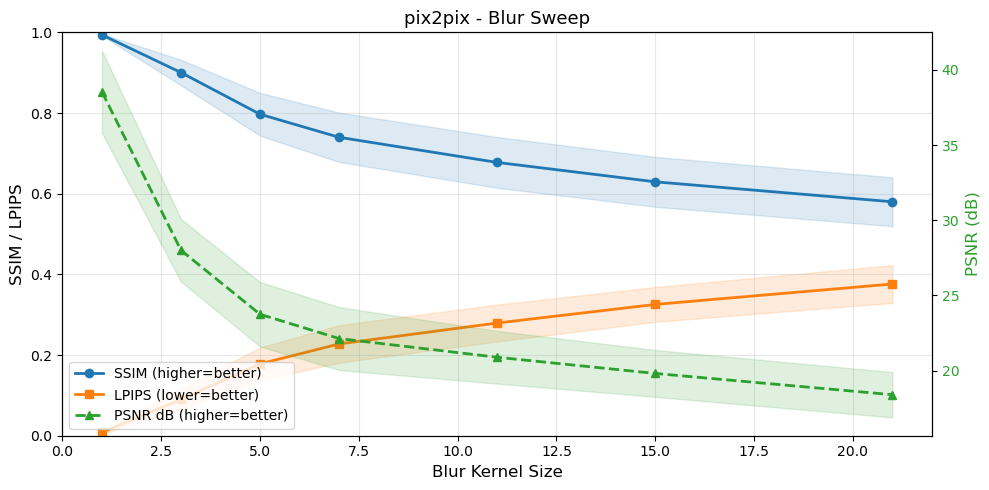

 kernel_size  ssim_mean  ssim_std  psnr_mean  psnr_std  lpips_mean  lpips_std  n_images
           1    0.99381   0.00201    38.5401    2.7344     0.00815    0.00301      7373
           3    0.90032   0.03160    28.0025    2.0805     0.09004    0.02682      7373
           5    0.79698   0.05305    23.7479    2.1437     0.17810    0.04061      7373
           7    0.73980   0.06116    22.1344    2.0906     0.22752    0.04646      7373
          11    0.67750   0.06299    20.8909    1.7528     0.27941    0.04578      7373
          15    0.62940   0.06182    19.8142    1.5574     0.32548    0.04314      7373
          21    0.57994   0.06053    18.4004    1.5072     0.37617    0.04691      7373


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('./blur_sweep_output/summary.csv')
ks = df['kernel_size'].values

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# SSIM - left axis
ax1.plot(ks, df['ssim_mean'], marker='o', color='tab:blue', linewidth=2, markersize=6, label='SSIM (higher=better)')
ax1.fill_between(ks, df['ssim_mean'] - df['ssim_std'], df['ssim_mean'] + df['ssim_std'], alpha=0.15, color='tab:blue')

# LPIPS - left axis
ax1.plot(ks, df['lpips_mean'], marker='s', color='tab:orange', linewidth=2, markersize=6, label='LPIPS (lower=better)')
ax1.fill_between(ks, df['lpips_mean'] - df['lpips_std'], df['lpips_mean'] + df['lpips_std'], alpha=0.15, color='tab:orange')

# PSNR - right axis
ax2.plot(ks, df['psnr_mean'], marker='^', color='tab:green', linewidth=2, markersize=6, label='PSNR dB (higher=better)', linestyle='--')
ax2.fill_between(ks, df['psnr_mean'] - df['psnr_std'], df['psnr_mean'] + df['psnr_std'], alpha=0.15, color='tab:green')

ax1.set_xlabel('Blur Kernel Size', fontsize=12)
ax1.set_ylabel('SSIM / LPIPS', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12, color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Combined legend from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title('pix2pix - Blur Sweep', fontsize=13)
plt.tight_layout()
plt.savefig('./blur_sweep_output/blur_sweep_metrics_1.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.to_string(index=False))


In [70]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer
# from PIL import Image

# dataset_name    = 'polyps_v7'
# INPUT_CHANNELS  = 1
# OUTPUT_CHANNELS = 3
# PATH            = pathlib.Path(r'./datasets') / dataset_name

# generator  = Generator()
# _ckpt      = tf.train.Checkpoint(generator=generator)
# _ckpt.restore(tf.train.latest_checkpoint('./training_checkpoints')).expect_partial()
# print('Checkpoint restored')

# CONTRAST_FACTORS = [-2.00, -1.50, -1.00, -0.50, -0.25, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00]
# SPLIT    = 'val'
# out_root = pathlib.Path('./contrast_sweep_output')
# out_root.mkdir(parents=True, exist_ok=True)

# loss_fn   = lpips.LPIPS(net='alex', verbose=False)
# image_fns = sorted((PATH / SPLIT).glob('*.tif'))
# print(f'{len(image_fns)} val images found')

# def cf_to_dirname(cf):
#     sign = 'neg' if cf < 0 else 'pos'
#     return f'contrast_{sign}_{abs(cf):.2f}'.replace('.', '_')

# summary_rows = []

# for cf in CONTRAST_FACTORS:
#     factor_dir = out_root / cf_to_dirname(cf)
#     factor_dir.mkdir(parents=True, exist_ok=True)
#     print()
#     print(f'contrast_factor={cf:+.2f} ({len(image_fns)} images) ...')
#     t0 = timer()

#     per_image_rows = []
#     ssim_list, psnr_list, lpips_list = [], [], []

#     for fn in image_fns:
#         raw   = tf.io.read_file(str(fn))
#         image = tfio.experimental.image.decode_tiff(raw)
#         half  = tf.shape(image)[1] // 2

#         gt  = tf.cast(image[:, :half, :3], tf.float32)
#         gt  = (gt / 127.5) - 1.0

#         inp    = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32)
#         inp    = (inp / 127.5) - 1.0
#         inp_cf = tf.clip_by_value(inp * cf, -1.0, 1.0)

#         pred = generator(inp_cf[tf.newaxis], training=True)[0]

#         pred_np = ((pred.numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)
#         Image.fromarray(pred_np).save(factor_dir / (fn.stem + '.tif'))

#         pred_01 = pred * 0.5 + 0.5
#         gt_01   = gt   * 0.5 + 0.5

#         ssim_val = float(tf.image.ssim(pred_01, gt_01, max_val=1))
#         psnr_val = float(tf.image.psnr(pred_01, gt_01, max_val=1))

#         pred_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(pred[tf.newaxis], [0,3,1,2]), tf.float32)))
#         gt_t   = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(gt[tf.newaxis],   [0,3,1,2]), tf.float32)))
#         with torch.no_grad():
#             lpips_val = float(loss_fn(pred_t, gt_t))

#         ssim_list.append(ssim_val)
#         psnr_list.append(psnr_val)
#         lpips_list.append(lpips_val)
#         per_image_rows.append({
#             'file':  fn.name,
#             'ssim':  round(ssim_val,  6),
#             'psnr':  round(psnr_val,  4),
#             'lpips': round(lpips_val, 6),
#         })

#     per_csv = factor_dir / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader()
#         wr.writerows(per_image_rows)

#     elapsed = timer() - t0
#     row = {
#         'contrast_factor': cf,
#         'ssim_mean':  round(np.mean(ssim_list),  5),
#         'ssim_std':   round(np.std(ssim_list),   5),
#         'psnr_mean':  round(np.mean(psnr_list),  4),
#         'psnr_std':   round(np.std(psnr_list),   4),
#         'lpips_mean': round(np.mean(lpips_list), 5),
#         'lpips_std':  round(np.std(lpips_list),  5),
#         'n_images':   len(image_fns),
#     }
#     summary_rows.append(row)
#     print(f"  SSIM   {row['ssim_mean']:.4f}  +/- {row['ssim_std']:.4f}")
#     print(f"  PSNR   {row['psnr_mean']:.2f} dB  +/- {row['psnr_std']:.2f}")
#     print(f"  LPIPS  {row['lpips_mean']:.4f}  +/- {row['lpips_std']:.4f}")
#     print(f"  Time   {elapsed:.1f}s")

# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['contrast_factor', 'ssim_mean', 'ssim_std',
#                'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader()
#     wr.writerows(summary_rows)
# print()
# print(f'Summary saved -> {summary_csv}')

In [71]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = pd.read_csv('./contrast_sweep_output/summary.csv')
# df = df.sort_values('contrast_factor').reset_index(drop=True)
# cf = df['contrast_factor'].values

# fig, ax1 = plt.subplots(figsize=(12, 5))
# ax2 = ax1.twinx()

# ax1.plot(cf, df['ssim_mean'], marker='o', color='tab:blue', linewidth=2, markersize=7, label='SSIM (higher=better)')
# ax1.fill_between(cf, df['ssim_mean'] - df['ssim_std'], df['ssim_mean'] + df['ssim_std'], alpha=0.15, color='tab:blue')

# ax1.plot(cf, df['lpips_mean'], marker='s', color='tab:orange', linewidth=2, markersize=7, label='LPIPS (lower=better)')
# ax1.fill_between(cf, df['lpips_mean'] - df['lpips_std'], df['lpips_mean'] + df['lpips_std'], alpha=0.15, color='tab:orange')

# ax2.plot(cf, df['psnr_mean'], marker='^', color='tab:green', linewidth=2, markersize=7, label='PSNR dB (higher=better)', linestyle='--')
# ax2.fill_between(cf, df['psnr_mean'] - df['psnr_std'], df['psnr_mean'] + df['psnr_std'], alpha=0.15, color='tab:green')

# ax1.axvline(1.0, color='gray', linestyle=':', linewidth=1.2, alpha=0.8, label='Baseline (cf=1.0)')
# ax1.axvline(0.0, color='red',  linestyle='--', linewidth=1.0, alpha=0.5, label='Zero (no signal)')

# ax1.set_xlabel('Contrast Factor', fontsize=12)
# ax1.set_ylabel('SSIM / LPIPS', fontsize=12)
# ax2.set_ylabel('PSNR (dB)', fontsize=12, color='tab:green')
# ax2.tick_params(axis='y', labelcolor='tab:green')

# ax1.set_xticks(cf)
# ax1.set_xticklabels([f'{v:+.2f}' for v in cf], rotation=45, ha='right', fontsize=9)
# ax1.set_ylim(0, 1)
# ax1.grid(True, alpha=0.3)

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

# plt.title('pix2pix - Contrast Sweep', fontsize=13)
# plt.tight_layout()
# plt.savefig('./contrast_sweep_output/contrast_sweep_metrics_1.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(df[['contrast_factor','ssim_mean','psnr_mean','lpips_mean']].to_string(index=False))

In [72]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer
# from PIL import Image

# dataset_name    = 'polyps_v7'
# INPUT_CHANNELS  = 1
# OUTPUT_CHANNELS = 3
# PATH            = pathlib.Path(r'./datasets') / dataset_name

# generator  = Generator()
# _ckpt      = tf.train.Checkpoint(generator=generator)
# _ckpt.restore(tf.train.latest_checkpoint('./training_checkpoints')).expect_partial()
# print('Checkpoint restored')

# cf       = 0.00
# SPLIT    = 'val'
# out_root = pathlib.Path('./contrast_sweep_output')
# out_root.mkdir(parents=True, exist_ok=True)
# factor_dir = out_root / 'contrast_pos_0_00'
# factor_dir.mkdir(parents=True, exist_ok=True)

# loss_fn   = lpips.LPIPS(net='alex', verbose=False)
# image_fns = sorted((PATH / SPLIT).glob('*.tif'))
# print(f'{len(image_fns)} val images found')
# print(f'contrast_factor={cf:+.2f} ({len(image_fns)} images) ...')
# t0 = timer()

# per_image_rows = []
# ssim_list, psnr_list, lpips_list = [], [], []

# for fn in image_fns:
#     raw   = tf.io.read_file(str(fn))
#     image = tfio.experimental.image.decode_tiff(raw)
#     half  = tf.shape(image)[1] // 2

#     gt  = tf.cast(image[:, :half, :3], tf.float32)
#     gt  = (gt / 127.5) - 1.0

#     inp    = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32)
#     inp    = (inp / 127.5) - 1.0
#     inp_cf = tf.zeros_like(inp)  # cf=0 -> blank input

#     pred = generator(inp_cf[tf.newaxis], training=True)[0]

#     pred_np = ((pred.numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)
#     Image.fromarray(pred_np).save(factor_dir / (fn.stem + '.tif'))

#     pred_01 = pred * 0.5 + 0.5
#     gt_01   = gt   * 0.5 + 0.5

#     ssim_val = float(tf.image.ssim(pred_01, gt_01, max_val=1))
#     psnr_val = float(tf.image.psnr(pred_01, gt_01, max_val=1))

#     pred_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(pred[tf.newaxis], [0,3,1,2]), tf.float32)))
#     gt_t   = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(gt[tf.newaxis],   [0,3,1,2]), tf.float32)))
#     with torch.no_grad():
#         lpips_val = float(loss_fn(pred_t, gt_t))

#     ssim_list.append(ssim_val)
#     psnr_list.append(psnr_val)
#     lpips_list.append(lpips_val)
#     per_image_rows.append({'file': fn.name, 'ssim': round(ssim_val, 6), 'psnr': round(psnr_val, 4), 'lpips': round(lpips_val, 6)})

# per_csv = factor_dir / 'metrics.csv'
# with open(per_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#     wr.writeheader(); wr.writerows(per_image_rows)

# elapsed = timer() - t0
# row = {
#     'contrast_factor': cf,
#     'ssim_mean':  round(np.mean(ssim_list),  5),
#     'ssim_std':   round(np.std(ssim_list),   5),
#     'psnr_mean':  round(np.mean(psnr_list),  4),
#     'psnr_std':   round(np.std(psnr_list),   4),
#     'lpips_mean': round(np.mean(lpips_list), 5),
#     'lpips_std':  round(np.std(lpips_list),  5),
#     'n_images':   len(image_fns),
# }

# # Append to existing summary.csv
# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['contrast_factor', 'ssim_mean', 'ssim_std', 'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']
# write_header = not summary_csv.exists()
# with open(summary_csv, 'a', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     if write_header:
#         wr.writeheader()
#     wr.writerow(row)

# print(f"  SSIM   {row['ssim_mean']:.4f}  +/- {row['ssim_std']:.4f}")
# print(f"  PSNR   {row['psnr_mean']:.2f} dB  +/- {row['psnr_std']:.2f}")
# print(f"  LPIPS  {row['lpips_mean']:.4f}  +/- {row['lpips_std']:.4f}")
# print(f"  Time   {elapsed:.1f}s")
# print(f"Appended to {summary_csv}")

### Recompute contrast sweep metrics vs clean prediction (no re-run needed)

In [73]:
# # Recompute contrast sweep metrics from the ALREADY-SAVED predictions
# # (no re-run of the generator) -> compares each perturbed prediction
# # against the clean prediction (contrast_factor=1.00, i.e. unperturbed
# # input), the same way the blur sweep does, instead of against ground truth.
# # No numpy/PIL: images are decoded straight to tensors via tensorflow_io,
# # and the LPIPS tensor is bridged to torch via DLPack (same as the blur sweep).
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import statistics
# import pathlib
# import csv

# out_root = pathlib.Path('./contrast_sweep_output')
# CONTRAST_FACTORS = [-2.00, -1.50, -1.00, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00]
# BASELINE_FACTOR  = 1.00  # cf=1.0 -> input unchanged -> this is the "clean" prediction
# PSNR_CAP = 100.0  # sentinel for identical images (true PSNR is infinite when MSE=0)

# def cf_to_dirname(cf):
#     sign = 'neg' if cf < 0 else 'pos'
#     return f'contrast_{sign}_{abs(cf):.2f}'.replace('.', '_')

# def load_pred(fn):
#     raw = tf.io.read_file(str(fn))
#     img = tfio.experimental.image.decode_tiff(raw)[:, :, :3]
#     return tf.cast(img, tf.float32) / 255.0  # [0, 1]

# loss_fn = lpips.LPIPS(net='alex', verbose=False)

# clean_dir = out_root / cf_to_dirname(BASELINE_FACTOR)
# clean_fns = sorted(clean_dir.glob('*.tif'))
# print(f'{len(clean_fns)} clean (baseline) predictions found in {clean_dir}')

# summary_rows = []

# for cf in CONTRAST_FACTORS:
#     factor_dir = out_root / cf_to_dirname(cf)
#     if not factor_dir.exists():
#         print(f'skip contrast_factor={cf:+.2f}: {factor_dir} not found')
#         continue

#     if cf == BASELINE_FACTOR:
#         # baseline vs itself -> byte-identical files -> MSE=0 -> PSNR is mathematically
#         # infinite. Skip the (pointless) per-image compute and report the trivial values,
#         # using PSNR_CAP instead of inf so it doesn't poison summary.csv / the plots.
#         per_image_rows = [{'file': fn.name, 'ssim': 1.0, 'psnr': PSNR_CAP, 'lpips': 0.0} for fn in clean_fns]
#         ssim_list  = [1.0] * len(clean_fns)
#         psnr_list  = [PSNR_CAP] * len(clean_fns)
#         lpips_list = [0.0] * len(clean_fns)
#     else:
#         per_image_rows = []
#         ssim_list, psnr_list, lpips_list = [], [], []

#         for clean_fn in clean_fns:
#             pred_fn = factor_dir / clean_fn.name
#             if not pred_fn.exists():
#                 continue

#             clean_01 = load_pred(clean_fn)
#             pred_01  = load_pred(pred_fn)

#             ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))
#             psnr_val = float(tf.image.psnr(pred_01, clean_01, max_val=1))

#             # LPIPS expects [-1, 1], shape [1, C, H, W] -> bridge TF to torch via DLPack (no numpy)
#             pred_m  = tf.cast(tf.transpose((pred_01  * 2 - 1)[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#             clean_m = tf.cast(tf.transpose((clean_01 * 2 - 1)[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#             pred_t  = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(pred_m))
#             clean_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(clean_m))
#             with torch.no_grad():
#                 lpips_val = float(loss_fn(pred_t, clean_t))

#             ssim_list.append(ssim_val)
#             psnr_list.append(psnr_val)
#             lpips_list.append(lpips_val)
#             per_image_rows.append({
#                 'file':  clean_fn.name,
#                 'ssim':  round(ssim_val,  6),
#                 'psnr':  round(psnr_val,  4),
#                 'lpips': round(lpips_val, 6),
#             })

#     # overwrite the per-image CSV in each factor's folder
#     per_csv = factor_dir / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader()
#         wr.writerows(per_image_rows)

#     row = {
#         'contrast_factor': cf,
#         'ssim_mean':  round(statistics.mean(ssim_list),   5),
#         'ssim_std':   round(statistics.pstdev(ssim_list), 5),
#         'psnr_mean':  round(statistics.mean(psnr_list),   4),
#         'psnr_std':   round(statistics.pstdev(psnr_list), 4),
#         'lpips_mean': round(statistics.mean(lpips_list),   5),
#         'lpips_std':  round(statistics.pstdev(lpips_list), 5),
#         'n_images':   len(ssim_list),
#     }
#     summary_rows.append(row)
#     print(f"contrast_factor={cf:+.2f}  SSIM {row['ssim_mean']:.4f}  PSNR {row['psnr_mean']:.2f} dB  LPIPS {row['lpips_mean']:.4f}  (n={row['n_images']})")

# summary_rows.sort(key=lambda r: r['contrast_factor'])
# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['contrast_factor', 'ssim_mean', 'ssim_std',
#                'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader()
#     wr.writerows(summary_rows)
# print()
# print(f'Summary saved -> {summary_csv}')

In [74]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = pd.read_csv('./contrast_sweep_output/summary.csv')
# df = df.sort_values('contrast_factor').reset_index(drop=True)
# cf = df['contrast_factor'].values

# fig, ax1 = plt.subplots(figsize=(14, 5))
# ax2 = ax1.twinx()

# ax1.plot(cf, df['ssim_mean'], marker='o', color='tab:blue', linewidth=2, markersize=7, label='SSIM (higher=better)')
# ax1.fill_between(cf, df['ssim_mean'] - df['ssim_std'], df['ssim_mean'] + df['ssim_std'], alpha=0.15, color='tab:blue')

# ax1.plot(cf, df['lpips_mean'], marker='s', color='tab:orange', linewidth=2, markersize=7, label='LPIPS (lower=better)')
# ax1.fill_between(cf, df['lpips_mean'] - df['lpips_std'], df['lpips_mean'] + df['lpips_std'], alpha=0.15, color='tab:orange')

# ax2.plot(cf, df['psnr_mean'], marker='^', color='tab:green', linewidth=2, markersize=7, label='PSNR dB (higher=better)', linestyle='--')
# ax2.fill_between(cf, df['psnr_mean'] - df['psnr_std'], df['psnr_mean'] + df['psnr_std'], alpha=0.15, color='tab:green')

# ax1.axvline(1.0, color='gray', linestyle=':',  linewidth=1.5, alpha=0.8, label='Baseline (cf=1.0)')
# ax1.axvline(0.0, color='red',  linestyle='--', linewidth=1.2, alpha=0.6, label='Zero (blank input)')

# ax1.set_xlabel('Contrast Factor', fontsize=12)
# ax1.set_ylabel('SSIM / LPIPS', fontsize=12)
# ax2.set_ylabel('PSNR (dB)', fontsize=12, color='tab:green')
# ax2.tick_params(axis='y', labelcolor='tab:green')

# ax1.set_xticks(cf)
# ax1.set_xticklabels([f'{v:+.2f}' for v in cf], rotation=45, ha='right', fontsize=9)
# ax1.set_ylim(0, 1)
# ax1.grid(True, alpha=0.3)

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

# plt.title('pix2pix -Contrast Sweep', fontsize=13)
# plt.tight_layout()
# plt.savefig('./contrast_sweep_output/contrast_sweep_metrics_all_1.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(df[['contrast_factor', 'ssim_mean', 'psnr_mean', 'lpips_mean']].to_string(index=False))

### Fine contrast sweep: 0.00-2.00 in steps of 0.05 (generates only missing factors, then recomputes metrics)

In [75]:
# # Fine-grained contrast sweep: contrast_factor from 0.00 to 2.00 in steps of 0.05.
# # Only generates the factors that are NOT already on disk (resumable / safe to re-run) -
# # existing folders (0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00) are skipped.
# # After generation, recomputes metrics for the whole 0.00-2.00 range against the
# # clean prediction baseline (contrast_factor=1.00) and merges them into
# # contrast_sweep_output/summary.csv, keeping the existing negative-factor rows.
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# import statistics
# from timeit import default_timer as timer
# from PIL import Image

# dataset_name    = 'polyps_v7'
# INPUT_CHANNELS  = 1
# OUTPUT_CHANNELS = 3
# PATH            = pathlib.Path(r'./datasets') / dataset_name

# generator  = Generator()
# _ckpt      = tf.train.Checkpoint(generator=generator)
# _ckpt.restore(tf.train.latest_checkpoint('./training_checkpoints')).expect_partial()
# print('Checkpoint restored')

# out_root        = pathlib.Path('./contrast_sweep_output')
# SPLIT           = 'val'
# BASELINE_FACTOR = 1.00
# PSNR_CAP        = 100.0  # sentinel for identical images (true PSNR is infinite when MSE=0)

# # 0.00, 0.05, 0.10, ..., 2.00 (41 levels)
# FINE_CONTRAST_FACTORS = [round(i * 0.05, 2) for i in range(0, 41)]

# def cf_to_dirname(cf):
#     sign = 'neg' if cf < 0 else 'pos'
#     return f'contrast_{sign}_{abs(cf):.2f}'.replace('.', '_')

# def load_pred(fn):
#     raw = tf.io.read_file(str(fn))
#     img = tfio.experimental.image.decode_tiff(raw)[:, :, :3]
#     return tf.cast(img, tf.float32) / 255.0  # [0, 1]

# image_fns = sorted((PATH / SPLIT).glob('*.tif'))
# print(f'{len(image_fns)} val images found')

# # ---------------------------------------------------------------------------
# # Step 1: generate predictions only for the contrast factors not yet on disk
# # ---------------------------------------------------------------------------
# for cf in FINE_CONTRAST_FACTORS:
#     factor_dir = out_root / cf_to_dirname(cf)
#     already = list(factor_dir.glob('*.tif')) if factor_dir.exists() else []
#     if len(already) >= len(image_fns):
#         print(f'contrast_factor={cf:.2f}: already generated ({len(already)} files) -> skip')
#         continue

#     factor_dir.mkdir(parents=True, exist_ok=True)
#     print(f'generating contrast_factor={cf:.2f} ({len(image_fns)} images) ...')
#     t0 = timer()

#     for fn in image_fns:
#         raw   = tf.io.read_file(str(fn))
#         image = tfio.experimental.image.decode_tiff(raw)
#         half  = tf.shape(image)[1] // 2

#         inp    = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32)
#         inp    = (inp / 127.5) - 1.0
#         inp_cf = tf.clip_by_value(inp * cf, -1.0, 1.0)

#         pred = generator(inp_cf[tf.newaxis], training=True)[0]

#         pred_np = ((pred.numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)
#         Image.fromarray(pred_np).save(factor_dir / (fn.stem + '.tif'))

#     elapsed = timer() - t0
#     print(f'  done in {elapsed:.1f}s -> {factor_dir}')

# # ---------------------------------------------------------------------------
# # Step 2: recompute SSIM / PSNR / LPIPS for the whole 0.00-2.00 range vs the
# # clean prediction baseline (contrast_factor=1.00), then merge into summary.csv
# # ---------------------------------------------------------------------------
# loss_fn = lpips.LPIPS(net='alex', verbose=False)

# clean_dir = out_root / cf_to_dirname(BASELINE_FACTOR)
# clean_fns = sorted(clean_dir.glob('*.tif'))
# print(f'\n{len(clean_fns)} clean (baseline) predictions found in {clean_dir}')

# fine_rows = {}

# for cf in FINE_CONTRAST_FACTORS:
#     factor_dir = out_root / cf_to_dirname(cf)
#     if not factor_dir.exists():
#         print(f'skip contrast_factor={cf:.2f}: {factor_dir} not found')
#         continue

#     if cf == BASELINE_FACTOR:
#         per_image_rows = [{'file': fn.name, 'ssim': 1.0, 'psnr': PSNR_CAP, 'lpips': 0.0} for fn in clean_fns]
#         ssim_list  = [1.0] * len(clean_fns)
#         psnr_list  = [PSNR_CAP] * len(clean_fns)
#         lpips_list = [0.0] * len(clean_fns)
#     else:
#         per_image_rows = []
#         ssim_list, psnr_list, lpips_list = [], [], []

#         for clean_fn in clean_fns:
#             pred_fn = factor_dir / clean_fn.name
#             if not pred_fn.exists():
#                 continue

#             clean_01 = load_pred(clean_fn)
#             pred_01  = load_pred(pred_fn)

#             ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))
#             psnr_val = float(tf.image.psnr(pred_01, clean_01, max_val=1))

#             pred_m  = tf.cast(tf.transpose((pred_01  * 2 - 1)[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#             clean_m = tf.cast(tf.transpose((clean_01 * 2 - 1)[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#             pred_t  = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(pred_m))
#             clean_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(clean_m))
#             with torch.no_grad():
#                 lpips_val = float(loss_fn(pred_t, clean_t))

#             ssim_list.append(ssim_val)
#             psnr_list.append(psnr_val)
#             lpips_list.append(lpips_val)
#             per_image_rows.append({
#                 'file':  clean_fn.name,
#                 'ssim':  round(ssim_val,  6),
#                 'psnr':  round(psnr_val,  4),
#                 'lpips': round(lpips_val, 6),
#             })

#     per_csv = factor_dir / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader()
#         wr.writerows(per_image_rows)

#     row = {
#         'contrast_factor': cf,
#         'ssim_mean':  round(statistics.mean(ssim_list),   5),
#         'ssim_std':   round(statistics.pstdev(ssim_list), 5),
#         'psnr_mean':  round(statistics.mean(psnr_list),   4),
#         'psnr_std':   round(statistics.pstdev(psnr_list), 4),
#         'lpips_mean': round(statistics.mean(lpips_list),   5),
#         'lpips_std':  round(statistics.pstdev(lpips_list), 5),
#         'n_images':   len(ssim_list),
#     }
#     fine_rows[cf] = row
#     print(f"contrast_factor={cf:.2f}  SSIM {row['ssim_mean']:.4f}  PSNR {row['psnr_mean']:.2f} dB  LPIPS {row['lpips_mean']:.4f}  (n={row['n_images']})")

# # ---------------------------------------------------------------------------
# # Step 3: merge into summary.csv -> keep existing rows outside [0, 2],
# # replace/insert rows for the fine 0.00-2.00 grid.
# # ---------------------------------------------------------------------------
# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['contrast_factor', 'ssim_mean', 'ssim_std',
#                'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']

# existing_rows = {}
# if summary_csv.exists():
#     with open(summary_csv, newline='') as fh:
#         for r in csv.DictReader(fh):
#             existing_rows[float(r['contrast_factor'])] = r

# merged = dict(existing_rows)
# merged.update({cf: row for cf, row in fine_rows.items()})

# sorted_rows = [merged[k] for k in sorted(merged.keys())]
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader()
#     wr.writerows(sorted_rows)

# print()
# print(f'Summary saved -> {summary_csv}  ({len(sorted_rows)} rows total)')


### Plot: fine contrast sweep metrics (0.00-2.00)

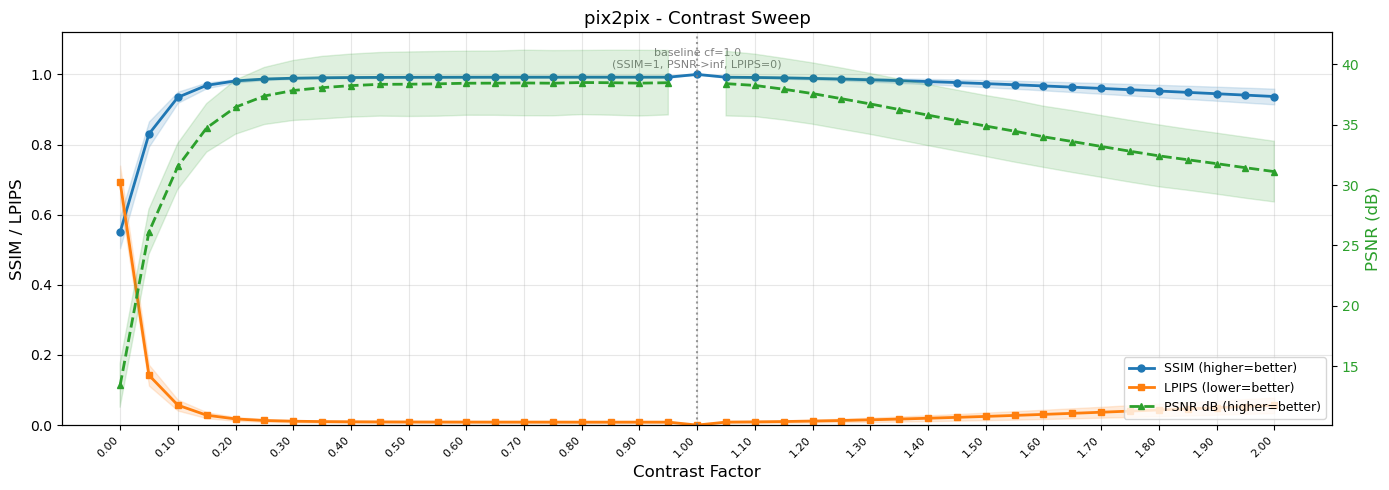

 contrast_factor  ssim_mean  psnr_mean  lpips_mean
            0.00    0.55015    13.4136     0.69295
            0.05    0.83015    26.1236     0.14217
            0.10    0.93471    31.5396     0.05679
            0.15    0.96885    34.7293     0.02814
            0.20    0.98145    36.4446     0.01747
            0.25    0.98676    37.3703     0.01302
            0.30    0.98920    37.8255     0.01094
            0.35    0.99044    38.0593     0.00992
            0.40    0.99113    38.2295     0.00933
            0.45    0.99152    38.3350     0.00899
            0.50    0.99175    38.3448     0.00877
            0.55    0.99190    38.3755     0.00865
            0.60    0.99200    38.4277     0.00854
            0.65    0.99209    38.4320     0.00844
            0.70    0.99212    38.4481     0.00845
            0.75    0.99214    38.4288     0.00841
            0.80    0.99221    38.4856     0.00832
            0.85    0.99220    38.4690     0.00832
            0.90    0.99219    

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./contrast_sweep_output/summary.csv')
df = df[(df['contrast_factor'] >= 0) & (df['contrast_factor'] <= 2)].sort_values('contrast_factor').reset_index(drop=True)
cf = df['contrast_factor'].values

BASELINE = 1.0
is_baseline = df['contrast_factor'] == BASELINE

# PSNR at the baseline (cf=1.0) is capped at 100 in the CSV (true value is infinite,
# since it's the prediction compared against itself) -> drop it from the line so it
# doesn't blow out the axis scale, and annotate it separately instead.
psnr_plot     = df['psnr_mean'].where(~is_baseline)
psnr_std_plot = df['psnr_std'].where(~is_baseline)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(cf, df['ssim_mean'], marker='o', color='tab:blue', linewidth=2, markersize=5, label='SSIM (higher=better)')
ax1.fill_between(cf, df['ssim_mean'] - df['ssim_std'], df['ssim_mean'] + df['ssim_std'], alpha=0.15, color='tab:blue')

ax1.plot(cf, df['lpips_mean'], marker='s', color='tab:orange', linewidth=2, markersize=5, label='LPIPS (lower=better)')
ax1.fill_between(cf, df['lpips_mean'] - df['lpips_std'], df['lpips_mean'] + df['lpips_std'], alpha=0.15, color='tab:orange')

ax2.plot(cf, psnr_plot, marker='^', color='tab:green', linewidth=2, markersize=5, linestyle='--', label='PSNR dB (higher=better)')
ax2.fill_between(cf, psnr_plot - psnr_std_plot, psnr_plot + psnr_std_plot, alpha=0.15, color='tab:green')

ax1.axvline(BASELINE, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax1.annotate('baseline cf=1.0\n(SSIM=1, PSNR->inf, LPIPS=0)',
             xy=(BASELINE, 1.02), ha='center', fontsize=8, color='gray')

ax1.set_xlabel('Contrast Factor', fontsize=12)
ax1.set_ylabel('SSIM / LPIPS', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12, color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.set_xticks(cf[::2])
ax1.set_xticklabels([f'{v:.2f}' for v in cf[::2]], rotation=45, ha='right', fontsize=8)
ax1.set_ylim(0, 1.12)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')

plt.title('pix2pix - Contrast Sweep', fontsize=13)
plt.tight_layout()
plt.savefig('./contrast_sweep_output/contrast_sweep_metrics_fine_0_2_1.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['contrast_factor', 'ssim_mean', 'psnr_mean', 'lpips_mean']].to_string(index=False))


In [77]:
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer
# from PIL import Image

# dataset_name    = 'polyps_v7'
# INPUT_CHANNELS  = 1
# OUTPUT_CHANNELS = 3
# PATH            = pathlib.Path(r'./datasets') / dataset_name

# generator  = Generator()
# _ckpt      = tf.train.Checkpoint(generator=generator)
# _ckpt.restore(tf.train.latest_checkpoint('./training_checkpoints')).expect_partial()
# print('Checkpoint restored')

# NOISE_STDS = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]  # 0.0 = no noise (baseline)
# SPLIT    = 'val'
# out_root = pathlib.Path('./gaussian_sweep_output')
# out_root.mkdir(parents=True, exist_ok=True)

# loss_fn   = lpips.LPIPS(net='alex', verbose=False)
# image_fns = sorted((PATH / SPLIT).glob('*.tif'))
# print(f'{len(image_fns)} val images found')

# summary_rows = []

# for std in NOISE_STDS:
#     std_dir = out_root / f'std_{std:.2f}'.replace('.', '_')
#     std_dir.mkdir(parents=True, exist_ok=True)
#     print()
#     print(f'noise_std={std:.2f} ({len(image_fns)} images) ...')
#     t0 = timer()

#     per_image_rows = []
#     ssim_list, psnr_list, lpips_list = [], [], []

#     for fn in image_fns:
#         raw   = tf.io.read_file(str(fn))
#         image = tfio.experimental.image.decode_tiff(raw)
#         half  = tf.shape(image)[1] // 2

#         gt  = tf.cast(image[:, :half, :3], tf.float32)
#         gt  = (gt / 127.5) - 1.0

#         inp     = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32)
#         inp     = (inp / 127.5) - 1.0
#         if std > 0:
#             noise   = tf.random.normal(shape=tf.shape(inp), stddev=std)
#             inp_noisy = tf.clip_by_value(inp + noise, -1.0, 1.0)
#         else:
#             inp_noisy = inp  # baseline, no noise

#         pred = generator(inp_noisy[tf.newaxis], training=True)[0]

#         pred_np = ((pred.numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)
#         Image.fromarray(pred_np).save(std_dir / (fn.stem + '.tif'))

#         pred_01 = pred * 0.5 + 0.5
#         gt_01   = gt   * 0.5 + 0.5

#         ssim_val = float(tf.image.ssim(pred_01, gt_01, max_val=1))
#         psnr_val = float(tf.image.psnr(pred_01, gt_01, max_val=1))

#         pred_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(pred[tf.newaxis], [0,3,1,2]), tf.float32)))
#         gt_t   = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(tf.cast(tf.transpose(gt[tf.newaxis],   [0,3,1,2]), tf.float32)))
#         with torch.no_grad():
#             lpips_val = float(loss_fn(pred_t, gt_t))

#         ssim_list.append(ssim_val)
#         psnr_list.append(psnr_val)
#         lpips_list.append(lpips_val)
#         per_image_rows.append({'file': fn.name, 'ssim': round(ssim_val, 6), 'psnr': round(psnr_val, 4), 'lpips': round(lpips_val, 6)})

#     per_csv = std_dir / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader(); wr.writerows(per_image_rows)

#     elapsed = timer() - t0
#     row = {
#         'noise_std':  std,
#         'ssim_mean':  round(np.mean(ssim_list),  5),
#         'ssim_std':   round(np.std(ssim_list),   5),
#         'psnr_mean':  round(np.mean(psnr_list),  4),
#         'psnr_std':   round(np.std(psnr_list),   4),
#         'lpips_mean': round(np.mean(lpips_list), 5),
#         'lpips_std':  round(np.std(lpips_list),  5),
#         'n_images':   len(image_fns),
#     }
#     summary_rows.append(row)
#     print(f"  SSIM   {row['ssim_mean']:.4f}  +/- {row['ssim_std']:.4f}")
#     print(f"  PSNR   {row['psnr_mean']:.2f} dB  +/- {row['psnr_std']:.2f}")
#     print(f"  LPIPS  {row['lpips_mean']:.4f}  +/- {row['lpips_std']:.4f}")
#     print(f"  Time   {elapsed:.1f}s")

# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['noise_std', 'ssim_mean', 'ssim_std', 'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader(); wr.writerows(summary_rows)
# print()
# print(f'Summary saved -> {summary_csv}')

### Recompute gaussian noise sweep metrics vs clean prediction (no re-run needed)

In [78]:
# # Recompute gaussian noise sweep metrics from the ALREADY-SAVED predictions
# # (no re-run of the generator) -> compares each perturbed prediction
# # against the clean prediction (noise_std=0.00), the same way the blur
# # sweep does, instead of against ground truth.
# # No numpy/PIL: images are decoded straight to tensors via tensorflow_io,
# # and the LPIPS tensor is bridged to torch via DLPack (same as the blur sweep).
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import statistics
# import pathlib
# import csv

# out_root   = pathlib.Path('./gaussian_sweep_output')
# NOISE_STDS = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]  # 0.0 = baseline (clean)
# BASELINE_STD = 0.00
# PSNR_CAP = 100.0  # sentinel for identical images (true PSNR is infinite when MSE=0)

# def std_to_dirname(std):
#     return f'std_{std:.2f}'.replace('.', '_')

# def load_pred(fn):
#     raw = tf.io.read_file(str(fn))
#     img = tfio.experimental.image.decode_tiff(raw)[:, :, :3]
#     return tf.cast(img, tf.float32) / 255.0  # [0, 1]

# loss_fn = lpips.LPIPS(net='alex', verbose=False)

# clean_dir = out_root / std_to_dirname(0.00)
# clean_fns = sorted(clean_dir.glob('*.tif'))
# print(f'{len(clean_fns)} clean (baseline) predictions found in {clean_dir}')

# summary_rows = []

# for std in NOISE_STDS:
#     std_dir = out_root / std_to_dirname(std)
#     if not std_dir.exists():
#         print(f'skip noise_std={std:.2f}: {std_dir} not found')
#         continue

#     if std == BASELINE_STD:
#         # baseline vs itself -> byte-identical files -> MSE=0 -> PSNR is mathematically
#         # infinite. Skip the (pointless) per-image compute and report the trivial values,
#         # using PSNR_CAP instead of inf so it doesn't poison summary.csv / the plots.
#         per_image_rows = [{'file': fn.name, 'ssim': 1.0, 'psnr': PSNR_CAP, 'lpips': 0.0} for fn in clean_fns]
#         ssim_list  = [1.0] * len(clean_fns)
#         psnr_list  = [PSNR_CAP] * len(clean_fns)
#         lpips_list = [0.0] * len(clean_fns)
#     else:
#         per_image_rows = []
#         ssim_list, psnr_list, lpips_list = [], [], []

#         for clean_fn in clean_fns:
#             pred_fn = std_dir / clean_fn.name
#             if not pred_fn.exists():
#                 continue

#             clean_01 = load_pred(clean_fn)
#             pred_01  = load_pred(pred_fn)

#             ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))
#             psnr_val = float(tf.image.psnr(pred_01, clean_01, max_val=1))

#             # LPIPS expects [-1, 1], shape [1, C, H, W] -> bridge TF to torch via DLPack (no numpy)
#             pred_m  = tf.cast(tf.transpose((pred_01  * 2 - 1)[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#             clean_m = tf.cast(tf.transpose((clean_01 * 2 - 1)[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#             pred_t  = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(pred_m))
#             clean_t = torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(clean_m))
#             with torch.no_grad():
#                 lpips_val = float(loss_fn(pred_t, clean_t))

#             ssim_list.append(ssim_val)
#             psnr_list.append(psnr_val)
#             lpips_list.append(lpips_val)
#             per_image_rows.append({
#                 'file':  clean_fn.name,
#                 'ssim':  round(ssim_val,  6),
#                 'psnr':  round(psnr_val,  4),
#                 'lpips': round(lpips_val, 6),
#             })

#     # overwrite the per-image CSV in each std's folder
#     per_csv = std_dir / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader()
#         wr.writerows(per_image_rows)

#     row = {
#         'noise_std':  std,
#         'ssim_mean':  round(statistics.mean(ssim_list),   5),
#         'ssim_std':   round(statistics.pstdev(ssim_list), 5),
#         'psnr_mean':  round(statistics.mean(psnr_list),   4),
#         'psnr_std':   round(statistics.pstdev(psnr_list), 4),
#         'lpips_mean': round(statistics.mean(lpips_list),   5),
#         'lpips_std':  round(statistics.pstdev(lpips_list), 5),
#         'n_images':   len(ssim_list),
#     }
#     summary_rows.append(row)
#     print(f"noise_std={std:.2f}  SSIM {row['ssim_mean']:.4f}  PSNR {row['psnr_mean']:.2f} dB  LPIPS {row['lpips_mean']:.4f}  (n={row['n_images']})")

# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['noise_std', 'ssim_mean', 'ssim_std',
#                'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader()
#     wr.writerows(summary_rows)
# print()
# print(f'Summary saved -> {summary_csv}')



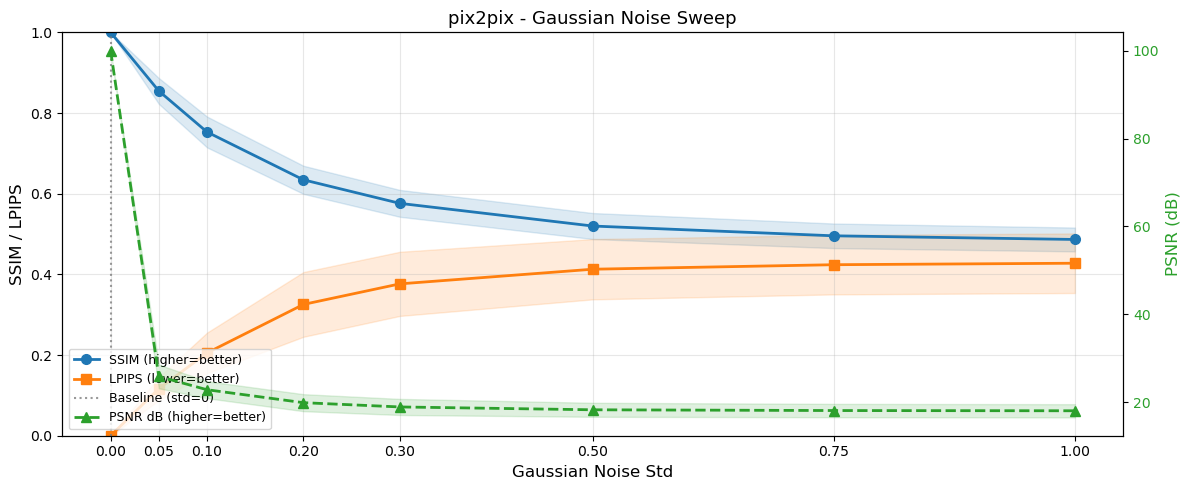

 noise_std  ssim_mean  psnr_mean  lpips_mean
      0.00    1.00000   100.0000     0.00000
      0.05    0.85460    25.8409     0.11662
      0.10    0.75292    22.8277     0.20531
      0.20    0.63438    19.8821     0.32551
      0.30    0.57601    18.9107     0.37647
      0.50    0.51983    18.2634     0.41276
      0.75    0.49557    18.0916     0.42393
      1.00    0.48651    18.0382     0.42763


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('./gaussian_sweep_output/summary.csv')
std_vals = df['noise_std'].values

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(std_vals, df['ssim_mean'], marker='o', color='tab:blue', linewidth=2, markersize=7, label='SSIM (higher=better)')
ax1.fill_between(std_vals, df['ssim_mean'] - df['ssim_std'], df['ssim_mean'] + df['ssim_std'], alpha=0.15, color='tab:blue')

ax1.plot(std_vals, df['lpips_mean'], marker='s', color='tab:orange', linewidth=2, markersize=7, label='LPIPS (lower=better)')
ax1.fill_between(std_vals, df['lpips_mean'] - df['lpips_std'], df['lpips_mean'] + df['lpips_std'], alpha=0.15, color='tab:orange')

ax2.plot(std_vals, df['psnr_mean'], marker='^', color='tab:green', linewidth=2, markersize=7, label='PSNR dB (higher=better)', linestyle='--')
ax2.fill_between(std_vals, df['psnr_mean'] - df['psnr_std'], df['psnr_mean'] + df['psnr_std'], alpha=0.15, color='tab:green')

ax1.axvline(0.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.8, label='Baseline (std=0)')

ax1.set_xlabel('Gaussian Noise Std', fontsize=12)
ax1.set_ylabel('SSIM / LPIPS', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12, color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.set_xticks(std_vals)
ax1.set_xticklabels([f'{v:.2f}' for v in std_vals], fontsize=10)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

plt.title('pix2pix - Gaussian Noise Sweep', fontsize=13)
plt.tight_layout()
plt.savefig('./gaussian_sweep_output/gaussian_sweep_metrics_1.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['noise_std', 'ssim_mean', 'psnr_mean', 'lpips_mean']].to_string(index=False))

### Blur
1. Parameter : 1, 3, 5, 7, 11, 15, 21 --> 1 as baseline
    - Chose odd parameter bcs they are valid for symmetric conv kernels (avg_pool2d requires odd ksize). 
    - 1 -> 21 : to cover fine blur
    - 3 -> 5 : compare the optical defocus
    - 15 -> 21 : eq. to heavy out-of-focus or diffusion

2. Average pooling removes high-frequency detail progressively, and the generator relies on those fine structures in the phase image to reconstruct accurate colour and texture

### Contrast
1. Parameter : -2.00 to +2.00

2. Negative factors, −2.00 → −0.25: all flat. The phase is inverted, the model is stuck at low performance, and the magnitude makes no difference. All negative factors produce nearly identical results.

3. Centre (cf=0, red dashed line)
 LPIPS spikes to ~0.71 and PSNR drops to ~12.7 dB — the worst case across the entire sweep, because the model receives a blank input and produces an unconditioned hallucination.

4. Right (positive factors, +0.25 → +2.00): an immediate jump to high performance and then flat. The model is indifferent to how bright or dim the input is, as long as the sign is correct.

This demonstrates that the model is sensitive to phase polarity (the sign of the phase signal), not its amplitude. This is a physically meaningful result: in phase contrast microscopy, an inverted phase represents a fundamentally different optical configuration that the model was never trained on.

### Gaussian Noise
1. Parameter : 0.00 to 1.00

### PSNR (Peak Signal-to-Noise Ratio)
Measures pixel-level fidelity in decibels (dB), computed from the Mean Squared Error (MSE) between pixels. Higher = better. Highly sensitive to small pixel changes but does not always correlate with perceptual quality.

### Reference: clean (unoccluded) predictions for the 3 fixed samples

In [80]:
# # Show the clean (unoccluded) prediction for the 3 fixed_samples, for comparison
# # against the sliding-window occlusion results below.
# fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# for idx, (test_input, ground_truth) in enumerate(fixed_samples):
#     inp = test_input[0]
#     gt  = ground_truth[0]
#     clean_pred = generator(test_input, training=True)[0]

#     phase = np.repeat(inp[:, :, 0:1].numpy(), 3, axis=2)

#     axes[idx, 0].imshow(phase * 0.5 + 0.5, cmap='gray')
#     axes[idx, 0].set_title(f'Sample {idx + 1} - Phase', fontsize=11)
#     axes[idx, 1].imshow(clean_pred.numpy() * 0.5 + 0.5)
#     axes[idx, 1].set_title(f'Sample {idx + 1} - Clean Pred', fontsize=11)
#     axes[idx, 2].imshow(gt.numpy() * 0.5 + 0.5)
#     axes[idx, 2].set_title(f'Sample {idx + 1} - Ground Truth', fontsize=11)

#     for ax in axes[idx]:
#         ax.axis('off')

# plt.suptitle('Clean (unoccluded) predictions for the 3 fixed samples', fontsize=14, y=1.01)
# plt.tight_layout()
# # plt.savefig('./sliding_window_output/clean_pred_samples.png', dpi=150, bbox_inches='tight')
# plt.show()


## Sliding-Window Occlusion (3 fixed samples, 3x3 grid)

In [81]:
# # Sliding-window occlusion: the image is tiled into a 3x3 grid of EQUAL-sized squares
# # (each tile's side = image_size / 3, together they cover the whole image with no gaps).
# # For each of the 9 tiles, that square is genuinely cropped out (hard-edged black, not
# # blurred) from the phase input, and the model predicts the output without it -> lets us
# # see whether the model can still predict well when that region is missing.
# # Uses the 3 fixed_samples defined earlier (cell "Fixed samples").
# import pathlib

# out_root = pathlib.Path('./sliding_window_output')
# out_root.mkdir(parents=True, exist_ok=True)

# GRID        = 3      # 3 columns x 3 rows of equal-sized crop tiles
# FILL_VALUE  = 0.0    # cropped-out pixels set to this (0 = mid-grey in [-1, 1] normalised space)

# def tile_edges(total, grid):
#     """grid+1 integer edges that split [0, total) into `grid` equal (or near-equal) tiles."""
#     return np.linspace(0, total, grid + 1).astype(int)

# def crop_out_square(image, y0, y1, x0, x1, fill_value=FILL_VALUE):
#     """Return `image` ([-1, 1] tensor, HxWxC) with the [y0:y1, x0:x1] square hard-cropped out."""
#     h, w, c = image.shape
#     mask = np.ones((h, w, 1), dtype=np.float32)
#     mask[y0:y1, x0:x1, :] = 0.0
#     cropped_np = image.numpy() * mask + fill_value * (1.0 - mask)
#     return cropped_np, tf.convert_to_tensor(cropped_np, dtype=tf.float32)

# def sliding_window_occlusion(model, examples, grid=GRID):
#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp = test_input[0]
#         h, w = inp.shape[0], inp.shape[1]
#         y_edges = tile_edges(h, grid)
#         x_edges = tile_edges(w, grid)

#         clean_pred = model(test_input, training=True)[0]
#         clean_01   = clean_pred * 0.5 + 0.5

#         fig_in,  axes_in  = plt.subplots(grid, grid, figsize=(4 * grid, 4 * grid))
#         fig_out, axes_out = plt.subplots(grid, grid, figsize=(4 * grid, 4 * grid))

#         for r in range(grid):
#             for c in range(grid):
#                 y0, y1 = int(y_edges[r]), int(y_edges[r + 1])
#                 x0, x1 = int(x_edges[c]), int(x_edges[c + 1])

#                 cropped_np, cropped_t = crop_out_square(inp, y0, y1, x0, x1)
#                 pred    = model(cropped_t[tf.newaxis], training=True)[0]
#                 pred_01 = pred * 0.5 + 0.5
#                 ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))

#                 # left grid: the actually-cropped input (hard black square, phase channel)
#                 phase_vis = np.repeat(cropped_np[:, :, 0:1], 3, axis=2) * 0.5 + 0.5
#                 axes_in[r, c].imshow(phase_vis)
#                 axes_in[r, c].set_title(f'crop y[{y0}:{y1}] x[{x0}:{x1}]', fontsize=9)
#                 axes_in[r, c].axis('off')

#                 # right grid: model's prediction with that square missing (full image, no overlay)
#                 axes_out[r, c].imshow(pred_01.numpy())
#                 axes_out[r, c].set_title(f'SSIM vs clean = {ssim_val:.3f}', fontsize=9)
#                 axes_out[r, c].axis('off')

#         fig_in.suptitle(f'Sample {idx + 1} - Cropped Input ({grid}x{grid} equal tiles, hard-cropped)',
#                          fontsize=13, y=1.02)
#         fig_in.tight_layout()
#         fig_in.savefig(out_root / f'occlusion_input_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')

#         fig_out.suptitle(f'Sample {idx + 1} - Model Prediction per Crop Position', fontsize=13, y=1.02)
#         fig_out.tight_layout()
#         fig_out.savefig(out_root / f'occlusion_pred_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')

#         plt.show()

# sliding_window_occlusion(generator, fixed_samples, grid=GRID)


In [82]:
# # Sliding-window occlusion at single-PIXEL resolution: same layout/visualisation as the 3x3-tile
# # version above (full image shown, not zoomed), but each "crop" is just a 1x1 pixel hard-zeroed at
# # the centre of each of the 9 grid positions, instead of a whole equal-sized tile. Reuses
# # `tile_edges` and `crop_out_square` from the cell above.
# #
# # Also includes a full-image sensitivity heatmap (every PIXEL_STRIDE-th pixel occluded, batched
# # for speed) to see the overall spatial pattern beyond just these 9 example points.
# # NB: training=True is required here (not just for dropout) -> this generator uses
# # BatchNormalization in almost every block, and with BATCH_SIZE=1 training its running stats
# # are unreliable, so (as in every other cell in this notebook) training=False collapses the
# # output to garbage. But training=True also keeps the 3 decoder Dropout(0.5) layers active,
# # whose own random per-call noise would otherwise swamp the tiny effect of a single occluded
# # pixel. dropout_disabled() below zeroes just the Dropout layers' rate (BatchNorm untouched)
# # so predictions stay deterministic -> any SSIM difference is from the occlusion alone.
# from contextlib import contextmanager

# @contextmanager
# def dropout_disabled(model):
#     dropout_layers = [l for l in model.submodules if isinstance(l, tf.keras.layers.Dropout)]
#     original_rates = [l.rate for l in dropout_layers]
#     for l in dropout_layers:
#         l.rate = 0.0
#     try:
#         yield
#     finally:
#         for l, r in zip(dropout_layers, original_rates):
#             l.rate = r

# import pathlib

# out_root_px = pathlib.Path('./sliding_window_output')
# out_root_px.mkdir(parents=True, exist_ok=True)

# EXAMPLE_GRID = 3     # 3x3 layout of example crop positions (same layout as the tile version)
# CROP_SIZE    = 20    # side length (px) of the hard-cropped square at each example position (1 = single pixel)
# PIXEL_STRIDE = 4     # full heatmap: occlude every PIXEL_STRIDE-th pixel in each axis (1 = full res, slow)
# OCC_BATCH    = 128   # how many occluded copies to run through the model per forward pass
# FILL_VALUE   = 0.0   # occluded pixel(s) set to this (0 = mid-grey in [-1, 1] normalised space)


# def occlude_pixel_batch(image, ys, xs, fill_value=FILL_VALUE):
#     """Batched single-pixel occlusion: one copy of `image` per (ys[i], xs[i]) position, each with
#     that one pixel zeroed. Used by the sensitivity heatmap below."""
#     image_np = image.numpy()
#     batch = np.repeat(image_np[np.newaxis], len(ys), axis=0)
#     batch[np.arange(len(ys)), ys, xs, :] = fill_value
#     return tf.convert_to_tensor(batch, dtype=tf.float32)


# def pixel_occlusion_examples(model, examples, grid=EXAMPLE_GRID, crop_size=CROP_SIZE):
#     """Same fig_in/fig_out grid as the tile version, but each position's crop is only
#     crop_size x crop_size pixels (default 1x1), centred on that grid cell."""
#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp = test_input[0]
#         h, w = inp.shape[0], inp.shape[1]
#         y_edges = tile_edges(h, grid)
#         x_edges = tile_edges(w, grid)

#         clean_pred = model(test_input, training=True)[0]
#         clean_01   = clean_pred * 0.5 + 0.5

#         fig_in,  axes_in  = plt.subplots(grid, grid, figsize=(4 * grid, 4 * grid))
#         fig_out, axes_out = plt.subplots(grid, grid, figsize=(4 * grid, 4 * grid))

#         for r in range(grid):
#             for c in range(grid):
#                 y_c = (y_edges[r] + y_edges[r + 1]) // 2
#                 x_c = (x_edges[c] + x_edges[c + 1]) // 2
#                 y0, y1 = max(0, y_c - crop_size // 2), min(h, y_c - crop_size // 2 + crop_size)
#                 x0, x1 = max(0, x_c - crop_size // 2), min(w, x_c - crop_size // 2 + crop_size)

#                 cropped_np, cropped_t = crop_out_square(inp, y0, y1, x0, x1)
#                 pred     = model(cropped_t[tf.newaxis], training=True)[0]
#                 pred_01  = pred * 0.5 + 0.5
#                 ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))

#                 phase_vis = np.repeat(cropped_np[:, :, 0:1], 3, axis=2) * 0.5 + 0.5
#                 axes_in[r, c].imshow(phase_vis)
#                 axes_in[r, c].set_title(f'crop y[{y0}:{y1}] x[{x0}:{x1}]', fontsize=9)
#                 axes_in[r, c].axis('off')

#                 axes_out[r, c].imshow(pred_01.numpy())
#                 axes_out[r, c].set_title(f'SSIM vs clean = {ssim_val:.5f}', fontsize=9)
#                 axes_out[r, c].axis('off')

#         fig_in.suptitle(f'Sample {idx + 1} - Cropped Input ({grid}x{grid} positions, {crop_size}x{crop_size}px crop)',
#                          fontsize=13, y=1.02)
#         fig_in.tight_layout()
#         fig_in.savefig(out_root_px / f'pixel_occlusion_input_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')

#         fig_out.suptitle(f'Sample {idx + 1} - Model Prediction per Crop Position', fontsize=13, y=1.02)
#         fig_out.tight_layout()
#         fig_out.savefig(out_root_px / f'pixel_occlusion_pred_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')

#         plt.show()


# def pixel_occlusion_sensitivity_map(model, examples, stride=PIXEL_STRIDE, batch_size=OCC_BATCH):
#     """Full-image sensitivity heatmap: SSIM drop from occluding every stride-th single pixel."""
#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp = test_input[0]
#         h, w = inp.shape[0], inp.shape[1]

#         clean_pred = model(test_input, training=True)[0]
#         clean_01   = clean_pred * 0.5 + 0.5

#         ys_grid = np.arange(0, h, stride)
#         xs_grid = np.arange(0, w, stride)
#         yy, xx  = np.meshgrid(ys_grid, xs_grid, indexing='ij')
#         positions = np.stack([yy.ravel(), xx.ravel()], axis=1)   # (n_positions, 2)

#         ssim_flat = np.zeros(len(positions), dtype=np.float32)

#         for start in range(0, len(positions), batch_size):
#             chunk   = positions[start:start + batch_size]
#             batch_t = occlude_pixel_batch(inp, chunk[:, 0], chunk[:, 1])
#             preds   = model(batch_t, training=True) * 0.5 + 0.5   # (batch, H, W, 3)
#             clean_tiled = tf.tile(clean_01[tf.newaxis], [len(chunk), 1, 1, 1])
#             ssim_flat[start:start + len(chunk)] = tf.image.ssim(preds, clean_tiled, max_val=1).numpy()

#         print(f'sample {idx + 1}: {len(positions)} pixel positions evaluated (stride={stride})')

#         sensitivity = 1.0 - ssim_flat.reshape(len(ys_grid), len(xs_grid))   # higher = more sensitive

#         fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

#         phase_vis = np.repeat(inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5
#         axes[0].imshow(phase_vis)
#         axes[0].set_title('Input (phase channel)', fontsize=11)
#         axes[0].axis('off')

#         axes[1].imshow(clean_01.numpy())
#         axes[1].set_title('Clean prediction', fontsize=11)
#         axes[1].axis('off')

#         im = axes[2].imshow(sensitivity, cmap='inferno', extent=(0, w, h, 0), interpolation='nearest')
#         plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='1 - SSIM (vs clean prediction)')
#         axes[2].set_title(f'Pixel-occlusion sensitivity (stride={stride})', fontsize=11)
#         axes[2].axis('off')

#         plt.suptitle(f'Sample {idx + 1} - Single-Pixel Occlusion Sensitivity Map', fontsize=13, y=1.02)
#         plt.tight_layout()
#         plt.savefig(out_root_px / f'pixel_occlusion_map_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')
#         plt.show()


# def pixel_occlusion_full_coverage(model, example, crop_size=CROP_SIZE, sample_label='Sample 1'):
#     """Full non-overlapping tiling of ONE image with a crop_size x crop_size window (edge tiles
#     clipped if it doesn't divide evenly) -> the full-image version of the 3x3 example grid above,
#     covering every tile instead of just 9 sample positions."""
#     test_input, ground_truth = example
#     inp = test_input[0]
#     h, w = inp.shape[0], inp.shape[1]

#     y_edges = list(range(0, h, crop_size)) + [h]
#     x_edges = list(range(0, w, crop_size)) + [w]
#     n_rows, n_cols = len(y_edges) - 1, len(x_edges) - 1

#     clean_pred = model(test_input, training=True)[0]
#     clean_01   = clean_pred * 0.5 + 0.5

#     panel = max(1.5, min(4, 40 / max(n_rows, n_cols)))
#     fig_in,  axes_in  = plt.subplots(n_rows, n_cols, figsize=(panel * n_cols, panel * n_rows))
#     fig_out, axes_out = plt.subplots(n_rows, n_cols, figsize=(panel * n_cols, panel * n_rows))

#     for r in range(n_rows):
#         y0, y1 = y_edges[r], y_edges[r + 1]
#         for c in range(n_cols):
#             x0, x1 = x_edges[c], x_edges[c + 1]

#             cropped_np, cropped_t = crop_out_square(inp, y0, y1, x0, x1)
#             pred     = model(cropped_t[tf.newaxis], training=True)[0]
#             pred_01  = pred * 0.5 + 0.5
#             ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))

#             phase_vis = np.repeat(cropped_np[:, :, 0:1], 3, axis=2) * 0.5 + 0.5
#             axes_in[r, c].imshow(phase_vis)
#             axes_in[r, c].axis('off')

#             axes_out[r, c].imshow(pred_01.numpy())
#             axes_out[r, c].set_title(f'{ssim_val:.3f}', fontsize=6)
#             axes_out[r, c].axis('off')

#         print(f'row {r + 1}/{n_rows} done')

#     slug = sample_label.lower().replace(' ', '_')
#     fig_in.suptitle(f'{sample_label} - Full Coverage Cropped Input ({crop_size}x{crop_size}px tiles, {n_rows}x{n_cols} grid)',
#                      fontsize=13, y=1.01)
#     fig_in.tight_layout()
#     fig_in.savefig(out_root_px / f'pixel_occlusion_fullcov_input_{slug}.png', dpi=150, bbox_inches='tight')

#     fig_out.suptitle(f'{sample_label} - Full Coverage Prediction per Tile (SSIM vs clean shown)', fontsize=13, y=1.01)
#     fig_out.tight_layout()
#     fig_out.savefig(out_root_px / f'pixel_occlusion_fullcov_pred_{slug}.png', dpi=150, bbox_inches='tight')

#     plt.show()


# with dropout_disabled(generator):
#     pixel_occlusion_examples(generator, fixed_samples, grid=EXAMPLE_GRID, crop_size=CROP_SIZE)
#     pixel_occlusion_sensitivity_map(generator, fixed_samples, stride=PIXEL_STRIDE, batch_size=OCC_BATCH)
#     pixel_occlusion_full_coverage(generator, fixed_samples[0], crop_size=CROP_SIZE, sample_label='Sample 1')


### Uncertainty structure via UMAP (per-pixel MC-Dropout stack, one embedding per sample, 4-panel view: prediction / tissue class / uncertainty / confidence)

In [83]:
# # Uncertainty structure via UMAP -> one embedding PER sample (not pooled across
# # samples), so each fixed_sample gets its own 4-panel figure:
# #   (a) mean-prediction brightness (continuous)   (b) H&E tissue class (categorical)
# #   (c) MC-Dropout uncertainty (continuous)        (d) confidence, high/low (categorical)
# #
# # NB: needs `umap-learn`. In this environment (numpy 1.22.4, pinned by
# # tensorflow 2.8) the compatible combo is:
# #   pip install "umap-learn==0.5.5" "scikit-learn<1.4" "numba<0.57" --no-deps
# # (newer umap-learn/scikit-learn/numba wheels are built against numpy>=1.24/2.0
# # and fail to import against this numpy version.)
# import umap
# import matplotlib.colors as mcolors

# import pathlib
# pathlib.Path('./uncertainty').mkdir(parents=True, exist_ok=True)

# N_RUNS = 20
# STRIDE = 2  # spatial subsampling: keep every 2nd pixel in each axis (H*W/4 points)

# TISSUE_NAMES  = ['Nucleus', 'Cytoplasm & stroma', 'Background/lumen']
# TISSUE_COLORS = ['#7c1fd6', '#ff6fae', '#9a9a9a']
# COLOUR_NOTE = ('H&E colour key  ->  purple = nucleus (hematoxylin-stained chromatin)   |   '
#                'pink = cytoplasm & stroma (eosin-stained protein/collagen)   |   '
#                'grey/white = background or gland lumen (no tissue)')


# def classify_tissue(gt01):
#     """Rough 3-way H&E tissue labelling from ground-truth colour (brightness percentile):
#     darkest 25% -> nucleus, lightest 25% -> background/lumen, rest -> cytoplasm/stroma."""
#     v = mcolors.rgb_to_hsv(gt01)[..., 2]
#     p25, p75 = np.percentile(v, [25, 75])
#     labels = np.full(v.shape, 1, dtype=np.int32)
#     labels[v <= p25] = 0
#     labels[v >= p75] = 2
#     return labels


# def mc_dropout_stack(model, test_input, n_runs=N_RUNS):
#     """Like mc_dropout_uncertainty, but keeps every run's prediction (not just mean/var)."""
#     preds = [model(test_input, training=True)[0].numpy() for _ in range(n_runs)]
#     return np.stack(preds, axis=0)  # (N, H, W, 3), values in [-1, 1]


# for idx, (test_input, ground_truth) in enumerate(fixed_samples):
#     stack01 = mc_dropout_stack(generator, test_input, N_RUNS) * 0.5 + 0.5   # (N, H, W, 3) in [0, 1]

#     gt01 = (ground_truth[0].numpy() * 0.5 + 0.5).clip(0, 1)
#     labels      = classify_tissue(gt01)                             # (H, W) tissue class
#     uncertainty = stack01.var(axis=0).mean(axis=-1)                  # (H, W) MC-Dropout variance
#     mean_v      = mcolors.rgb_to_hsv(stack01.mean(axis=0))[..., 2]   # (H, W) mean-prediction brightness

#     sub = stack01[:, ::STRIDE, ::STRIDE, :]                          # (N, h, w, 3) subsample for UMAP
#     n, h, w, c = sub.shape
#     X = sub.transpose(1, 2, 0, 3).reshape(h * w, n * c)              # per-pixel: N runs x 3 channels flattened
#     y_tissue = labels[::STRIDE, ::STRIDE].reshape(-1)
#     y_uncert = uncertainty[::STRIDE, ::STRIDE].reshape(-1)
#     y_meanv  = mean_v[::STRIDE, ::STRIDE].reshape(-1)

#     print(f'sample {idx + 1}: {X.shape[0]} points, feature dim {X.shape[1]}')

#     reducer   = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42, verbose=False)
#     embedding = reducer.fit_transform(X)

#     uncert_median = np.median(y_uncert)
#     y_confidence  = (y_uncert >= uncert_median).astype(int)   # 0 = high-confidence, 1 = low-confidence
#     CONF_NAMES  = ['High-confidence', 'Low-confidence']
#     CONF_COLORS = ['#9ecae1', '#08306b']

#     fig, axes = plt.subplots(2, 2, figsize=(15, 14))
#     for ax, lbl in zip(axes.flat, ['a', 'b', 'c', 'd']):
#         ax.text(-0.02, 1.03, lbl, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom')
#         ax.set_xticks([]); ax.set_yticks([])

#     sc_a = axes[0, 0].scatter(embedding[:, 0], embedding[:, 1], s=6, c=y_meanv,
#                                cmap='RdPu_r', alpha=0.7, edgecolors='none')
#     plt.colorbar(sc_a, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Mean-prediction brightness (V)')
#     axes[0, 0].set_title('Prediction (mean brightness)', fontsize=12)

#     for cls in range(3):
#         m = y_tissue == cls
#         axes[0, 1].scatter(embedding[m, 0], embedding[m, 1], s=6, alpha=0.6,
#                             c=TISSUE_COLORS[cls], label=TISSUE_NAMES[cls], edgecolors='none')
#     axes[0, 1].legend(markerscale=4, fontsize=9, loc='upper right')
#     axes[0, 1].set_title('Tissue class (from ground truth)', fontsize=12)

#     vmax  = np.percentile(y_uncert, 97)
#     order = np.argsort(y_uncert)
#     sc_c = axes[1, 0].scatter(embedding[order, 0], embedding[order, 1], s=6, alpha=0.7,
#                                c=y_uncert[order], cmap='inferno', vmin=0, vmax=vmax, edgecolors='none')
#     plt.colorbar(sc_c, ax=axes[1, 0], fraction=0.046, pad=0.04, label='MC-Dropout variance (clipped at p97)')
#     axes[1, 0].set_title('Uncertainty', fontsize=12)

#     for cls in range(2):
#         m = y_confidence == cls
#         axes[1, 1].scatter(embedding[m, 0], embedding[m, 1], s=6, alpha=0.6,
#                             c=CONF_COLORS[cls], label=CONF_NAMES[cls], edgecolors='none')
#     axes[1, 1].legend(markerscale=4, fontsize=9, loc='upper right')
#     axes[1, 1].set_title('Confidence (median split of uncertainty)', fontsize=12)

#     plt.suptitle(f'UMAP embedding of per-pixel MC-Dropout predictions - Sample {idx + 1}', fontsize=14, y=1.0)
#     fig.text(0.5, -0.01, COLOUR_NOTE, ha='center', va='top', fontsize=9.5, color='dimgray', wrap=True)
#     plt.tight_layout()
#     plt.savefig(f'./uncertainty/umap_uncertainty_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')
#     plt.show()


### Uncertainty structure via UMAP, whole val set (per-pixel MC-Dropout, pooled across all images)
Extends the per-sample UMAP cell above: instead of embedding each of the `N_SAMPLES` fixed samples separately, this walks every image in `val_dataset` once, takes a random per-image pixel subsample (bounds total point count regardless of val-set size / image resolution), and pools everything into a single UMAP fit. Coloured panels: prediction / tissue class / uncertainty / confidence, plus a panel coloured by source image so you can see whether points cluster by image identity or mix freely across the val set.

In [84]:
# # UMAP over the ENTIRE val set (per-pixel MC-Dropout features, pooled across all images)
# N_RUNS_ALL       = 10     # fewer MC-Dropout runs than the per-sample cell (feature dim = N_RUNS_ALL * 3) -> keeps runtime sane over the whole val set
# POINTS_PER_IMAGE = 150    # random pixel subsample per image; bounds total point count regardless of val-set size (kept lower than before to avoid the OOM crash this hit at 800/image)
# RNG = np.random.default_rng(42)

# # Cache the extracted per-pixel features so a crash/interrupt doesn't
# # force redoing the whole pass over the val set; only the UMAP fit itself
# # needs to be retried.
# cache_path = pathlib.Path('./uncertainty/umap_valset_features.npz')

# if cache_path.exists():
#     cached    = np.load(cache_path)
#     X         = cached['X']
#     y_tissue  = cached['y_tissue']
#     y_uncert  = cached['y_uncert']
#     y_meanv   = cached['y_meanv']
#     sample_id = cached['sample_id']
#     n_images  = int(cached['n_images'])
#     print(f'loaded cached features from {cache_path}: {n_images} images, {X.shape[0]} points total, feature dim {X.shape[1]}')
# else:
#     X_all, y_tissue_all, y_uncert_all, y_meanv_all, sample_id_all = [], [], [], [], []

#     for img_idx, (test_input, ground_truth) in enumerate(val_dataset):
#         stack01 = mc_dropout_stack(generator, test_input, N_RUNS_ALL) * 0.5 + 0.5   # (N, H, W, 3) in [0, 1]

#         gt01 = (ground_truth[0].numpy() * 0.5 + 0.5).clip(0, 1)
#         labels      = classify_tissue(gt01)                             # (H, W) tissue class
#         uncertainty = stack01.var(axis=0).mean(axis=-1)                  # (H, W) MC-Dropout variance
#         mean_v      = mcolors.rgb_to_hsv(stack01.mean(axis=0))[..., 2]   # (H, W) mean-prediction brightness

#         h, w = uncertainty.shape
#         n_pix  = h * w
#         n_take = min(POINTS_PER_IMAGE, n_pix)
#         pix_idx = RNG.choice(n_pix, size=n_take, replace=False)

#         X_img = stack01.transpose(1, 2, 0, 3).reshape(n_pix, N_RUNS_ALL * 3)[pix_idx]  # per-pixel: N runs x 3 channels flattened
#         X_all.append(X_img)
#         y_tissue_all.append(labels.reshape(-1)[pix_idx])
#         y_uncert_all.append(uncertainty.reshape(-1)[pix_idx])
#         y_meanv_all.append(mean_v.reshape(-1)[pix_idx])
#         sample_id_all.append(np.full(n_take, img_idx))

#         if (img_idx + 1) % 20 == 0:
#             print(f'processed {img_idx + 1} val images...')

#     n_images  = img_idx + 1
#     X         = np.concatenate(X_all, axis=0)
#     y_tissue  = np.concatenate(y_tissue_all)
#     y_uncert  = np.concatenate(y_uncert_all)
#     y_meanv   = np.concatenate(y_meanv_all)
#     sample_id = np.concatenate(sample_id_all)

#     print(f'val set: {n_images} images, {X.shape[0]} points total, feature dim {X.shape[1]}')

#     cache_path.parent.mkdir(parents=True, exist_ok=True)
#     np.savez(cache_path, X=X, y_tissue=y_tissue, y_uncert=y_uncert, y_meanv=y_meanv,
#              sample_id=sample_id, n_images=n_images)
#     print(f'cached extracted features to {cache_path}')

# # Subsample before fitting UMAP itself: the embedding-construction stage
# # (SGD over the KNN edge graph) is what OOM-crashed last time even with the
# # extraction cache in place, so cap the point budget here regardless of how
# # many points came from the extraction/cache-load step above.
# MAX_UMAP_POINTS = 400_000
# if X.shape[0] > MAX_UMAP_POINTS:
#     sub_idx   = np.random.default_rng(43).choice(X.shape[0], size=MAX_UMAP_POINTS, replace=False)
#     X         = X[sub_idx]
#     y_tissue  = y_tissue[sub_idx]
#     y_uncert  = y_uncert[sub_idx]
#     y_meanv   = y_meanv[sub_idx]
#     sample_id = sample_id[sub_idx]
#     print(f'subsampled to {X.shape[0]} points for UMAP fit')

# reducer   = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42, verbose=True)
# embedding = reducer.fit_transform(X)
# uncert_median = np.median(y_uncert)
# y_confidence  = (y_uncert >= uncert_median).astype(int)   # 0 = high-confidence, 1 = low-confidence
# CONF_NAMES  = ['High-confidence', 'Low-confidence']
# CONF_COLORS = ['#9ecae1', '#08306b']

# fig, axes = plt.subplots(2, 3, figsize=(21, 14))
# for ax, lbl in zip(axes.flat, ['a', 'b', 'c', 'd', 'e', 'f']):
#     ax.text(-0.02, 1.03, lbl, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom')
#     ax.set_xticks([]); ax.set_yticks([])

# sc_a = axes[0, 0].scatter(embedding[:, 0], embedding[:, 1], s=4, c=y_meanv,
#                            cmap='RdPu_r', alpha=0.5, edgecolors='none')
# plt.colorbar(sc_a, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Mean-prediction brightness (V)')
# axes[0, 0].set_title('Prediction (mean brightness)', fontsize=12)

# for cls in range(3):
#     m = y_tissue == cls
#     axes[0, 1].scatter(embedding[m, 0], embedding[m, 1], s=4, alpha=0.4,
#                         c=TISSUE_COLORS[cls], label=TISSUE_NAMES[cls], edgecolors='none')
# axes[0, 1].legend(markerscale=4, fontsize=9, loc='upper right')
# axes[0, 1].set_title('Tissue class (from ground truth)', fontsize=12)

# sc_id = axes[0, 2].scatter(embedding[:, 0], embedding[:, 1], s=4, c=sample_id,
#                             cmap='nipy_spectral', alpha=0.5, edgecolors='none')
# plt.colorbar(sc_id, ax=axes[0, 2], fraction=0.046, pad=0.04, label='Source image index')
# axes[0, 2].set_title(f'Source image (n={n_images} val images)', fontsize=12)

# vmax  = np.percentile(y_uncert, 97)
# order = np.argsort(y_uncert)
# sc_c = axes[1, 0].scatter(embedding[order, 0], embedding[order, 1], s=4, alpha=0.5,
#                            c=y_uncert[order], cmap='inferno', vmin=0, vmax=vmax, edgecolors='none')
# plt.colorbar(sc_c, ax=axes[1, 0], fraction=0.046, pad=0.04, label='MC-Dropout variance (clipped at p97)')
# axes[1, 0].set_title('Uncertainty', fontsize=12)

# for cls in range(2):
#     m = y_confidence == cls
#     axes[1, 1].scatter(embedding[m, 0], embedding[m, 1], s=4, alpha=0.4,
#                         c=CONF_COLORS[cls], label=CONF_NAMES[cls], edgecolors='none')
# axes[1, 1].legend(markerscale=4, fontsize=9, loc='upper right')
# axes[1, 1].set_title('Confidence (median split of uncertainty)', fontsize=12)

# axes[1, 2].axis('off')

# plt.suptitle(f'UMAP embedding of per-pixel MC-Dropout predictions - whole val set ({n_images} images)', fontsize=14, y=1.0)
# fig.text(0.5, -0.01, COLOUR_NOTE, ha='center', va='top', fontsize=9.5, color='dimgray', wrap=True)
# plt.tight_layout()
# plt.savefig('./uncertainty/umap_uncertainty_valset_all.png', dpi=150, bbox_inches='tight')
# plt.show()


### Uncertainty as a spatial map (real pixel coordinates, not UMAP)
This is the version that matches the reference figure's panels b-e: each pixel stays at its true (x, y) position in the image (same silhouette as the tissue photo), recoloured by prediction / tissue class / uncertainty / confidence. The UMAP cell above instead drops spatial position entirely and lays pixels out by *feature similarity* -> that's why its shape looks nothing like the tissue photo, while this one does.

In [85]:
# # Uncertainty structure as a SPATIAL MAP (not UMAP): unlike the UMAP cell above,
# # here every pixel stays at its real (x, y) position in the image -> the maps below
# # keep the same silhouette as the actual tissue photo, just recoloured by
# # prediction / tissue class / uncertainty / confidence. This is the version that
# # matches the reference figure's panels b-e (those aren't a learned embedding,
# # they're tiles plotted at their true slide coordinates).
# import pathlib
# import matplotlib.colors as mcolors
# from matplotlib.colors import ListedColormap

# pathlib.Path('./uncertainty').mkdir(parents=True, exist_ok=True)

# N_RUNS = 20

# TISSUE_NAMES  = ['Nucleus', 'Cytoplasm & stroma', 'Background/lumen']
# TISSUE_COLORS = ['#7c1fd6', '#ff6fae', '#9a9a9a']
# CONF_NAMES    = ['High-confidence', 'Low-confidence']
# CONF_COLORS   = ['#9ecae1', '#08306b']
# COLOUR_NOTE = ('Purple = nucleus (hematoxylin-stained chromatin)   |   '
#                'Pink = cytoplasm & stroma (eosin-stained protein/collagen)   |   '
#                'Grey/white = background or gland lumen (no tissue)')


# def classify_tissue(gt01):
#     """Rough 3-way H&E tissue labelling from ground-truth colour (brightness percentile):
#     darkest 25% -> nucleus, lightest 25% -> background/lumen, rest -> cytoplasm/stroma."""
#     v = mcolors.rgb_to_hsv(gt01)[..., 2]
#     p25, p75 = np.percentile(v, [25, 75])
#     labels = np.full(v.shape, 1, dtype=np.int32)
#     labels[v <= p25] = 0
#     labels[v >= p75] = 2
#     return labels


# def mc_dropout_stack(model, test_input, n_runs=N_RUNS):
#     """Like mc_dropout_uncertainty, but keeps every run's prediction (not just mean/var)."""
#     preds = [model(test_input, training=True)[0].numpy() for _ in range(n_runs)]
#     return np.stack(preds, axis=0)  # (N, H, W, 3), values in [-1, 1]


# for idx, (test_input, ground_truth) in enumerate(fixed_samples):
#     stack01 = mc_dropout_stack(generator, test_input, N_RUNS) * 0.5 + 0.5   # (N, H, W, 3) in [0, 1]

#     gt01 = (ground_truth[0].numpy() * 0.5 + 0.5).clip(0, 1)
#     labels      = classify_tissue(gt01)                             # (H, W) tissue class
#     uncertainty = stack01.var(axis=0).mean(axis=-1)                  # (H, W) MC-Dropout variance
#     mean_v      = mcolors.rgb_to_hsv(stack01.mean(axis=0))[..., 2]   # (H, W) mean-prediction brightness

#     uncert_median = np.median(uncertainty)
#     confidence    = (uncertainty >= uncert_median).astype(int)       # (H, W) 0 = high-confidence, 1 = low

#     fig, axes = plt.subplots(2, 2, figsize=(14, 13))
#     for ax, lbl in zip(axes.flat, ['a', 'b', 'c', 'd']):
#         ax.text(-0.02, 1.03, lbl, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom')
#         ax.axis('off')

#     im_a = axes[0, 0].imshow(mean_v, cmap='RdPu_r')
#     plt.colorbar(im_a, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Mean-prediction brightness (V)')
#     axes[0, 0].set_title('Prediction (mean brightness)', fontsize=12)

#     axes[0, 1].imshow(labels, cmap=ListedColormap(TISSUE_COLORS), vmin=0, vmax=2)
#     handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9)
#                for c in TISSUE_COLORS]
#     axes[0, 1].legend(handles, TISSUE_NAMES, fontsize=9, loc='upper right')
#     axes[0, 1].set_title('Tissue class (from ground truth)', fontsize=12)

#     vmax = np.percentile(uncertainty, 97)
#     im_c = axes[1, 0].imshow(uncertainty, cmap='inferno', vmin=0, vmax=vmax)
#     plt.colorbar(im_c, ax=axes[1, 0], fraction=0.046, pad=0.04, label='MC-Dropout variance (clipped at p97)')
#     axes[1, 0].set_title('Uncertainty', fontsize=12)

#     axes[1, 1].imshow(confidence, cmap=ListedColormap(CONF_COLORS), vmin=0, vmax=1)
#     handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9)
#                for c in CONF_COLORS]
#     axes[1, 1].legend(handles, CONF_NAMES, fontsize=9, loc='upper right')
#     axes[1, 1].set_title('Confidence (median split of uncertainty)', fontsize=12)

#     plt.suptitle(f'Spatial map of per-pixel MC-Dropout predictions - Sample {idx + 1}\n'
#                  '(same pixel coordinates as the tissue image, unlike the UMAP embedding above)', fontsize=13, y=1.0)
#     fig.text(0.5, -0.01, COLOUR_NOTE, ha='center', va='top', fontsize=9.5, color='dimgray', wrap=True)
#     plt.tight_layout()
#     # plt.savefig(f'./uncertainty/spatial_map_sample_{idx + 1}.png', dpi=150, bbox_inches='tight')
#     plt.show()


### Does uncertainty actually track error? (validation, cf. Dolezal et al. 2022)
The reference paper validates its confidence threshold by showing correct predictions cluster at low uncertainty and incorrect ones skew high (Youden's J on k-fold validation data). We adapt that here: since this is pixel regression (not classification), "incorrect" is approximated as the worst-error quartile of pixels, and we check whether MC-Dropout uncertainty predicts that (ROC/AUC) and derive a Youden's J threshold as a more principled alternative to the naive median split used above.

In [86]:
# # Validate that MC-Dropout uncertainty actually tracks prediction error, the way
# # Dolezal et al. 2022 (Nat Commun) validate their confidence threshold: correct
# # predictions should cluster at low uncertainty, incorrect ones should skew high.
# # We don't have discrete correct/incorrect labels (this is pixel regression, not
# # classification), so "incorrect" is approximated as the worst-error quartile of
# # pixels (error = |mean MC-Dropout prediction - ground truth|). A ROC curve of
# # uncertainty predicting that label gives an AUC (does uncertainty carry real
# # signal about error?) and a Youden's J-optimal threshold (a principled
# # confidence cutoff, replacing the naive median split used in the cells above).
# #
# # NB: this is a simplified, exploratory analogue -> only 3 fixed_samples (not a
# # proper k-fold train/val split across many slides like the paper), so treat the
# # threshold as indicative, not a calibrated clinical cutoff.
# import pathlib
# from sklearn.metrics import roc_curve, roc_auc_score

# pathlib.Path('./uncertainty').mkdir(parents=True, exist_ok=True)

# N_RUNS = 20


# def mc_dropout_stack(model, test_input, n_runs=N_RUNS):
#     preds = [model(test_input, training=True)[0].numpy() for _ in range(n_runs)]
#     return np.stack(preds, axis=0)  # (N, H, W, 3), values in [-1, 1]


# all_uncert, all_error = [], []

# for idx, (test_input, ground_truth) in enumerate(fixed_samples):
#     stack01 = mc_dropout_stack(generator, test_input, N_RUNS) * 0.5 + 0.5   # (N, H, W, 3) in [0, 1]
#     mean_pred01 = stack01.mean(axis=0)                                      # (H, W, 3)
#     gt01 = (ground_truth[0].numpy() * 0.5 + 0.5).clip(0, 1)                  # (H, W, 3)

#     uncertainty = stack01.var(axis=0).mean(axis=-1)                          # (H, W)
#     error = np.abs(mean_pred01 - gt01).mean(axis=-1)                         # (H, W), mean abs error over RGB

#     all_uncert.append(uncertainty.reshape(-1))
#     all_error.append(error.reshape(-1))
#     print(f'sample {idx + 1}: mean uncertainty {uncertainty.mean():.5f} | mean error {error.mean():.4f}')

# y_uncert = np.concatenate(all_uncert)
# y_error  = np.concatenate(all_error)

# # "incorrect" proxy: worst-error quartile of pixels (pooled across all 3 samples)
# error_q75 = np.percentile(y_error, 75)
# y_incorrect = (y_error >= error_q75).astype(int)

# auc = roc_auc_score(y_incorrect, y_uncert)
# fpr, tpr, thresholds = roc_curve(y_incorrect, y_uncert)
# youden_j = tpr - fpr
# best_idx = np.argmax(youden_j)
# theta = thresholds[best_idx]

# median_theta = np.median(y_uncert)  # the naive threshold used in the cells above, for comparison

# print(f'\nAUC (uncertainty predicting worst-error-quartile pixels): {auc:.4f}')
# print(f"Youden's J - optimal uncertainty threshold (theta): {theta:.6f}  (TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
# print(f'Naive median-split threshold used above: {median_theta:.6f}')
# print(f'Fraction of pixels above Youden theta: {(y_uncert >= theta).mean():.3f}')

# fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# # (a) density of uncertainty, split by correct / incorrect (mirrors paper page 3 panel b)
# bins = np.linspace(0, np.percentile(y_uncert, 99), 60)
# axes[0].hist(y_uncert[y_incorrect == 0], bins=bins, density=True, alpha=0.5, color='seagreen', label='Correct (error < p75)')
# axes[0].hist(y_uncert[y_incorrect == 1], bins=bins, density=True, alpha=0.5, color='darkorange', label='Incorrect (error >= p75)')
# axes[0].axvline(theta, color='black', linestyle='--', linewidth=1.5, label=f"Youden's J theta={theta:.5f}")
# axes[0].axvline(median_theta, color='gray', linestyle=':', linewidth=1.5, label=f'median split={median_theta:.5f}')
# axes[0].set_xlabel('MC-Dropout uncertainty (variance)')
# axes[0].set_ylabel('Density')
# axes[0].set_title('Uncertainty distribution: correct vs incorrect pixels', fontsize=12)
# axes[0].legend(fontsize=8)

# # (b) uncertainty vs error, hexbin density (too many points for a scatter)
# hb = axes[1].hexbin(y_uncert, y_error, gridsize=60, bins='log', cmap='viridis',
#                      extent=(0, np.percentile(y_uncert, 99), 0, np.percentile(y_error, 99)))
# plt.colorbar(hb, ax=axes[1], fraction=0.046, pad=0.04, label='log10(pixel count)')
# axes[1].axvline(theta, color='white', linestyle='--', linewidth=1.5)
# axes[1].set_xlabel('MC-Dropout uncertainty (variance)')
# axes[1].set_ylabel('Pixel error |mean pred - GT|')
# axes[1].set_title('Uncertainty vs. error (per pixel)', fontsize=12)

# # (c) ROC curve
# axes[2].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC (AUC={auc:.3f})')
# axes[2].plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1)
# axes[2].scatter([fpr[best_idx]], [tpr[best_idx]], color='black', zorder=5,
#                 label=f"Youden's J optimum")
# axes[2].set_xlabel('False positive rate')
# axes[2].set_ylabel('True positive rate')
# axes[2].set_title('ROC: uncertainty predicting worst-error-quartile pixels', fontsize=12)
# axes[2].legend(fontsize=9, loc='lower right')

# plt.suptitle('Does MC-Dropout uncertainty track prediction error? (pooled across 3 fixed samples)', fontsize=13)
# plt.tight_layout()
# plt.savefig('./uncertainty/uncertainty_vs_error_validation.png', dpi=150, bbox_inches='tight')
# plt.show()


### Uncertainty-vs-error validation on the FULL val set (not just the 3 fixed samples)
Reruns the validation above but over every val image, so AUC / Youden's J are statistically meaningful. **Slow (~1.5-2h on CPU)** — uses the already-loaded `generator`, `PATH`, `INPUT_CHANNELS` from earlier cells, so just run this cell directly.

In [87]:
# # Full-val-set version of the uncertainty-vs-error validation above: instead of
# # just the 3 fixed_samples, this runs MC-Dropout over the ENTIRE val split
# # (thousands of images) so the AUC / Youden's J threshold are statistically
# # meaningful rather than noisy estimates from 3 images.
# #
# # NB: this is slow -> ~7000+ images x N_RUNS forward passes on CPU.
# # At N_RUNS=10 (batched into a single forward call per image) this took
# # roughly 1.5-2 hours in testing. Progress prints every 200 images so you can
# # gauge how long it'll take on your machine; lower N_RUNS or raise STRIDE
# # (coarser pixel subsampling) if you want it faster.
# import tensorflow_io as tfio
# import pathlib, time, csv
# from sklearn.metrics import roc_curve, roc_auc_score

# out_root = pathlib.Path('./uncertainty')
# out_root.mkdir(parents=True, exist_ok=True)

# N_RUNS = 10
# STRIDE = 8  # subsample every 8th pixel per axis -> 32*32=1024 pts/image, keeps pooled arrays manageable

# image_fns = sorted((PATH / 'val').glob('*.tif'))
# n_total = len(image_fns)
# print(f'{n_total} val images found, N_RUNS={N_RUNS}, STRIDE={STRIDE}')

# all_uncert, all_error = [], []
# per_image_rows = []

# t_start = time.time()
# for i, fn in enumerate(image_fns):
#     raw = tf.io.read_file(str(fn))
#     image = tfio.experimental.image.decode_tiff(raw)
#     half = tf.shape(image)[1] // 2
#     gt  = tf.cast(image[:, :half, :3], tf.float32); gt = (gt / 127.5) - 1.0
#     inp = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32); inp = (inp / 127.5) - 1.0
#     inp = inp[tf.newaxis]

#     inp_rep = tf.repeat(inp, N_RUNS, axis=0)
#     stack = generator(inp_rep, training=True).numpy()          # (N, H, W, 3) in [-1, 1]
#     stack01 = stack * 0.5 + 0.5
#     mean_pred01 = stack01.mean(axis=0)                          # (H, W, 3)
#     gt01 = (gt.numpy() * 0.5 + 0.5).clip(0, 1)                  # (H, W, 3)

#     uncertainty = stack01.var(axis=0).mean(axis=-1)             # (H, W)
#     error = np.abs(mean_pred01 - gt01).mean(axis=-1)            # (H, W)

#     all_uncert.append(uncertainty[::STRIDE, ::STRIDE].reshape(-1))
#     all_error.append(error[::STRIDE, ::STRIDE].reshape(-1))
#     per_image_rows.append({
#         'file': fn.name,
#         'mean_uncertainty': round(float(uncertainty.mean()), 8),
#         'mean_error': round(float(error.mean()), 6),
#     })

#     if (i + 1) % 200 == 0 or (i + 1) == n_total:
#         elapsed = time.time() - t_start
#         rate = (i + 1) / elapsed
#         remaining = (n_total - (i + 1)) / rate if rate > 0 else float('nan')
#         print(f'[{i + 1}/{n_total}]  elapsed={elapsed/60:.1f}min  '
#               f'est. remaining={remaining/60:.1f}min  '
#               f'mean_uncert={uncertainty.mean():.6f}  mean_error={error.mean():.4f}')

# # save per-image summary
# with open(out_root / 'full_val_uncertainty_per_image.csv', 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=['file', 'mean_uncertainty', 'mean_error'])
#     wr.writeheader()
#     wr.writerows(per_image_rows)

# y_uncert = np.concatenate(all_uncert)
# y_error  = np.concatenate(all_error)
# np.savez(out_root / 'full_val_uncertainty_pooled.npz', y_uncert=y_uncert, y_error=y_error)
# print(f'\npooled pixel count: {y_uncert.shape[0]}')

# error_q75 = np.percentile(y_error, 75)
# y_incorrect = (y_error >= error_q75).astype(int)

# auc = roc_auc_score(y_incorrect, y_uncert)
# fpr, tpr, thresholds = roc_curve(y_incorrect, y_uncert)
# youden_j = tpr - fpr
# best_idx = np.argmax(youden_j)
# theta = thresholds[best_idx]
# median_theta = np.median(y_uncert)

# print(f'AUC (uncertainty predicting worst-error-quartile pixels): {auc:.4f}')
# print(f"Youden's J theta: {theta:.6f}  (TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
# print(f'Naive median-split threshold: {median_theta:.6f}')

# fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# bins = np.linspace(0, np.percentile(y_uncert, 99), 60)
# axes[0].hist(y_uncert[y_incorrect == 0], bins=bins, density=True, alpha=0.5, color='seagreen', label='Correct (error < p75)')
# axes[0].hist(y_uncert[y_incorrect == 1], bins=bins, density=True, alpha=0.5, color='darkorange', label='Incorrect (error >= p75)')
# axes[0].axvline(theta, color='black', linestyle='--', linewidth=1.5, label=f"Youden's J theta={theta:.5f}")
# axes[0].axvline(median_theta, color='gray', linestyle=':', linewidth=1.5, label=f'median split={median_theta:.5f}')
# axes[0].set_xlabel('MC-Dropout uncertainty (variance)')
# axes[0].set_ylabel('Density')
# axes[0].set_title('Uncertainty distribution: correct vs incorrect pixels', fontsize=12)
# axes[0].legend(fontsize=8)

# hb = axes[1].hexbin(y_uncert, y_error, gridsize=60, bins='log', cmap='viridis',
#                      extent=(0, np.percentile(y_uncert, 99), 0, np.percentile(y_error, 99)))
# plt.colorbar(hb, ax=axes[1], fraction=0.046, pad=0.04, label='log10(pixel count)')
# axes[1].axvline(theta, color='white', linestyle='--', linewidth=1.5)
# axes[1].set_xlabel('MC-Dropout uncertainty (variance)')
# axes[1].set_ylabel('Pixel error |mean pred - GT|')
# axes[1].set_title('Uncertainty vs. error (per pixel)', fontsize=12)

# axes[2].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC (AUC={auc:.3f})')
# axes[2].plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1)
# axes[2].scatter([fpr[best_idx]], [tpr[best_idx]], color='black', zorder=5, label="Youden's J optimum")
# axes[2].set_xlabel('False positive rate')
# axes[2].set_ylabel('True positive rate')
# axes[2].set_title('ROC: uncertainty predicting worst-error-quartile pixels', fontsize=12)
# axes[2].legend(fontsize=9, loc='lower right')

# plt.suptitle(f'Does MC-Dropout uncertainty track prediction error? (FULL val set, n={n_total} images, N_RUNS={N_RUNS})', fontsize=13)
# plt.tight_layout()
# plt.savefig(out_root / 'uncertainty_vs_error_validation_FULLVAL.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('DONE')


In [88]:
# # Attribution-mass-in-nuclei: reduce each sample's full attribution map to ONE number instead of
# # aggregating the maps themselves. Tissue isn't spatially registered across samples (pixel
# # (100, 150) is gland in one image, stroma in another), so averaging 7000 heatmaps directly would
# # just blur into a meaningless central blob -> a position artefact, not a biological finding.
# #
# # Pipeline per sample: attribution map (saliency) -> overlay with nuclei mask (from
# # classify_tissue's ground-truth labelling) -> what fraction of the total attribution "mass"
# # falls inside nuclei? -> ONE number. Do that for every sample -> histogram/boxplot of those
# # numbers is the actual figure; the heatmaps themselves are only a qualitative 2-3 sample panel,
# # not evidence.
# #
# # A null/baseline distribution is built per sample by randomly permuting the attribution map's
# # pixel values (same total mass, no assumed link to nuclei) -> if the observed value sits clearly
# # above that baseline, attribution really concentrates on nuclei rather than by chance/area alone.
# #
# # NB: only the 3 fixed_samples here -> this demonstrates the method/pipeline, not the final
# # figure. For the real version, rerun this over the full ~7000-image val set (reuse the batched
# # full-val-set pattern from the uncertainty cells above) so the "observed" side has enough points
# # for its own histogram instead of just 3 dots.
# import pathlib

# out_root_attr = pathlib.Path('./attribution_mass')
# out_root_attr.mkdir(parents=True, exist_ok=True)

# N_PERMUTATIONS = 200
# RNG_ATTR = np.random.default_rng(0)


# def attribution_mass_in_nuclei(attribution, nuclei_mask):
#     """Fraction of total attribution 'mass' that falls on nucleus pixels."""
#     total = attribution.sum()
#     return float(attribution[nuclei_mask].sum() / total) if total > 0 else float('nan')


# def permutation_baseline(attribution, nuclei_mask, n_permutations=N_PERMUTATIONS, rng=RNG_ATTR):
#     """Null distribution: shuffle attribution values across all pixel positions (breaks any
#     spatial link to tissue type) and recompute the same mass-in-nuclei statistic each time."""
#     flat      = attribution.reshape(-1)
#     mask_flat = nuclei_mask.reshape(-1)
#     baseline  = np.empty(n_permutations, dtype=np.float32)
#     for i in range(n_permutations):
#         shuffled = rng.permutation(flat)
#         baseline[i] = shuffled[mask_flat].sum() / shuffled.sum()
#     return baseline


# observed_values = []
# baseline_values = []   # pooled across samples, for the summary plot

# for idx, (test_input, ground_truth) in enumerate(fixed_samples):
#     attribution, _ = saliency_map(generator, test_input)             # (H, W), already normalised to [0, 1]
#     gt01           = (ground_truth[0].numpy() * 0.5 + 0.5).clip(0, 1)
#     labels         = classify_tissue(gt01)                            # (H, W): 0=Nucleus, 1=Cyto/stroma, 2=Background
#     nuclei_mask    = labels == 0

#     obs  = attribution_mass_in_nuclei(attribution, nuclei_mask)
#     base = permutation_baseline(attribution, nuclei_mask)

#     observed_values.append(obs)
#     baseline_values.append(base)

#     area_fraction = nuclei_mask.mean()
#     print(f'sample {idx + 1}: attribution mass in nuclei = {obs:.4f}  |  '
#           f'random-permutation baseline mean = {base.mean():.4f} (std {base.std():.4f})  |  '
#           f'nuclei area fraction = {area_fraction:.4f}')

# observed_values = np.array(observed_values)
# baseline_pooled = np.concatenate(baseline_values)

# fig, ax = plt.subplots(figsize=(6, 6))
# bp = ax.boxplot(
#     [baseline_pooled, observed_values],
#     labels=['Random baseline\n(permuted attribution)', 'Observed\n(3 fixed samples)'],
#     widths=0.5, patch_artist=True,
# )
# for patch, color in zip(bp['boxes'], ['#9ecae1', '#e6550d']):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)

# jitter_x = np.random.default_rng(1).normal(2, 0.04, size=len(observed_values))
# ax.scatter(jitter_x, observed_values, color='black', zorder=5, label='Individual samples')

# ax.set_ylabel('Fraction of attribution mass inside nuclei')
# ax.set_title('Attribution mass in nuclei: observed vs random-permutation baseline\n'
#              '(demo on 3 fixed samples -> rerun over full val set for the real figure)', fontsize=11)
# ax.legend(fontsize=9)
# plt.tight_layout()
# plt.savefig(out_root_attr / 'attribution_mass_in_nuclei_demo.png', dpi=150, bbox_inches='tight')
# plt.show()


In [89]:
# # Checks the "background dominates plot area despite not being the
# # majority of points" observation from the whole-val-set UMAP above: point
# # count per tissue class in the plotted subsample, plus a spread metric per
# # class (mean distance to centroid, convex-hull area). If background pixels
# # are genuinely more heterogeneous, their spread should be larger than
# # nucleus/cytoplasm even though classify_tissue fixes the point-count split
# # at 25/50/25.
# #
# # Self-contained: reloads the cached features from the whole-val-set UMAP
# # cell above and refits UMAP itself (a few minutes), rather than depending
# # on that cell's live variables.
# import pathlib
# from scipy.spatial import ConvexHull

# cache_path = pathlib.Path('./uncertainty/umap_valset_features.npz')
# assert cache_path.exists(), 'run the whole-val-set UMAP feature-extraction cell above at least once first (it caches features here)'

# cached   = np.load(cache_path)
# X        = cached['X']
# y_tissue = cached['y_tissue']

# MAX_UMAP_POINTS = 400_000
# if X.shape[0] > MAX_UMAP_POINTS:
#     sub_idx  = np.random.default_rng(43).choice(X.shape[0], size=MAX_UMAP_POINTS, replace=False)
#     X        = X[sub_idx]
#     y_tissue = y_tissue[sub_idx]

# reducer   = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42, verbose=True)
# embedding = reducer.fit_transform(X)

# TISSUE_NAMES  = ['Nucleus', 'Cytoplasm & stroma', 'Background/lumen']
# TISSUE_COLORS = ['#7c1fd6', '#ff6fae', '#9a9a9a']

# summary = []
# print(f'{"Class":<20}{"Count":>10}{"% of points":>14}{"Mean dist to centroid":>24}{"Convex hull area":>18}')
# for cls in range(3):
#     m        = y_tissue == cls
#     pts      = embedding[m]
#     count    = int(m.sum())
#     pct      = 100 * count / len(y_tissue)
#     centroid = pts.mean(axis=0)
#     mean_dist = float(np.linalg.norm(pts - centroid, axis=1).mean())
#     hull_area = float(ConvexHull(pts).volume)   # scipy: 'volume' is the area for a 2-D hull
#     summary.append((count, pct, mean_dist, hull_area))
#     print(f'{TISSUE_NAMES[cls]:<20}{count:>10}{pct:>13.1f}%{mean_dist:>24.3f}{hull_area:>18.1f}')

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# axes[0].bar(TISSUE_NAMES, [s[1] for s in summary], color=TISSUE_COLORS)
# axes[0].set_ylabel('% of points')
# axes[0].set_title('Point count share per class')

# axes[1].bar(TISSUE_NAMES, [s[2] for s in summary], color=TISSUE_COLORS)
# axes[1].set_ylabel('Mean distance to class centroid (embedding units)')
# axes[1].set_title('Spread: mean distance to centroid')

# axes[2].bar(TISSUE_NAMES, [s[3] for s in summary], color=TISSUE_COLORS)
# axes[2].set_ylabel('Convex hull area (embedding units^2)')
# axes[2].set_title('Spread: convex hull area')

# for ax in axes:
#     ax.tick_params(axis='x', rotation=15)

# plt.suptitle('Point count vs. spread per tissue class in the whole-val-set UMAP embedding', fontsize=13)
# plt.tight_layout()
# plt.savefig('./uncertainty/umap_class_spread_vs_count.png', dpi=150, bbox_inches='tight')
# plt.show()


In [90]:
# # Perturbation-based evaluation of XAI methods (Deletion AUC, Insertion
# # AUC, Sensitivity, Entropy), adapted from Mnyambo et al. (2026, Biomedical
# # Signal Processing and Control), "Explainable AI for drug-resistant
# # tuberculosis detection from chest X-rays". Their paper scores Raw
# # Attention / Grad-CAM / LIME on a classification model using prediction
# # confidence as the signal being deleted/restored; this model is a
# # regression/generation model (pix2pix), so confidence is replaced with
# # SSIM against the clean (unperturbed) prediction throughout, the same
# # substitution used for the occlusion-sensitivity cells above.
# #
# #   Deletion AUC  (Eq. 6-8): rank pixels by attribution, progressively mask
# #                 the top-attributed pixels first, track SSIM vs clean
# #                 prediction as a function of fraction masked, take the
# #                 area under that curve. Lower is more faithful.
# #   Insertion AUC (Eq. 9-11): reverse of deletion, start from an all-masked
# #                 image, restore top-attributed pixels first, track SSIM
# #                 recovery. Higher is more faithful.
# #   Sensitivity   (Eq. 12-13): add small Gaussian noise (sigma=0.03) to the
# #                 input 10 times, recompute the attribution map each time,
# #                 average the Pearson correlation with the original map.
# #                 Higher is more stable.
# #   Entropy       (Eq. 14-15): normalise the attribution map to sum to 1
# #                 and take its Shannon entropy. Lower is more concentrated.
# #
# # Paper uses steps=150 over a full held-out test set; here N_STEPS=20 on
# # just the 3 fixed_samples, to keep runtime a few minutes, a methodology
# # demo, not a publication-ready sample size. Runs inside
# # dropout_disabled(generator) so predictions/attributions stay
# # deterministic, otherwise dropout noise would contaminate both the curves
# # and the sensitivity check.
# import pathlib
# from contextlib import contextmanager

# # Self-contained copy of dropout_disabled (originally defined in the single-pixel occlusion
# # cell above, which is currently commented out) -> keeps BatchNorm working (needs training=True,
# # since this generator was trained at BATCH_SIZE=1 and its running stats are unreliable) while
# # zeroing just the Dropout layers' rate, so predictions/attributions stay deterministic.
# @contextmanager
# def dropout_disabled(model):
#     dropout_layers = [l for l in model.submodules if isinstance(l, tf.keras.layers.Dropout)]
#     original_rates = [l.rate for l in dropout_layers]
#     for l in dropout_layers:
#         l.rate = 0.0
#     try:
#         yield
#     finally:
#         for l, r in zip(dropout_layers, original_rates):
#             l.rate = r

# out_root_xai = pathlib.Path('./xai_evaluation')
# out_root_xai.mkdir(parents=True, exist_ok=True)

# N_STEPS    = 20     # deletion/insertion curve resolution (paper: 150, over a full test set)
# N_NOISE    = 10      # number of noisy variants for the sensitivity check (matches paper)
# NOISE_STD  = 0.03     # matches paper's sigma
# FILL_VALUE = -1.0     # masked-out pixels (-1 = black in [-1, 1] normalised space)

# XAI_METHODS = {
#     'Saliency':     saliency_map,
#     'Grad x Input': grad_times_input,
#     'SmoothGrad':   smoothgrad,
# }


# def rank_positions(attribution):
#     """(H, W) attribution map -> flat pixel positions sorted by attribution value, descending."""
#     h, w = attribution.shape
#     order = np.argsort(-attribution.reshape(-1))
#     ys, xs = np.unravel_index(order, (h, w))
#     return ys, xs


# def mask_delete(image, ys, xs, n_masked, fill_value=FILL_VALUE):
#     """Copy of `image` with the top n_masked (ys, xs) positions hard-zeroed."""
#     image_np = image.numpy().copy()
#     image_np[ys[:n_masked], xs[:n_masked], :] = fill_value
#     return tf.convert_to_tensor(image_np, dtype=tf.float32)


# def mask_insert(image, ys, xs, n_inserted, fill_value=FILL_VALUE):
#     """All-masked baseline with the top n_inserted (ys, xs) positions restored from `image`."""
#     image_np = image.numpy()
#     base = np.full_like(image_np, fill_value)
#     base[ys[:n_inserted], xs[:n_inserted], :] = image_np[ys[:n_inserted], xs[:n_inserted], :]
#     return tf.convert_to_tensor(base, dtype=tf.float32)


# def deletion_insertion_auc(model, test_input, attribution, clean_01, steps=N_STEPS):
#     inp = test_input[0]
#     h, w = attribution.shape
#     n_pix = h * w
#     ys, xs = rank_positions(attribution)

#     fractions = np.linspace(0, 1, steps + 1)
#     del_ssim  = np.empty(steps + 1, dtype=np.float32)
#     ins_ssim  = np.empty(steps + 1, dtype=np.float32)

#     for i, frac in enumerate(fractions):
#         n = int(round(frac * n_pix))

#         del_pred01 = model(mask_delete(inp, ys, xs, n)[tf.newaxis], training=True)[0] * 0.5 + 0.5
#         del_ssim[i] = float(tf.image.ssim(del_pred01, clean_01, max_val=1))

#         ins_pred01 = model(mask_insert(inp, ys, xs, n)[tf.newaxis], training=True)[0] * 0.5 + 0.5
#         ins_ssim[i] = float(tf.image.ssim(ins_pred01, clean_01, max_val=1))

#     deletion_auc  = float(np.trapz(del_ssim, fractions))
#     insertion_auc = float(np.trapz(ins_ssim, fractions))
#     return deletion_auc, insertion_auc, fractions, del_ssim, ins_ssim


# def explanation_sensitivity(attribution_fn, model, test_input, base_map,
#                              n_noise=N_NOISE, noise_std=NOISE_STD):
#     base_flat = base_map.reshape(-1)
#     corrs = []
#     for _ in range(n_noise):
#         noisy_input = tf.clip_by_value(
#             test_input + tf.random.normal(tf.shape(test_input), stddev=noise_std), -1.0, 1.0)
#         noisy_map, _ = attribution_fn(model, noisy_input)
#         corrs.append(np.corrcoef(base_flat, noisy_map.reshape(-1))[0, 1])
#     return float(np.mean(corrs))


# def explanation_entropy(attribution):
#     p = attribution.reshape(-1).astype(np.float64)
#     p = p / (p.sum() + 1e-12)
#     p = np.clip(p, 1e-12, None)
#     return float(-(p * np.log2(p)).sum())


# results = {name: {'deletion': [], 'insertion': [], 'sensitivity': [], 'entropy': []}
#            for name in XAI_METHODS}
# attribution_maps = {name: [] for name in XAI_METHODS}   # (H, W) map per sample, for visualisation
# curve_data       = {name: {'del': [], 'ins': []} for name in XAI_METHODS}  # per-sample SSIM curves
# phase_inputs     = []  # phase channel per sample, for the attribution-map figure

# with dropout_disabled(generator):
#     for idx, (test_input, ground_truth) in enumerate(fixed_samples):
#         clean_pred = generator(test_input, training=True)[0]
#         clean_01   = clean_pred * 0.5 + 0.5
#         phase_inputs.append(test_input[0][:, :, 0].numpy() * 0.5 + 0.5)

#         for name, fn in XAI_METHODS.items():
#             attribution, _ = fn(generator, test_input)
#             attribution_maps[name].append(attribution)

#             deletion_auc, insertion_auc, fractions, del_ssim, ins_ssim = deletion_insertion_auc(
#                 generator, test_input, attribution, clean_01)
#             curve_data[name]['del'].append(del_ssim)
#             curve_data[name]['ins'].append(ins_ssim)

#             sensitivity = explanation_sensitivity(fn, generator, test_input, attribution)
#             entropy     = explanation_entropy(attribution)

#             results[name]['deletion'].append(deletion_auc)
#             results[name]['insertion'].append(insertion_auc)
#             results[name]['sensitivity'].append(sensitivity)
#             results[name]['entropy'].append(entropy)

#             print(f'sample {idx + 1} | {name:13s} | deletion={deletion_auc:.4f}  '
#                   f'insertion={insertion_auc:.4f}  sensitivity={sensitivity:.4f}  entropy={entropy:.4f}')

# # Table 5-style summary (mean +/- std over the 3 fixed_samples -- n=3, so treat as a
# # methodology demo, not a statistically powered comparison; rerun over more samples for that).
# print(f'\n{"Method":<14}{"Deletion AUC":>16}{"Insertion AUC":>16}{"Sensitivity":>14}{"Entropy":>14}')
# summary = {}
# for name in XAI_METHODS:
#     means = {k: float(np.mean(v)) for k, v in results[name].items()}
#     stds  = {k: float(np.std(v))  for k, v in results[name].items()}
#     summary[name] = means
#     print(f'{name:<14}'
#           f'{means["deletion"]:>9.4f}+/-{stds["deletion"]:.3f}'
#           f'{means["insertion"]:>9.4f}+/-{stds["insertion"]:.3f}'
#           f'{means["sensitivity"]:>7.4f}+/-{stds["sensitivity"]:.3f}'
#           f'{means["entropy"]:>7.3f}+/-{stds["entropy"]:.3f}')

# method_names = list(XAI_METHODS.keys())
# metric_names = ['deletion', 'insertion', 'sensitivity', 'entropy']
# metric_titles = ['Deletion AUC (lower=better)', 'Insertion AUC (higher=better)',
#                   'Sensitivity (higher=better)', 'Entropy (spread)']
# colors = ['#4292c6', '#e6550d', '#41ab5d']

# fig, axes = plt.subplots(1, 4, figsize=(22, 5))
# for ax, metric, title in zip(axes, metric_names, metric_titles):
#     values = [summary[m][metric] for m in method_names]
#     ax.bar(method_names, values, color=colors)
#     ax.set_title(title, fontsize=11)
#     ax.tick_params(axis='x', rotation=15)
# plt.suptitle('Perturbation-based evaluation of XAI methods (mean over 3 fixed samples)', fontsize=13)
# plt.tight_layout()
# plt.savefig(out_root_xai / 'xai_perturbation_metrics.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Pairwise absolute-difference heatmap (Fig. 9-style)
# pairs = [(a, b) for i, a in enumerate(method_names) for b in method_names[i + 1:]]
# diff_matrix = np.array([[abs(summary[a][m] - summary[b][m]) for m in metric_names] for a, b in pairs])

# fig, ax = plt.subplots(figsize=(8, 1.2 * len(pairs) + 2))
# im = ax.imshow(diff_matrix, cmap='YlGnBu', aspect='auto')
# ax.set_xticks(range(len(metric_names)))
# ax.set_xticklabels(['Deletion AUC', 'Insertion AUC', 'Sensitivity', 'Entropy'])
# ax.set_yticks(range(len(pairs)))
# ax.set_yticklabels([f'{a} vs {b}' for a, b in pairs])
# for i in range(len(pairs)):
#     for j in range(len(metric_names)):
#         ax.text(j, i, f'{diff_matrix[i, j]:.2f}', ha='center', va='center', fontsize=9)
# plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Absolute difference')
# ax.set_title('Pairwise differences in perturbation-based metrics among XAI methods\n(demo on 3 fixed samples)',
#              fontsize=11)
# plt.tight_layout()
# plt.savefig(out_root_xai / 'xai_pairwise_differences.png', dpi=150, bbox_inches='tight')
# plt.show()


# # --- Visualisation 1: the attribution maps themselves (Saliency / Grad x Input / SmoothGrad) ---
# # one row per sample, one column per method, overlaid on the phase input (same style as the
# # XAI overlay cell above -> reuses `overlay_heatmap` defined there).
# n_samples = len(fixed_samples)
# fig, axes = plt.subplots(n_samples, len(method_names), figsize=(5 * len(method_names), 5 * n_samples))
# if n_samples == 1:
#     axes = axes[np.newaxis, :]
# for row in range(n_samples):
#     for col, name in enumerate(method_names):
#         axes[row, col].imshow(overlay_heatmap(phase_inputs[row], attribution_maps[name][row]))
#         axes[row, col].set_xticks([])
#         axes[row, col].set_yticks([])
#         if row == 0:
#             axes[row, col].set_title(name, fontsize=13)
#         if col == 0:
#             axes[row, col].set_ylabel(f'Sample {row + 1}', fontsize=12)
# plt.suptitle('Attribution maps per method (overlay on phase input)', fontsize=14)
# plt.tight_layout()
# plt.savefig(out_root_xai / 'xai_attribution_maps.png', dpi=150, bbox_inches='tight')
# plt.show()

# # --- Visualisation 2: deletion / insertion SSIM curves, averaged across the 3 samples ---
# # this is what deletion_auc / insertion_auc are the area-under-the-curve of -> shows *how* each
# # method's SSIM rises/falls as the top-attributed pixels are removed/restored, not just the
# # single summary number.
# fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# for name, color in zip(method_names, colors):
#     del_stack = np.stack(curve_data[name]['del'])   # (n_samples, steps+1)
#     ins_stack = np.stack(curve_data[name]['ins'])
#     del_mean, del_std = del_stack.mean(axis=0), del_stack.std(axis=0)
#     ins_mean, ins_std = ins_stack.mean(axis=0), ins_stack.std(axis=0)

#     axes[0].plot(fractions, del_mean, label=name, color=color, linewidth=2)
#     axes[0].fill_between(fractions, del_mean - del_std, del_mean + del_std, alpha=0.15, color=color)

#     axes[1].plot(fractions, ins_mean, label=name, color=color, linewidth=2)
#     axes[1].fill_between(fractions, ins_mean - ins_std, ins_mean + ins_std, alpha=0.15, color=color)

# axes[0].set_xlabel('Fraction of pixels masked (top-attributed first)')
# axes[0].set_ylabel('SSIM vs clean prediction')
# axes[0].set_title('Deletion curve (lower area = more faithful)', fontsize=12)
# axes[0].legend(fontsize=9)

# axes[1].set_xlabel('Fraction of pixels restored (top-attributed first)')
# axes[1].set_ylabel('SSIM vs clean prediction')
# axes[1].set_title('Insertion curve (higher area = more faithful)', fontsize=12)
# axes[1].legend(fontsize=9)

# plt.suptitle('Deletion / Insertion SSIM curves (mean +/- std over 3 fixed samples)', fontsize=13)
# plt.tight_layout()
# plt.savefig(out_root_xai / 'xai_deletion_insertion_curves.png', dpi=150, bbox_inches='tight')
# plt.show()


In [91]:
# # Full-validation-set perturbation-based XAI evaluation (Deletion AUC,
# # Insertion AUC, Sensitivity, Entropy) for Saliency / Grad x Input /
# # SmoothGrad, all ~7,373 val images instead of just the 3 fixed_samples in
# # the demo above.
# #
# # Multi-day computation on CPU (no GPU on this machine): roughly ~108
# # forward/backward passes per image x 3 methods x 7,373 images, ~800,000
# # passes total. N_STEPS_FULL, N_NOISE_FULL, and SmoothGrad's internal
# # n_samples are all reduced from the demo cell's values to make a
# # full-val-set run tractable, trading some curve resolution and
# # noise-averaging precision for feasibility.
# #
# # Results are written incrementally to a CSV, one row per (image, method),
# # flushed after every image. If the kernel dies partway through, just
# # re-run this cell: it skips (image, method) pairs already in the CSV and
# # resumes instead of restarting. val_dataset uses a fixed seed, so image
# # order (and image_idx as a resume key) stays stable across restarts.
# import pathlib
# import csv
# from contextlib import contextmanager

# out_root_full = pathlib.Path('./xai_evaluation/full_val')
# out_root_full.mkdir(parents=True, exist_ok=True)
# csv_path = out_root_full / 'perturbation_metrics_per_image.csv'


# @contextmanager
# def dropout_disabled(model):
#     dropout_layers = [l for l in model.submodules if isinstance(l, tf.keras.layers.Dropout)]
#     original_rates = [l.rate for l in dropout_layers]
#     for l in dropout_layers:
#         l.rate = 0.0
#     try:
#         yield
#     finally:
#         for l, r in zip(dropout_layers, original_rates):
#             l.rate = r


# N_STEPS_FULL              = 10   # deletion/insertion curve resolution (demo used 20; paper uses 150)
# N_NOISE_FULL              = 5    # noisy variants for sensitivity (demo/paper used 10)
# SMOOTHGRAD_N_SAMPLES_FULL = 5    # SmoothGrad's own internal averaging (demo/default used 20) --
#                                   # reduced here specifically because it multiplies every SmoothGrad
#                                   # call (attribution + each sensitivity noise variant) by this factor
# NOISE_STD  = 0.03
# FILL_VALUE = -1.0


# def smoothgrad_fast(model, input_image):
#     return smoothgrad(model, input_image, n_samples=SMOOTHGRAD_N_SAMPLES_FULL, noise_std=0.1)


# XAI_METHODS_FULL = {
#     'Saliency':     saliency_map,
#     'Grad x Input': grad_times_input,
#     'SmoothGrad':   smoothgrad_fast,
# }


# def rank_positions(attribution):
#     h, w = attribution.shape
#     order = np.argsort(-attribution.reshape(-1))
#     return np.unravel_index(order, (h, w))


# def mask_delete(image, ys, xs, n_masked, fill_value=FILL_VALUE):
#     image_np = image.numpy().copy()
#     image_np[ys[:n_masked], xs[:n_masked], :] = fill_value
#     return tf.convert_to_tensor(image_np, dtype=tf.float32)


# def mask_insert(image, ys, xs, n_inserted, fill_value=FILL_VALUE):
#     image_np = image.numpy()
#     base = np.full_like(image_np, fill_value)
#     base[ys[:n_inserted], xs[:n_inserted], :] = image_np[ys[:n_inserted], xs[:n_inserted], :]
#     return tf.convert_to_tensor(base, dtype=tf.float32)


# def deletion_insertion_auc(model, test_input, attribution, clean_01, steps=N_STEPS_FULL):
#     inp = test_input[0]
#     h, w = attribution.shape
#     n_pix = h * w
#     ys, xs = rank_positions(attribution)
#     fractions = np.linspace(0, 1, steps + 1)
#     del_ssim = np.empty(steps + 1, dtype=np.float32)
#     ins_ssim = np.empty(steps + 1, dtype=np.float32)
#     for i, frac in enumerate(fractions):
#         n = int(round(frac * n_pix))
#         del_pred01 = model(mask_delete(inp, ys, xs, n)[tf.newaxis], training=True)[0] * 0.5 + 0.5
#         del_ssim[i] = float(tf.image.ssim(del_pred01, clean_01, max_val=1))
#         ins_pred01 = model(mask_insert(inp, ys, xs, n)[tf.newaxis], training=True)[0] * 0.5 + 0.5
#         ins_ssim[i] = float(tf.image.ssim(ins_pred01, clean_01, max_val=1))
#     return float(np.trapz(del_ssim, fractions)), float(np.trapz(ins_ssim, fractions))


# def explanation_sensitivity(attribution_fn, model, test_input, base_map,
#                              n_noise=N_NOISE_FULL, noise_std=NOISE_STD):
#     base_flat = base_map.reshape(-1)
#     corrs = []
#     for _ in range(n_noise):
#         noisy_input = tf.clip_by_value(
#             test_input + tf.random.normal(tf.shape(test_input), stddev=noise_std), -1.0, 1.0)
#         noisy_map, _ = attribution_fn(model, noisy_input)
#         corrs.append(np.corrcoef(base_flat, noisy_map.reshape(-1))[0, 1])
#     return float(np.mean(corrs))


# def explanation_entropy(attribution):
#     p = attribution.reshape(-1).astype(np.float64)
#     p = p / (p.sum() + 1e-12)
#     p = np.clip(p, 1e-12, None)
#     return float(-(p * np.log2(p)).sum())


# # Resume support: read which (image_idx, method) pairs are already done
# done_pairs = set()
# if csv_path.exists():
#     with open(csv_path, newline='') as fh:
#         for row in csv.DictReader(fh):
#             done_pairs.add((int(row['image_idx']), row['method']))
#     print(f'resuming: {len(done_pairs)} (image, method) results already saved in {csv_path}')

# fieldnames = ['image_idx', 'method', 'deletion_auc', 'insertion_auc', 'sensitivity', 'entropy']
# write_header = not csv_path.exists()

# with open(csv_path, 'a', newline='') as fh:
#     writer = csv.DictWriter(fh, fieldnames=fieldnames)
#     if write_header:
#         writer.writeheader()
#         fh.flush()

#     with dropout_disabled(generator):
#         for img_idx, (test_input, ground_truth) in enumerate(val_dataset):
#             needed = [name for name in XAI_METHODS_FULL if (img_idx, name) not in done_pairs]
#             if not needed:
#                 continue

#             clean_pred = generator(test_input, training=True)[0]
#             clean_01   = clean_pred * 0.5 + 0.5

#             for name in needed:
#                 fn = XAI_METHODS_FULL[name]
#                 attribution, _ = fn(generator, test_input)

#                 deletion_auc, insertion_auc = deletion_insertion_auc(
#                     generator, test_input, attribution, clean_01)
#                 sensitivity = explanation_sensitivity(fn, generator, test_input, attribution)
#                 entropy     = explanation_entropy(attribution)

#                 writer.writerow({
#                     'image_idx': img_idx, 'method': name,
#                     'deletion_auc': deletion_auc, 'insertion_auc': insertion_auc,
#                     'sensitivity': sensitivity, 'entropy': entropy,
#                 })
#                 fh.flush()

#             if (img_idx + 1) % 50 == 0:
#                 print(f'processed {img_idx + 1} images...')

# print(f'done -> results saved to {csv_path}')


## Full Validation Set XAI Summary

Aggregate results of the perturbation-based XAI evaluation (Deletion AUC, Insertion AUC, Sensitivity, Entropy) across all 7,373 validation images, for Saliency, Grad x Input, and SmoothGrad: the full-scale counterpart to the 3-sample demo above.

In [92]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = pd.read_csv('./xai_evaluation/full_val/perturbation_metrics_per_image.csv')

# METRICS = ['deletion_auc', 'insertion_auc', 'sensitivity', 'entropy']
# METRIC_LABELS = {
#     'deletion_auc': 'Deletion AUC (lower = better)',
#     'insertion_auc': 'Insertion AUC (higher = better)',
#     'sensitivity': 'Sensitivity (higher = more stable)',
#     'entropy': 'Entropy (bits)',
# }
# # Fixed method -> color order (dataviz skill categorical slots 1-3: blue / orange / aqua),
# # kept consistent across all four subplots so color always means the same method.
# METHOD_COLORS = {
#     'Saliency': '#2a78d6',
#     'Grad x Input': '#eb6834',
#     'SmoothGrad': '#1baf7a',
# }
# METHODS = list(METHOD_COLORS.keys())

# summary = df.groupby('method')[METRICS].agg(['mean', 'std']).reindex(METHODS)
# print(summary.to_string(float_format=lambda x: f'{x:.4f}'))

# fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
# for ax, metric in zip(axes, METRICS):
#     means = [summary.loc[m, (metric, 'mean')] for m in METHODS]
#     stds = [summary.loc[m, (metric, 'std')] for m in METHODS]
#     colors = [METHOD_COLORS[m] for m in METHODS]

#     bars = ax.bar(METHODS, means, yerr=stds, capsize=4, width=0.6,
#                    color=colors, edgecolor='none',
#                    error_kw={'elinewidth': 1.2, 'ecolor': '#52514e'})

#     ax.set_title(METRIC_LABELS[metric], fontsize=11)
#     ax.spines[['top', 'right', 'left']].set_visible(False)
#     ax.spines['bottom'].set_color('#c3c2b7')
#     ax.tick_params(axis='y', length=0, labelsize=9, colors='#52514e')
#     ax.tick_params(axis='x', length=0, labelsize=9.5)
#     ax.grid(axis='y', color='#e1e0d9', linewidth=1, zorder=0)
#     ax.set_axisbelow(True)
#     for label in ax.get_xticklabels():
#         label.set_rotation(12)

# fig.suptitle(f'Perturbation-Based XAI Evaluation -- Full Validation Set (N={len(df) // 3} images)',
#              fontsize=13)
# plt.tight_layout()
# plt.savefig('./xai_evaluation/full_val/summary_metrics.png', dpi=150, bbox_inches='tight')
# plt.show()


### Table 5 / Fig. 8 / Fig. 9 / Table 6: Perturbation-Based XAI Evaluation Report

Publication-style summary of the full validation-set XAI evaluation above: mean +/- 95% CI per method, a combined-metric comparison chart, a pairwise absolute-difference heatmap, and pairwise Wilcoxon signed-rank tests (paired by image, since all three methods were evaluated on the same images).

In [93]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import wilcoxon
# from itertools import combinations

# df = pd.read_csv('./xai_evaluation/full_val/perturbation_metrics_per_image.csv')

# METRICS = ['deletion_auc', 'insertion_auc', 'sensitivity', 'entropy']
# METRIC_LABELS = {
#     'deletion_auc': 'Deletion AUC',
#     'insertion_auc': 'Insertion AUC',
#     'sensitivity': 'Sensitivity',
#     'entropy': 'Entropy',
# }
# METHODS = ['Saliency', 'Grad x Input', 'SmoothGrad']
# # Fixed color per metric (dataviz skill categorical slots 1-4), reused across Fig 8 and Fig 9.
# METRIC_COLORS = {
#     'deletion_auc': '#2a78d6',
#     'insertion_auc': '#eb6834',
#     'sensitivity': '#1baf7a',
#     'entropy': '#eda100',
# }
# CI_Z = 1.96  # 95% CI, normal approximation (n=7373 per method)

# # ---- Table 5: mean +/- 95% CI per method ----
# stats = {metric: {} for metric in METRICS}
# rows5 = []
# for m in METHODS:
#     sub = df[df.method == m]
#     row = {'Explanation': m}
#     for metric in METRICS:
#         mean = sub[metric].mean()
#         sem = sub[metric].std(ddof=1) / np.sqrt(len(sub))
#         lo, hi = mean - CI_Z * sem, mean + CI_Z * sem
#         stats[metric][m] = (mean, CI_Z * sem)
#         row[METRIC_LABELS[metric]] = f'{mean:.3f} [{lo:.3f}, {hi:.3f}]'
#     rows5.append(row)
# table5 = pd.DataFrame(rows5).set_index('Explanation')

# print('Table 5')
# print('Perturbation-based evaluation of explainability methods (mean +/- 95% CI).\n')
# print(table5.to_string())

# # ---- Fig 8: mean +/- CI per metric across methods (dual axis: entropy has its own scale) ----
# x = np.arange(len(METHODS))
# fig, ax1 = plt.subplots(figsize=(8, 5.5))
# ax2 = ax1.twinx()

# for metric in ['deletion_auc', 'insertion_auc', 'sensitivity']:
#     means = np.array([stats[metric][m][0] for m in METHODS])
#     errs = np.array([stats[metric][m][1] for m in METHODS])
#     ax1.plot(x, means, marker='o', linewidth=2, markersize=7,
#              color=METRIC_COLORS[metric], label=METRIC_LABELS[metric])
#     ax1.fill_between(x, means - errs, means + errs, color=METRIC_COLORS[metric], alpha=0.15)

# means = np.array([stats['entropy'][m][0] for m in METHODS])
# errs = np.array([stats['entropy'][m][1] for m in METHODS])
# ax2.plot(x, means, marker='D', linewidth=2, markersize=7, linestyle='--',
#          color=METRIC_COLORS['entropy'], label=METRIC_LABELS['entropy'])
# ax2.fill_between(x, means - errs, means + errs, color=METRIC_COLORS['entropy'], alpha=0.15)

# ax1.set_xticks(x)
# ax1.set_xticklabels(METHODS)
# ax1.set_xlabel('Explanation Method')
# ax1.set_ylabel('Metric Value (AUC, Sensitivity)')
# ax2.set_ylabel('Entropy', color=METRIC_COLORS['entropy'])
# ax2.tick_params(axis='y', labelcolor=METRIC_COLORS['entropy'])
# ax1.grid(True, alpha=0.25, color='#e1e0d9')
# ax1.set_axisbelow(True)
# ax1.spines[['top']].set_visible(False)
# ax2.spines[['top']].set_visible(False)

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center left')

# plt.title('Mean values and 95% CI for the explanation methods')
# plt.tight_layout()
# plt.savefig('./xai_evaluation/full_val/fig8_mean_ci.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ---- Fig 9: heatmap of pairwise absolute differences (mean values) ----
# pairs = list(combinations(METHODS, 2))
# diff_matrix = np.zeros((len(pairs), len(METRICS)))
# for i, (a, b) in enumerate(pairs):
#     for j, metric in enumerate(METRICS):
#         diff_matrix[i, j] = abs(stats[metric][a][0] - stats[metric][b][0])

# fig, ax = plt.subplots(figsize=(7, 4))
# im = ax.imshow(diff_matrix, cmap='Blues', aspect='auto')
# ax.set_xticks(range(len(METRICS)))
# ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS])
# ax.set_yticks(range(len(pairs)))
# ax.set_yticklabels([f'{a} vs {b}' for a, b in pairs])
# threshold = diff_matrix.max() * 0.6
# for i in range(len(pairs)):
#     for j in range(len(METRICS)):
#         val = diff_matrix[i, j]
#         color = 'white' if val > threshold else '#0b0b0b'
#         ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=9)
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label('Absolute Difference')
# ax.set_title('Heatmap of pairwise differences for perturbation-based metrics\namong XAI methods')
# plt.tight_layout()
# plt.savefig('./xai_evaluation/full_val/fig9_pairwise_heatmap.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ---- Table 6: pairwise Wilcoxon signed-rank test (paired by image_idx) ----
# wide = {metric: df.pivot(index='image_idx', columns='method', values=metric) for metric in METRICS}
# rows6 = []
# for a, b in pairs:
#     row = {'Pair': f'{a} vs {b}'}
#     for metric in METRICS:
#         stat, p = wilcoxon(wide[metric][a], wide[metric][b])
#         row[METRIC_LABELS[metric]] = f'W={stat:.1f}, p={p:.2e}'
#     rows6.append(row)
# table6 = pd.DataFrame(rows6).set_index('Pair')

# print('\nTable 6')
# print('Pairwise Wilcoxon signed-rank test results for differences among explanation methods.\n')
# print(table6.to_string())


### Salt & Pepper Robustness: Small Amounts

Same salt & pepper perturbation as the demo above, but swept over small noise amounts (0.01%-0.10%, instead of up to 50%) to see how the model degrades at the low end.

In [94]:
# def perturb_salt_pepper(image, amount=0.05):
#     mask = tf.random.uniform(tf.shape(image))
#     image = tf.where(mask < amount / 2, -1.0, image)
#     image = tf.where(mask > 1 - (amount / 2), 1.0, image)
#     return image


# def compare_salt_pepper_levels(model, examples, amounts=(0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001)):
#     n_cols = 1 + len(amounts)

#     for idx, (test_input, ground_truth) in enumerate(examples):
#         inp = test_input[0]
#         gt = ground_truth[0]
#         clean_pred = model(test_input, training=True)[0]

#         phase_disp = np.repeat(inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#         fig, axes = plt.subplots(3, n_cols, figsize=(3 * n_cols, 14))

#         axes[0, 0].imshow(phase_disp, cmap='gray')
#         axes[0, 0].set_title('Original Input', fontsize=13)
#         axes[1, 0].imshow(clean_pred.numpy() * 0.5 + 0.5)
#         axes[1, 0].set_title('Clean Pred', fontsize=13)
#         axes[2, 0].imshow(gt.numpy() * 0.5 + 0.5)
#         axes[2, 0].set_title('Ground Truth', fontsize=13)

#         for col, amt in enumerate(amounts, start=1):
#             noisy_inp = perturb_salt_pepper(inp, amount=amt)
#             noisy_pred = model(noisy_inp[tf.newaxis], training=True)[0]

#             noisy_disp = np.repeat(noisy_inp[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#             ssim_vs_clean = tf.image.ssim(
#                 tf.reshape(clean_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 tf.reshape(noisy_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 max_val=1
#             ).numpy()

#             ssim_vs_gt = tf.image.ssim(
#                 tf.reshape(gt, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 tf.reshape(noisy_pred, (IMG_HEIGHT, IMG_WIDTH, OUTPUT_CHANNELS)) * 0.5 + 0.5,
#                 max_val=1
#             ).numpy()

#             axes[0, col].imshow(noisy_disp, cmap='gray')
#             axes[0, col].set_title(f'S&P {amt*100:.3f}% Input', fontsize=13)

#             axes[1, col].imshow(noisy_pred.numpy() * 0.5 + 0.5)
#             axes[1, col].set_title(f'S&P {amt*100:.3f}% Pred', fontsize=13)

#             axes[2, col].axis('off')
#             axes[2, col].text(0.5, 0.65, f'vs clean:\n{ssim_vs_clean:.3f}',
#                               ha='center', va='center', fontsize=14,
#                               transform=axes[2, col].transAxes)
#             axes[2, col].text(0.5, 0.30, f'vs GT:\n{ssim_vs_gt:.3f}',
#                               ha='center', va='center', fontsize=14, color='gray',
#                               transform=axes[2, col].transAxes)

#         for ax in axes.flat:
#             ax.axis('off')

#         plt.suptitle(f'Salt & Pepper Robustness (small amounts) -> Sample {idx+1}', fontsize=16, y=1.01)
#         plt.tight_layout()
#         plt.show()


# compare_salt_pepper_levels(generator, fixed_samples, amounts=(0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001))


### Deletion / Insertion Visualisation: One Image, Multiple Top-Rank Fractions

Visual counterpart to the deletion/insertion AUC metric: for one fixed sample and one XAI method (Saliency), shows what the masked input and resulting prediction actually look like as progressively more of the top-ranked (most "important") pixels are removed (deletion) or kept (insertion).

In [95]:
# FRACTIONS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.0]

# test_input, ground_truth = fixed_samples[0]  # Sample 1
# inp = test_input[0]
# h, w = inp.shape[0], inp.shape[1]
# n_pix = h * w

# clean_pred = generator(test_input, training=True)[0]
# clean_01 = clean_pred * 0.5 + 0.5

# attribution, _ = saliency_map(generator, test_input)
# ys, xs = rank_positions(attribution)

# n_cols = len(FRACTIONS)
# fig, axes = plt.subplots(4, n_cols, figsize=(2.6 * n_cols, 11))

# for col, frac in enumerate(FRACTIONS):
#     n = int(round(frac * n_pix))

#     del_input = mask_delete(inp, ys, xs, n)
#     del_pred01 = generator(del_input[tf.newaxis], training=True)[0] * 0.5 + 0.5
#     del_ssim = float(tf.image.ssim(del_pred01, clean_01, max_val=1))

#     ins_input = mask_insert(inp, ys, xs, n)
#     ins_pred01 = generator(ins_input[tf.newaxis], training=True)[0] * 0.5 + 0.5
#     ins_ssim = float(tf.image.ssim(ins_pred01, clean_01, max_val=1))

#     del_disp = np.repeat(del_input[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5
#     ins_disp = np.repeat(ins_input[:, :, 0:1].numpy(), 3, axis=2) * 0.5 + 0.5

#     axes[0, col].imshow(del_disp)
#     axes[0, col].set_title(f'{frac*100:.0f}% removed', fontsize=10)
#     axes[1, col].imshow(del_pred01.numpy())
#     axes[1, col].set_title(f'SSIM={del_ssim:.3f}', fontsize=10)

#     axes[2, col].imshow(ins_disp)
#     axes[2, col].set_title(f'{frac*100:.0f}% kept', fontsize=10)
#     axes[3, col].imshow(ins_pred01.numpy())
#     axes[3, col].set_title(f'SSIM={ins_ssim:.3f}', fontsize=10)

# for ax in axes.flat:
#     ax.axis('off')

# axes[0, 0].set_ylabel('Deletion\ninput', fontsize=11)
# axes[1, 0].set_ylabel('Deletion\nprediction', fontsize=11)
# axes[2, 0].set_ylabel('Insertion\ninput', fontsize=11)
# axes[3, 0].set_ylabel('Insertion\nprediction', fontsize=11)
# for row in range(4):
#     axes[row, 0].axis('on')
#     axes[row, 0].set_xticks([])
#     axes[row, 0].set_yticks([])
#     for spine in axes[row, 0].spines.values():
#         spine.set_visible(False)

# plt.suptitle('Sample 1 - Saliency-ranked Deletion / Insertion across top-rank fractions', fontsize=13, y=1.01)
# plt.tight_layout()
# plt.savefig('./xai_evaluation/deletion_insertion_visualisation_sample1_saliency.png', dpi=140, bbox_inches='tight')
# plt.show()


## Salt & Pepper Robustness Sweep: Full Validation Set (SSIM / PSNR / LPIPS)

In [96]:
# # Salt & Pepper Robustness Sweep, full validation set.
# # For each noise amount, perturb every val-set input with salt & pepper
# # noise, run it through the generator, and compare the noisy prediction
# # against the clean prediction (amount=0), the same reference used by the
# # blur/gaussian/contrast sweeps, for SSIM, PSNR, LPIPS. clean_pred is
# # computed once per image (outside the amount loop) since the generator is
# # called with training=True (dropout active), so recomputing it per amount
# # would compare against a moving target.
# import tensorflow as tf
# import tensorflow_io as tfio
# import torch
# import lpips
# import numpy as np
# import pathlib
# import csv
# from timeit import default_timer as timer
# from PIL import Image

# dataset_name    = 'polyps_v7'
# INPUT_CHANNELS  = 1
# OUTPUT_CHANNELS = 3
# PATH            = pathlib.Path(r'./datasets') / dataset_name

# def downsample(filters, size, apply_batchnorm=True):
#   initializer = tf.random_normal_initializer(0., 0.02)

#   result = tf.keras.Sequential()
#   result.add(
#       tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
#                              kernel_initializer=initializer, use_bias=False))

#   if apply_batchnorm:
#     result.add(tf.keras.layers.BatchNormalization())

#   result.add(tf.keras.layers.LeakyReLU())

#   return result

# def upsample(filters, size, apply_dropout=False):
#   initializer = tf.random_normal_initializer(0., 0.02)

#   result = tf.keras.Sequential()
#   result.add(
#     tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
#                                     padding='same',
#                                     kernel_initializer=initializer,
#                                     use_bias=False))

#   result.add(tf.keras.layers.BatchNormalization())

#   if apply_dropout:
#       result.add(tf.keras.layers.Dropout(0.5))

#   result.add(tf.keras.layers.ReLU())

#   return result

# def Generator():
#   inputs = tf.keras.layers.Input(shape=[None, None, INPUT_CHANNELS])

#   down_stack = [
#     downsample(64, 4, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
#     downsample(128, 4),  # (batch_size, 64, 64, 128)
#     downsample(256, 4),  # (batch_size, 32, 32, 256)
#     downsample(512, 4),  # (batch_size, 16, 16, 512)
#     downsample(512, 4),  # (batch_size, 8, 8, 512)
#     downsample(512, 4),  # (batch_size, 4, 4, 512)
#     downsample(512, 4),  # (batch_size, 2, 2, 512)
#     downsample(512, 4),  # (batch_size, 1, 1, 512)
#   ]

#   up_stack = [
#     upsample(512, 4, apply_dropout=True),  # (batch_size, 2, 2, 1024)
#     upsample(512, 4, apply_dropout=True),  # (batch_size, 4, 4, 1024)
#     upsample(512, 4, apply_dropout=True),  # (batch_size, 8, 8, 1024)
#     upsample(512, 4),  # (batch_size, 16, 16, 1024)
#     upsample(256, 4),  # (batch_size, 32, 32, 512)
#     upsample(128, 4),  # (batch_size, 64, 64, 256)
#     upsample(64, 4),  # (batch_size, 128, 128, 128)
#   ]

#   initializer = tf.random_normal_initializer(0., 0.02)
#   last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
#                                          strides=2,
#                                          padding='same',
#                                          kernel_initializer=initializer,
#                                          activation='tanh')  # (batch_size, 256, 256, 3)

#   x = inputs

#   # Downsampling through the model
#   skips = []
#   for down in down_stack:
#     x = down(x)
#     skips.append(x)

#   skips = reversed(skips[:-1])

#   # Upsampling and establishing the skip connections
#   for up, skip in zip(up_stack, skips):
#     x = up(x)
#     x = tf.keras.layers.Concatenate()([x, skip])

#   x = last(x)

#   return tf.keras.Model(inputs=inputs, outputs=x)

# def perturb_salt_pepper(image, amount=0.05):
#     mask = tf.random.uniform(tf.shape(image))
#     image = tf.where(mask < amount / 2, -1.0, image)
#     image = tf.where(mask > 1 - (amount / 2), 1.0, image)
#     return image

# generator = Generator()
# _ckpt     = tf.train.Checkpoint(generator=generator)
# _ckpt.restore(tf.train.latest_checkpoint('./training_checkpoints')).expect_partial()
# print('Checkpoint restored')

# SALT_PEPPER_AMOUNTS = [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.003, 0.005, 0.007, 0.01]
# SPLIT    = 'val'
# out_root = pathlib.Path('./salt_pepper_sweep_output')
# out_root.mkdir(parents=True, exist_ok=True)

# loss_fn   = lpips.LPIPS(net='alex', verbose=False)
# image_fns = sorted((PATH / SPLIT).glob('*.tif'))
# print(f'{len(image_fns)} val images found')

# def amt_to_dirname(amt):
#     return f'amt_{amt:.4f}'.replace('.', '_')

# amt_dirs = {}
# for amt in SALT_PEPPER_AMOUNTS:
#     d = out_root / amt_to_dirname(amt)
#     d.mkdir(parents=True, exist_ok=True)
#     amt_dirs[amt] = d

# def to_lpips_tensor(img_m11):
#     # img_m11: HWC in [-1, 1] -> [1, C, H, W] torch tensor via DLPack (no numpy bridge)
#     t = tf.cast(tf.transpose(img_m11[tf.newaxis], [0, 3, 1, 2]), tf.float32)
#     return torch.utils.dlpack.from_dlpack(tf.experimental.dlpack.to_dlpack(t))

# per_amt_rows = {amt: [] for amt in SALT_PEPPER_AMOUNTS}

# t0 = timer()
# for i, fn in enumerate(image_fns):
#     raw   = tf.io.read_file(str(fn))
#     image = tfio.experimental.image.decode_tiff(raw)
#     half  = tf.shape(image)[1] // 2

#     inp = tf.cast(image[:, half:, :INPUT_CHANNELS], tf.float32)
#     inp = (inp / 127.5) - 1.0

#     clean_pred = generator(inp[tf.newaxis], training=True)[0]
#     clean_01   = clean_pred * 0.5 + 0.5
#     clean_t    = to_lpips_tensor(clean_pred)

#     for amt in SALT_PEPPER_AMOUNTS:
#         noisy_inp  = perturb_salt_pepper(inp, amount=amt)
#         noisy_pred = generator(noisy_inp[tf.newaxis], training=True)[0]

#         pred_np = ((noisy_pred.numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)
#         Image.fromarray(pred_np).save(amt_dirs[amt] / fn.name)

#         pred_01 = noisy_pred * 0.5 + 0.5
#         pred_t  = to_lpips_tensor(noisy_pred)

#         ssim_val = float(tf.image.ssim(pred_01, clean_01, max_val=1))
#         psnr_val = float(tf.image.psnr(pred_01, clean_01, max_val=1))
#         with torch.no_grad():
#             lpips_val = float(loss_fn(pred_t, clean_t))

#         per_amt_rows[amt].append({
#             'file':  fn.name,
#             'ssim':  round(ssim_val, 6),
#             'psnr':  round(psnr_val, 4),
#             'lpips': round(lpips_val, 6),
#         })

#     if (i + 1) % 50 == 0 or (i + 1) == len(image_fns):
#         done    = i + 1
#         elapsed = timer() - t0
#         rate    = elapsed / done  # seconds per image
#         remaining = rate * (len(image_fns) - done)
#         pct = 100 * done / len(image_fns)
#         print(f'  {done}/{len(image_fns)} images ({pct:5.1f}%) | elapsed {elapsed/60:.1f} min | ETA {remaining/60:.1f} min')

# summary_rows = []
# for amt in SALT_PEPPER_AMOUNTS:
#     rows = per_amt_rows[amt]

#     per_csv = amt_dirs[amt] / 'metrics.csv'
#     with open(per_csv, 'w', newline='') as fh:
#         wr = csv.DictWriter(fh, fieldnames=['file', 'ssim', 'psnr', 'lpips'])
#         wr.writeheader()
#         wr.writerows(rows)

#     ssim_list  = [r['ssim']  for r in rows]
#     psnr_list  = [r['psnr']  for r in rows]
#     lpips_list = [r['lpips'] for r in rows]

#     row = {
#         'amount':     amt,
#         'ssim_mean':  round(float(np.mean(ssim_list)),  5),
#         'ssim_std':   round(float(np.std(ssim_list)),   5),
#         'psnr_mean':  round(float(np.mean(psnr_list)),  4),
#         'psnr_std':   round(float(np.std(psnr_list)),   4),
#         'lpips_mean': round(float(np.mean(lpips_list)), 5),
#         'lpips_std':  round(float(np.std(lpips_list)),  5),
#         'n_images':   len(rows),
#     }
#     summary_rows.append(row)
#     print(f"amount={amt:.4f}  SSIM {row['ssim_mean']:.4f} +/- {row['ssim_std']:.4f}  "
#           f"PSNR {row['psnr_mean']:.2f} dB +/- {row['psnr_std']:.2f}  "
#           f"LPIPS {row['lpips_mean']:.4f} +/- {row['lpips_std']:.4f}")

# summary_csv = out_root / 'summary.csv'
# fieldnames  = ['amount', 'ssim_mean', 'ssim_std', 'psnr_mean', 'psnr_std', 'lpips_mean', 'lpips_std', 'n_images']
# with open(summary_csv, 'w', newline='') as fh:
#     wr = csv.DictWriter(fh, fieldnames=fieldnames)
#     wr.writeheader()
#     wr.writerows(summary_rows)

# print()
# print(f'Summary saved -> {summary_csv}')


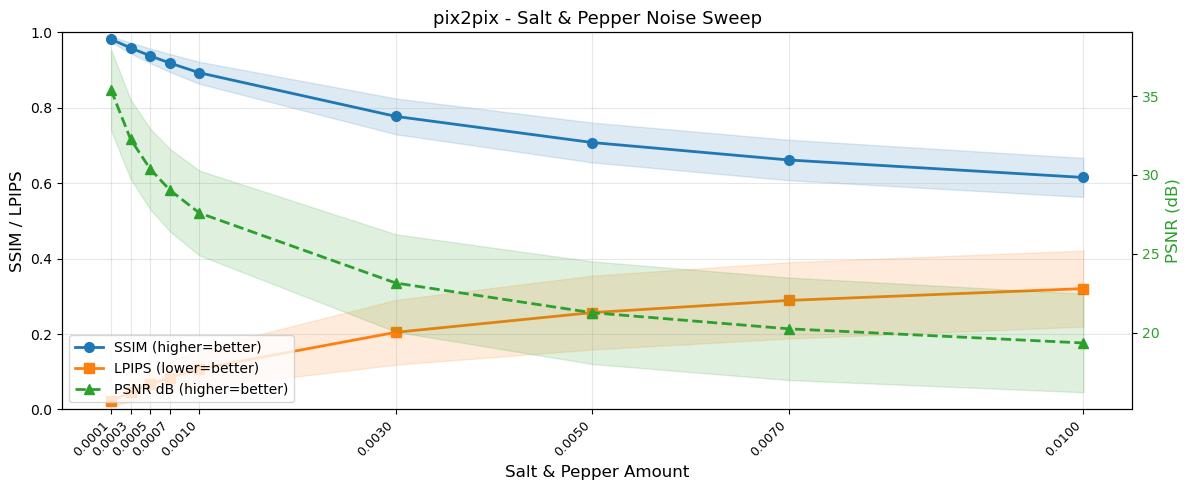

 amount  ssim_mean  ssim_std  psnr_mean  psnr_std  lpips_mean  lpips_std  n_images
 0.0001    0.98159   0.00734    35.3967    2.5626     0.02194    0.01273      7373
 0.0003    0.95862   0.01412    32.2557    2.5160     0.04614    0.02560      7373
 0.0005    0.93751   0.01935    30.3677    2.5550     0.06681    0.03435      7373
 0.0007    0.91849   0.02369    29.0365    2.6112     0.08447    0.04174      7373
 0.0010    0.89272   0.02915    27.5861    2.6898     0.10768    0.05078      7373
 0.0030    0.77709   0.04739    23.1437    3.0913     0.20450    0.08588      7373
 0.0050    0.70778   0.05275    21.2620    3.2538     0.25676    0.09788      7373
 0.0070    0.66149   0.05356    20.2414    3.2503     0.28910    0.10115      7373
 0.0100    0.61518   0.05170    19.3417    3.1270     0.32039    0.10071      7373


In [97]:
# Plot: salt & pepper sweep metrics (SSIM / PSNR / LPIPS vs clean prediction)
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./salt_pepper_sweep_output/summary.csv')
amt = df['amount'].values

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(amt, df['ssim_mean'], marker='o', color='tab:blue', linewidth=2, markersize=7, label='SSIM (higher=better)')
ax1.fill_between(amt, df['ssim_mean'] - df['ssim_std'], df['ssim_mean'] + df['ssim_std'], alpha=0.15, color='tab:blue')

ax1.plot(amt, df['lpips_mean'], marker='s', color='tab:orange', linewidth=2, markersize=7, label='LPIPS (lower=better)')
ax1.fill_between(amt, df['lpips_mean'] - df['lpips_std'], df['lpips_mean'] + df['lpips_std'], alpha=0.15, color='tab:orange')

ax2.plot(amt, df['psnr_mean'], marker='^', color='tab:green', linewidth=2, markersize=7, label='PSNR dB (higher=better)', linestyle='--')
ax2.fill_between(amt, df['psnr_mean'] - df['psnr_std'], df['psnr_mean'] + df['psnr_std'], alpha=0.15, color='tab:green')

ax1.set_xlabel('Salt & Pepper Amount', fontsize=12)
ax1.set_ylabel('SSIM / LPIPS', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12, color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.set_xticks(amt)
ax1.set_xticklabels([f'{v:.4f}' for v in amt], rotation=45, ha='right', fontsize=9)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title('pix2pix - Salt & Pepper Noise Sweep', fontsize=13)
plt.tight_layout()
plt.savefig('./salt_pepper_sweep_output/salt_pepper_sweep_metrics_1.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.to_string(index=False))


e:\Dissertation\pix2pix_minimal\.pixi\envs\default\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded cached features from uncertainty\umap_valset_features.npz: 7373 images, 1105950 points total, feature dim 30
subsampled to 400000 points for UMAP fit
UMAP(n_neighbors=30, random_state=42, verbose=True)


e:\Dissertation\pix2pix_minimal\.pixi\envs\default\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Wed Aug 19 19:39:00 2026 Construct fuzzy simplicial set
Wed Aug 19 19:39:00 2026 Finding Nearest Neighbors
Wed Aug 19 19:39:00 2026 Building RP forest with 37 trees
Wed Aug 19 19:39:32 2026 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	Stopping threshold met -- exiting after 2 iterations
Wed Aug 19 19:41:42 2026 Finished Nearest Neighbor Search
Wed Aug 19 19:42:14 2026 Construct embedding


Epochs completed:   0%|            1/200 [00:04]

...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [22:57]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [23:46]


Wed Aug 19 20:10:22 2026 Finished embedding
cached embedding -> uncertainty\umap_valset_embedding.npz


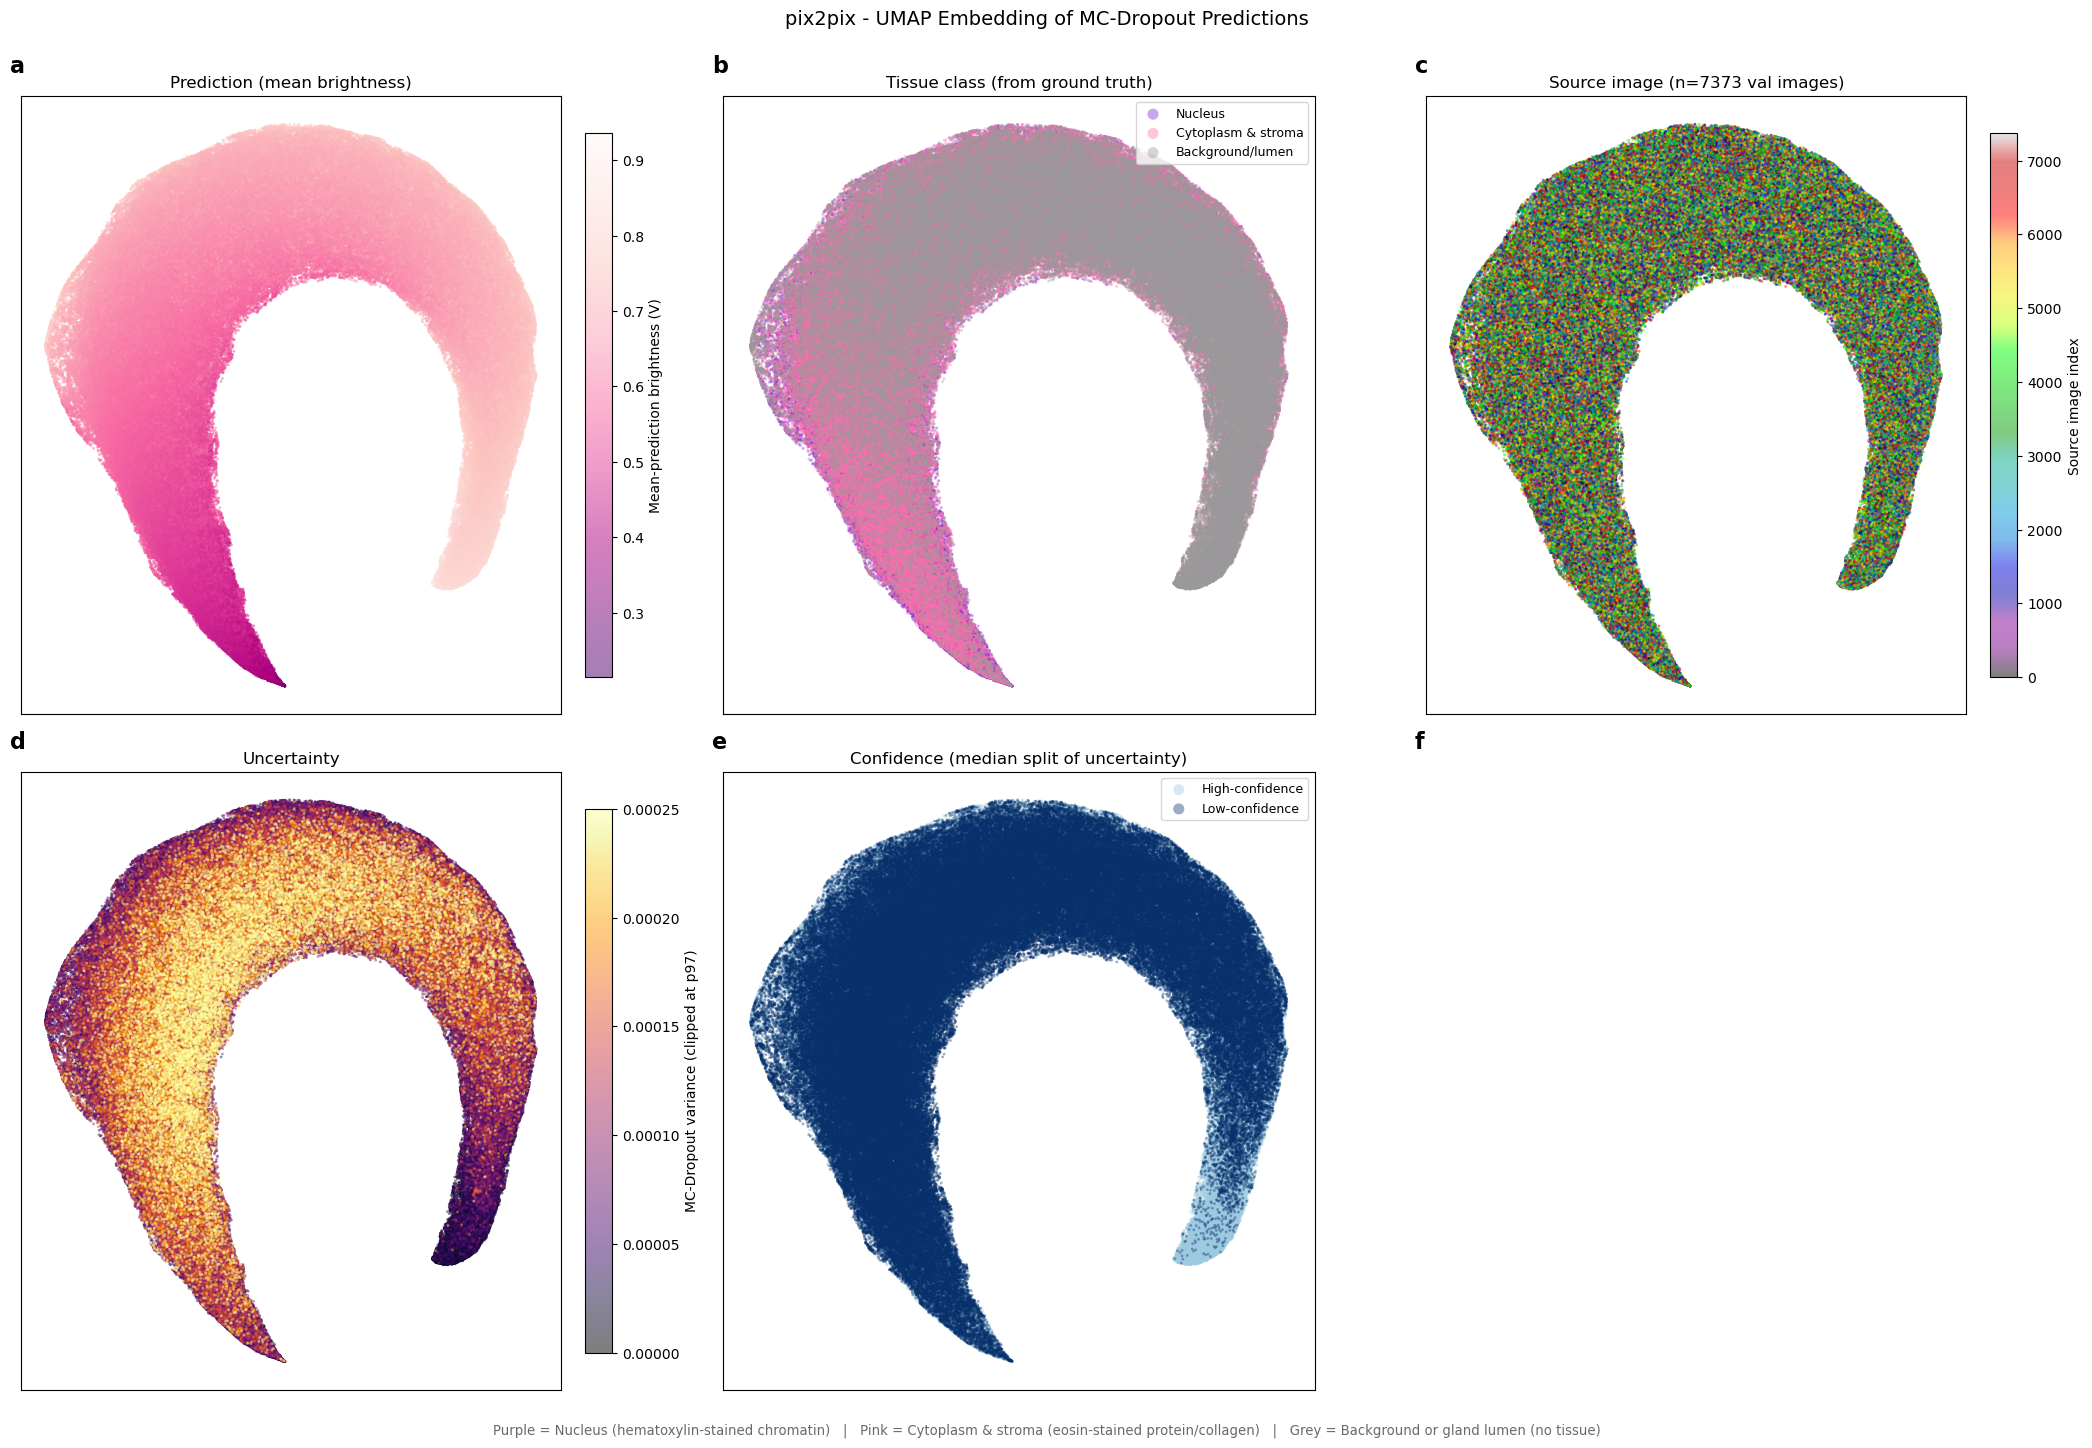

In [98]:
# Redraw the whole-val-set UMAP figure with an updated title. Self-contained:
# reloads the cached per-pixel features (extracted once by the whole-val-set
# UMAP cell above) instead of depending on that cell's live kernel variables,
# so this cell works even after a kernel restart. Only refits UMAP itself
# (a few minutes); does not repeat the slow pass over all 7373 val images.
import pathlib
import numpy as np
import umap
import matplotlib.pyplot as plt

cache_path = pathlib.Path('./uncertainty/umap_valset_features.npz')
assert cache_path.exists(), 'run the whole-val-set UMAP feature-extraction cell above at least once first (it caches features here)'

cached = np.load(cache_path)
X         = cached['X']
y_tissue  = cached['y_tissue']
y_uncert  = cached['y_uncert']
y_meanv   = cached['y_meanv']
sample_id = cached['sample_id']
n_images  = int(cached['n_images'])
print(f'loaded cached features from {cache_path}: {n_images} images, {X.shape[0]} points total, feature dim {X.shape[1]}')

TISSUE_NAMES  = ['Nucleus', 'Cytoplasm & stroma', 'Background/lumen']
TISSUE_COLORS = ['#7c1fd6', '#ff6fae', '#9a9a9a']
COLOUR_NOTE = ('Purple = Nucleus (hematoxylin-stained chromatin)   |   '
               'Pink = Cytoplasm & stroma (eosin-stained protein/collagen)   |   '
               'Grey = Background or gland lumen (no tissue)')

MAX_UMAP_POINTS = 400_000
if X.shape[0] > MAX_UMAP_POINTS:
    sub_idx   = np.random.default_rng(43).choice(X.shape[0], size=MAX_UMAP_POINTS, replace=False)
    X         = X[sub_idx]
    y_tissue  = y_tissue[sub_idx]
    y_uncert  = y_uncert[sub_idx]
    y_meanv   = y_meanv[sub_idx]
    sample_id = sample_id[sub_idx]
    print(f'subsampled to {X.shape[0]} points for UMAP fit')

embedding_cache_path = pathlib.Path('./uncertainty/umap_valset_embedding.npz')
if embedding_cache_path.exists():
    embedding = np.load(embedding_cache_path)['embedding']
    print(f'loaded cached embedding from {embedding_cache_path} -> skip refit')
else:
    reducer   = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42, verbose=True)
    embedding = reducer.fit_transform(X)
    np.savez(embedding_cache_path, embedding=embedding)
    print(f'cached embedding -> {embedding_cache_path}')
uncert_median = np.median(y_uncert)
y_confidence  = (y_uncert >= uncert_median).astype(int)   # 0 = high-confidence, 1 = low-confidence
CONF_NAMES  = ['High-confidence', 'Low-confidence']
CONF_COLORS = ['#9ecae1', '#08306b']

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
for ax, lbl in zip(axes.flat, ['a', 'b', 'c', 'd', 'e', 'f']):
    ax.text(-0.02, 1.03, lbl, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom')
    ax.set_xticks([]); ax.set_yticks([])

sc_a = axes[0, 0].scatter(embedding[:, 0], embedding[:, 1], s=4, c=y_meanv,
                           cmap='RdPu_r', alpha=0.5, edgecolors='none')
plt.colorbar(sc_a, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Mean-prediction brightness (V)')
axes[0, 0].set_title('Prediction (mean brightness)', fontsize=12)

for cls in range(3):
    m = y_tissue == cls
    axes[0, 1].scatter(embedding[m, 0], embedding[m, 1], s=4, alpha=0.4,
                        c=TISSUE_COLORS[cls], label=TISSUE_NAMES[cls], edgecolors='none')
axes[0, 1].legend(markerscale=4, fontsize=9, loc='upper right')
axes[0, 1].set_title('Tissue class (from ground truth)', fontsize=12)

sc_id = axes[0, 2].scatter(embedding[:, 0], embedding[:, 1], s=4, c=sample_id,
                            cmap='nipy_spectral', alpha=0.5, edgecolors='none')
plt.colorbar(sc_id, ax=axes[0, 2], fraction=0.046, pad=0.04, label='Source image index')
axes[0, 2].set_title(f'Source image (n={n_images} val images)', fontsize=12)

vmax  = np.percentile(y_uncert, 97)
order = np.argsort(y_uncert)
sc_c = axes[1, 0].scatter(embedding[order, 0], embedding[order, 1], s=4, alpha=0.5,
                           c=y_uncert[order], cmap='inferno', vmin=0, vmax=vmax, edgecolors='none')
plt.colorbar(sc_c, ax=axes[1, 0], fraction=0.046, pad=0.04, label='MC-Dropout variance (clipped at p97)')
axes[1, 0].set_title('Uncertainty', fontsize=12)

for cls in range(2):
    m = y_confidence == cls
    axes[1, 1].scatter(embedding[m, 0], embedding[m, 1], s=4, alpha=0.4,
                        c=CONF_COLORS[cls], label=CONF_NAMES[cls], edgecolors='none')
axes[1, 1].legend(markerscale=4, fontsize=9, loc='upper right')
axes[1, 1].set_title('Confidence (median split of uncertainty)', fontsize=12)

axes[1, 2].axis('off')

plt.suptitle('pix2pix - UMAP Embedding of MC-Dropout Predictions', fontsize=14, y=1.0)
fig.text(0.5, -0.01, COLOUR_NOTE, ha='center', va='top', fontsize=9.5, color='dimgray', wrap=True)
plt.tight_layout()
plt.savefig('./uncertainty/umap_uncertainty_valset_all_1.png', dpi=150, bbox_inches='tight')
plt.show()
